# **Tối ưu hóa Chiến lược Tiếp thị Thẻ tín dụng thông qua Phân khúc Khách hàng Dựa trên Hành vi**

Phân cụm (clustering) là việc nhóm một tập các đối tượng sao cho những đối tượng trong cùng một nhóm (gọi là một cụm) giống nhau nhiều hơn so với các đối tượng thuộc các nhóm khác.

<img src="https://i.postimg.cc/L6myWzkv/image.gif" width="800" height="450">

## **Thông tin về bộ dữ liệu**

Bộ dữ liệu mẫu này tóm tắt hành vi sử dụng của 8.950 chủ thẻ tín dụng đang hoạt động trong 6 tháng gần đây. Tệp dữ liệu ở cấp độ khách hàng với 18 biến hành vi. Nỗ lực của tôi sẽ là phân loại (phân nhóm) lượng dữ liệu này.

Phân khúc thị trường cho phép bạn nhắm mục tiêu nội dung đến đúng người theo đúng cách, thay vì nhắm đến toàn bộ tập khách hàng bằng một thông điệp chung chung. Điều này giúp bạn tăng khả năng mọi người tương tác với quảng cáo hoặc nội dung của bạn, từ đó tạo ra các chiến dịch hiệu quả hơn và cải thiện lợi tức đầu tư (ROI).

## **Câu hỏi đặt ra?**

+ Làm thế nào để phân loại khách hàng dựa trên thói quen sử dụng thẻ (Credit usage) và hành vi thanh toán (Payment behavior) nhằm tối ưu hóa các chiến dịch Marketing?

+ Đặc trưng hành vi nổi bật của từng cụm là gì, và chiến lược hành động tương ứng là gì?

+ Làm thế nào để chuyển dịch khách hàng từ nhóm có giá trị thấp sang nhóm có giá trị cao hơn?

## **Các trường dữ liệu**

**1. Định danh & Tài khoản**
* **`CUST_ID`**: Mã khách hàng.
* **`BALANCE`**: Số dư nợ hiện tại trong thẻ.
* **`CREDIT_LIMIT`**: Hạn mức tín dụng tối đa được cấp.
* **`BALANCE_FREQUENCY`**: Tần suất thay đổi số dư (Dao động từ 0 đến 1; 1 = thay đổi thường xuyên).

**2**. **Hành vi Mua sắm (Spending Behavior)**
* **`PURCHASES`**: Tổng tiền đã chi tiêu qua thẻ.
* **`ONEOFF_PURCHASES`**: Tổng tiền chi tiêu cho các khoản mua đứt (trả thẳng 1 lần).
* **`INSTALLMENTS_PURCHASES`**: Tổng tiền chi tiêu cho các khoản trả góp.
* **`PURCHASES_TRX`**: Số lượng giao dịch mua sắm đã thực hiện.

**3. Hành vi Rút tiền mặt (Cash Advance)**
* **`CASH_ADVANCE`**: Tổng tiền mặt đã ứng/rút từ thẻ.
* **`CASH_ADVANCE_FREQUENCY`**: Tần suất thực hiện việc rút tiền mặt.
* **`CASH_ADVANCE_TRX`**: Số lần rút tiền mặt.

**4. Hành vi Thanh toán (Repayment Behavior)**
* **`PAYMENTS`**: Tổng số tiền khách hàng đã thanh toán vào thẻ.
* **`MINIMUM_PAYMENTS`**: Số tiền thanh toán tối thiểu mà khách hàng đã trả.
* **`PRC_FULL_PAYMENT`**: Tỷ lệ phần trăm các tháng khách hàng trả hết toàn bộ dư nợ (Full pay).

**5. Khác**
* **`TENURE`**: Thời hạn sử dụng thẻ của khách hàng (đơn vị: tháng).

## Thêm các thư viện cần thiết

In [1]:
import numpy as np 
import pandas as pd 

import seaborn as sns
import matplotlib.pyplot as plt
from matplotlib import colors
from matplotlib.colors import ListedColormap
from sklearn.preprocessing import StandardScaler, normalize
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA 

import warnings
warnings.filterwarnings("ignore")

## **Tải dữ liệu**

Link Dataset: https://www.kaggle.com/datasets/arjunbhasin2013/ccdata

In [2]:
# Tải dữ liệu Online Retail
df = pd.read_csv("Dataset/CC GENERAL.csv")

# Hiển thị các dòng đầu tiên
df.head()

,CUST_ID,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
0,C10001,40.900749,0.818182,95.40,0.00,95.4,0.000000,0.166667,0.000000,0.083333,0.000000,0,2,1000.0,201.802084,139.509787,0.000000,12
1,C10002,3202.467416,0.909091,0.00,0.00,0.0,6442.945483,0.000000,0.000000,0.000000,0.250000,4,0,7000.0,4103.032597,1072.340217,0.222222,12
2,C10003,2495.148862,1.000000,773.17,773.17,0.0,0.000000,1.000000,1.000000,0.000000,0.000000,0,12,7500.0,622.066742,627.284787,0.000000,12
3,C10004,1666.670542,0.636364,1499.00,1499.00,0.0,205.788017,0.083333,0.083333,0.000000,0.083333,1,1,7500.0,0.000000,NaN,0.000000,12
4,C10005,817.714335,1.000000,16.00,16.00,0.0,0.000000,0.083333,0.083333,0.000000,0.000000,0,1,1200.0,678.334763,244.791237,0.000000,12


In [3]:
# Kiểm tra thông tin cơ bản về dữ liệu
print("Thông tin tổng quan:")
print(f"- Kích thước: {df.shape[0]:,} dòng x {df.shape[1]} cột")
print(f"- Giá trị thiếu: {df.isnull().sum().sum():,} giá trị")

df.info()

Thông tin tổng quan:
- Kích thước: 8,950 dòng x 18 cột
- Giá trị thiếu: 314 giá trị
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8950 entries, 0 to 8949
Data columns (total 18 columns):
 #   Column                            Non-Null Count  Dtype  
---  ------                            --------------  -----  
 0   CUST_ID                           8950 non-null   object 
 1   BALANCE                           8950 non-null   float64
 2   BALANCE_FREQUENCY                 8950 non-null   float64
 3   PURCHASES                         8950 non-null   float64
 4   ONEOFF_PURCHASES                  8950 non-null   float64
 5   INSTALLMENTS_PURCHASES            8950 non-null   float64
 6   CASH_ADVANCE                      8950 non-null   float64
 7   PURCHASES_FREQUENCY               8950 non-null   float64
 8   ONEOFF_PURCHASES_FREQUENCY        8950 non-null   float64
 9   PURCHASES_INSTALLMENTS_FREQUENCY  8950 non-null   float64
 10  CASH_ADVANCE_FREQUENCY            8950 non-null 

## **Chuẩn bị dữ liệu**

## **1. KHÁM PHÁ DỮ LIỆU (EDA)**

### **1.1 Thống kê mô tả**

In [4]:
df.describe()

,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,PURCHASES_TRX,CREDIT_LIMIT,PAYMENTS,MINIMUM_PAYMENTS,PRC_FULL_PAYMENT,TENURE
count,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8950.000000,8949.000000,8950.000000,8637.000000,8950.000000,8950.000000
mean,1564.474828,0.877271,1003.204834,592.437371,411.067645,978.871112,0.490351,0.202458,0.364437,0.135144,3.248827,14.709832,4494.449450,1733.143852,864.206542,0.153715,11.517318
std,2081.531879,0.236904,2136.634782,1659.887917,904.338115,2097.163877,0.401371,0.298336,0.397448,0.200121,6.824647,24.857649,3638.815725,2895.063757,2372.446607,0.292499,1.338331
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,50.000000,0.000000,0.019163,0.000000,6.000000
25%,128.281915,0.888889,39.635000,0.000000,0.000000,0.000000,0.083333,0.000000,0.000000,0.000000,0.000000,1.000000,1600.000000,383.276166,169.123707,0.000000,12.000000
50%,873.385231,1.000000,361.280000,38.000000,89.000000,0.000000,0.500000,0.083333,0.166667,0.000000,0.000000,7.000000,3000.000000,856.901546,312.343947,0.000000,12.000000
75%,2054.140036,1.000000,1110.130000,577.405000,468.637500,1113.821139,0.916667,0.300000,0.750000,0.222222,4.000000,17.000000,6500.000000,1901.134317,825.485459,0.142857,12.000000
max,19043.138560,1.000000,49039.570000,40761.250000,22500.000000,47137.211760,1.000000,1.000000,1.000000,1.500000,123.000000,358.000000,30000.000000,50721.483360,76406.207520,1.000000,12.000000


### **1.2 Phân tích phân phối từng biến**

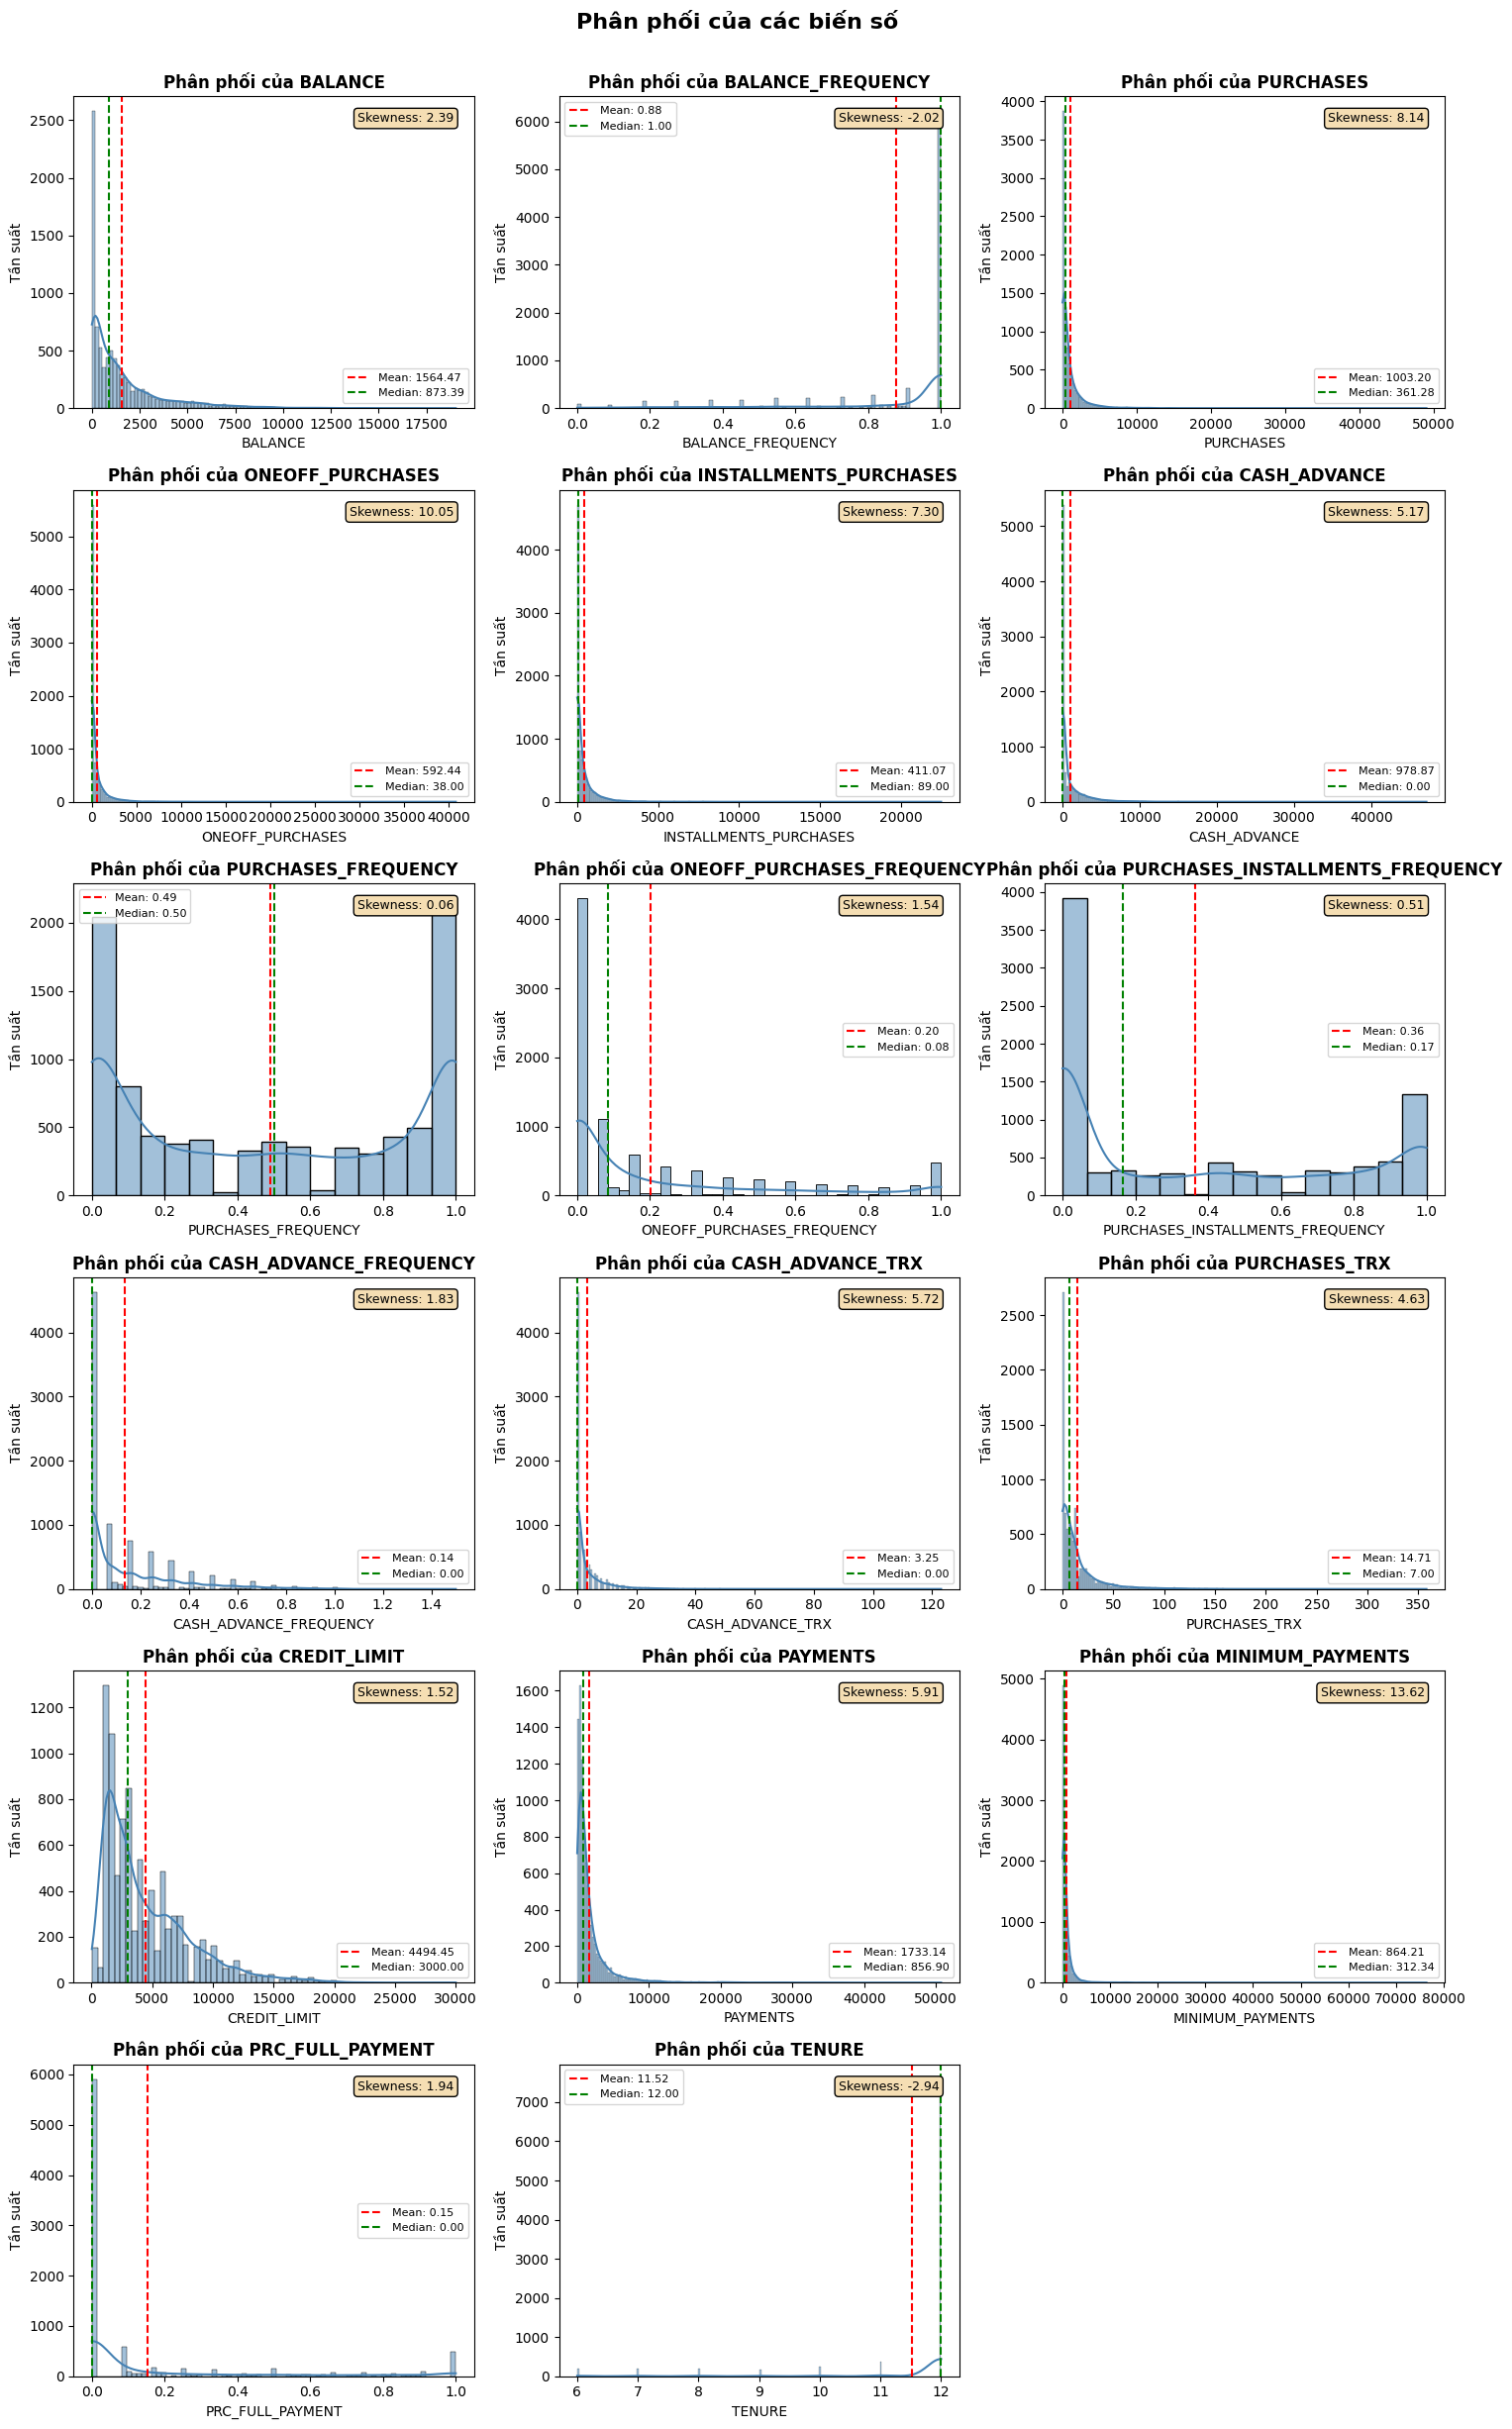


Độ lệch (Skewness) của các biến:
--------------------------------------------------
BALANCE                            :    2.393 - Lệch phải
BALANCE_FREQUENCY                  :   -2.023 - Lệch trái
PURCHASES                          :    8.144 - Lệch phải
ONEOFF_PURCHASES                   :   10.045 - Lệch phải
INSTALLMENTS_PURCHASES             :    7.299 - Lệch phải
CASH_ADVANCE                       :    5.167 - Lệch phải
PURCHASES_FREQUENCY                :    0.060 - Phân phối gần đối xứng
ONEOFF_PURCHASES_FREQUENCY         :    1.536 - Lệch phải
PURCHASES_INSTALLMENTS_FREQUENCY   :    0.509 - Lệch phải
CASH_ADVANCE_FREQUENCY             :    1.829 - Lệch phải
CASH_ADVANCE_TRX                   :    5.721 - Lệch phải
PURCHASES_TRX                      :    4.631 - Lệch phải
CREDIT_LIMIT                       :    1.522 - Lệch phải
PAYMENTS                           :    5.908 - Lệch phải
MINIMUM_PAYMENTS                   :   13.623 - Lệch phải
PRC_FULL_PAYMENT                

In [5]:
# Lấy các cột số (loại bỏ CUST_ID)
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

# Tạo figure với nhiều subplot
n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 4))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    
    # Vẽ histogram với KDE
    sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='black')
    ax.set_title(f'Phân phối của {col}', fontsize=12, fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Tần suất')
    
    # Thêm thông tin skewness
    skew_val = df[col].skew()
    ax.axvline(df[col].mean(), color='red', linestyle='--', label=f'Mean: {df[col].mean():.2f}')
    ax.axvline(df[col].median(), color='green', linestyle='--', label=f'Median: {df[col].median():.2f}')
    ax.legend(fontsize=8)
    ax.text(0.95, 0.95, f'Skewness: {skew_val:.2f}', transform=ax.transAxes, 
            ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat'))

# Ẩn các subplot thừa
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.tight_layout()
plt.suptitle('Phân phối của các biến số', fontsize=16, fontweight='bold', y=1.02)
plt.show()

# Hiển thị thông tin skewness
print("\nĐộ lệch (Skewness) của các biến:")
print("-" * 50)
for col in numeric_cols:
    skew = df[col].skew()
    if abs(skew) < 0.5:
        skew_type = "Phân phối gần đối xứng"
    elif skew > 0:
        skew_type = "Lệch phải"
    else:
        skew_type = "Lệch trái"
    print(f"{col:35s}: {skew:8.3f} - {skew_type}")

### **1.2.1 Phan tich theo nhom bien (Amount vs Frequency)**

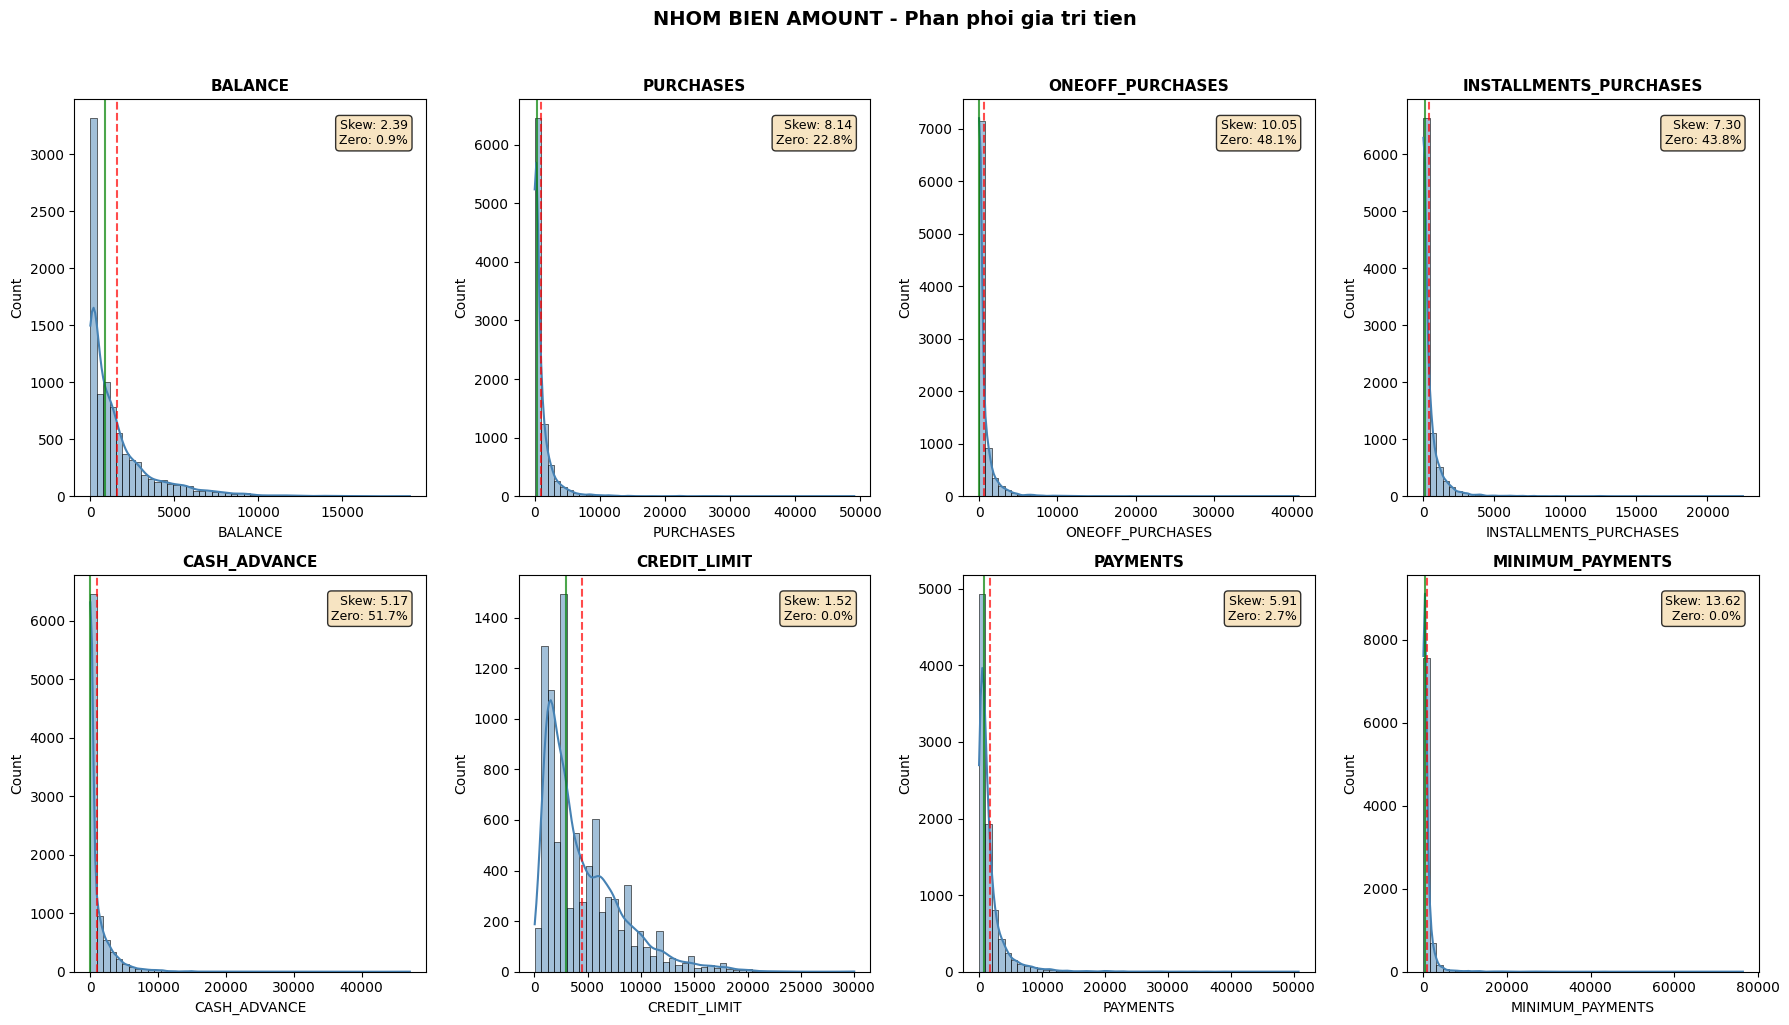

NHAN XET NHOM AMOUNT:
  - BALANCE: Lech phai MANH (skew=2.39) --> Can log transform
  - PURCHASES: Lech phai MANH (skew=8.14) --> Can log transform
    [!] Co 22.8% gia tri = 0 --> Nhom khach hang khong su dung
  - ONEOFF_PURCHASES: Lech phai MANH (skew=10.05) --> Can log transform
    [!] Co 48.1% gia tri = 0 --> Nhom khach hang khong su dung
  - INSTALLMENTS_PURCHASES: Lech phai MANH (skew=7.30) --> Can log transform
    [!] Co 43.8% gia tri = 0 --> Nhom khach hang khong su dung
  - CASH_ADVANCE: Lech phai MANH (skew=5.17) --> Can log transform
    [!] Co 51.7% gia tri = 0 --> Nhom khach hang khong su dung
  - CREDIT_LIMIT: Lech phai (skew=1.52) --> Nen log transform
  - PAYMENTS: Lech phai MANH (skew=5.91) --> Can log transform
  - MINIMUM_PAYMENTS: Lech phai MANH (skew=13.62) --> Can log transform


In [6]:
amount_cols = ['BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
               'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS']

frequency_cols = ['BALANCE_FREQUENCY', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY',
                  'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'PRC_FULL_PAYMENT']

fig, axes = plt.subplots(2, 4, figsize=(18, 10))
axes = axes.flatten()

for idx, col in enumerate(amount_cols):
    if col in df.columns:
        ax = axes[idx]
        sns.histplot(df[col], kde=True, ax=ax, color='steelblue', edgecolor='black', bins=50)
        ax.set_title(f'{col}', fontsize=11, fontweight='bold')
        
        skew_val = df[col].skew()
        zero_pct = (df[col] == 0).sum() / len(df) * 100
        
        info_text = f'Skew: {skew_val:.2f}\nZero: {zero_pct:.1f}%'
        ax.text(0.95, 0.95, info_text, transform=ax.transAxes, ha='right', va='top', fontsize=9,
                bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.8))
        
        ax.axvline(df[col].mean(), color='red', linestyle='--', linewidth=1.5, alpha=0.7)
        ax.axvline(df[col].median(), color='green', linestyle='-', linewidth=1.5, alpha=0.7)

plt.suptitle('NHOM BIEN AMOUNT - Phan phoi gia tri tien', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 70)
print("NHAN XET NHOM AMOUNT:")
print("=" * 70)
for col in amount_cols:
    if col in df.columns:
        skew = df[col].skew()
        zero_pct = (df[col] == 0).sum() / len(df) * 100
        if skew > 2:
            print(f"  - {col}: Lech phai MANH (skew={skew:.2f}) --> Can log transform")
        elif skew > 1:
            print(f"  - {col}: Lech phai (skew={skew:.2f}) --> Nen log transform")
        if zero_pct > 20:
            print(f"    [!] Co {zero_pct:.1f}% gia tri = 0 --> Nhom khach hang khong su dung")

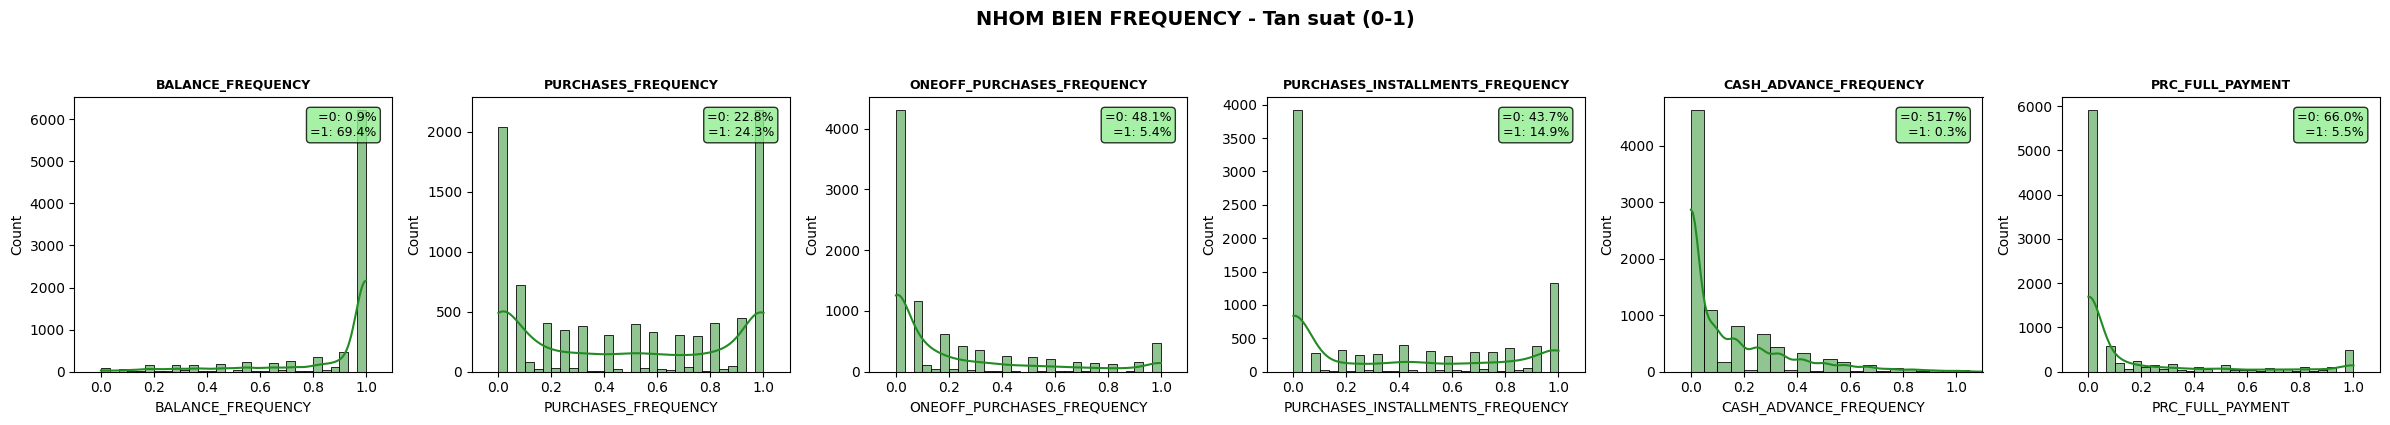


NHAN XET NHOM FREQUENCY:
  - Cac bien frequency co gia tri tu 0 den 1
  - Can scale CUNG voi nhom amount de dam bao cong bang trong clustering
  - Nhieu khach hang co frequency = 0 hoac = 1 (hanh vi cuc doan)


In [7]:
freq_cols_exist = [col for col in frequency_cols if col in df.columns]

n_freq = len(freq_cols_exist)
fig, axes = plt.subplots(1, min(n_freq, 6), figsize=(4*min(n_freq, 6), 4))
if n_freq == 1:
    axes = [axes]

for idx, col in enumerate(freq_cols_exist[:6]):
    ax = axes[idx]
    sns.histplot(df[col], kde=True, ax=ax, color='forestgreen', edgecolor='black', bins=30)
    ax.set_title(f'{col}', fontsize=9, fontweight='bold')
    ax.set_xlim(-0.1, 1.1)
    
    at_zero = (df[col] == 0).sum() / len(df) * 100
    at_one = (df[col] == 1).sum() / len(df) * 100
    ax.text(0.95, 0.95, f'=0: {at_zero:.1f}%\n=1: {at_one:.1f}%',
            transform=ax.transAxes, ha='right', va='top', fontsize=9,
            bbox=dict(boxstyle='round', facecolor='lightgreen', alpha=0.8))

plt.suptitle('NHOM BIEN FREQUENCY - Tan suat (0-1)', fontsize=14, fontweight='bold', y=1.05)
plt.tight_layout()
plt.show()

print("\n" + "=" * 70)
print("NHAN XET NHOM FREQUENCY:")
print("=" * 70)
print("  - Cac bien frequency co gia tri tu 0 den 1")
print("  - Can scale CUNG voi nhom amount de dam bao cong bang trong clustering")
print("  - Nhieu khach hang co frequency = 0 hoac = 1 (hanh vi cuc doan)")

### **1.3 Ma trận tương quan**

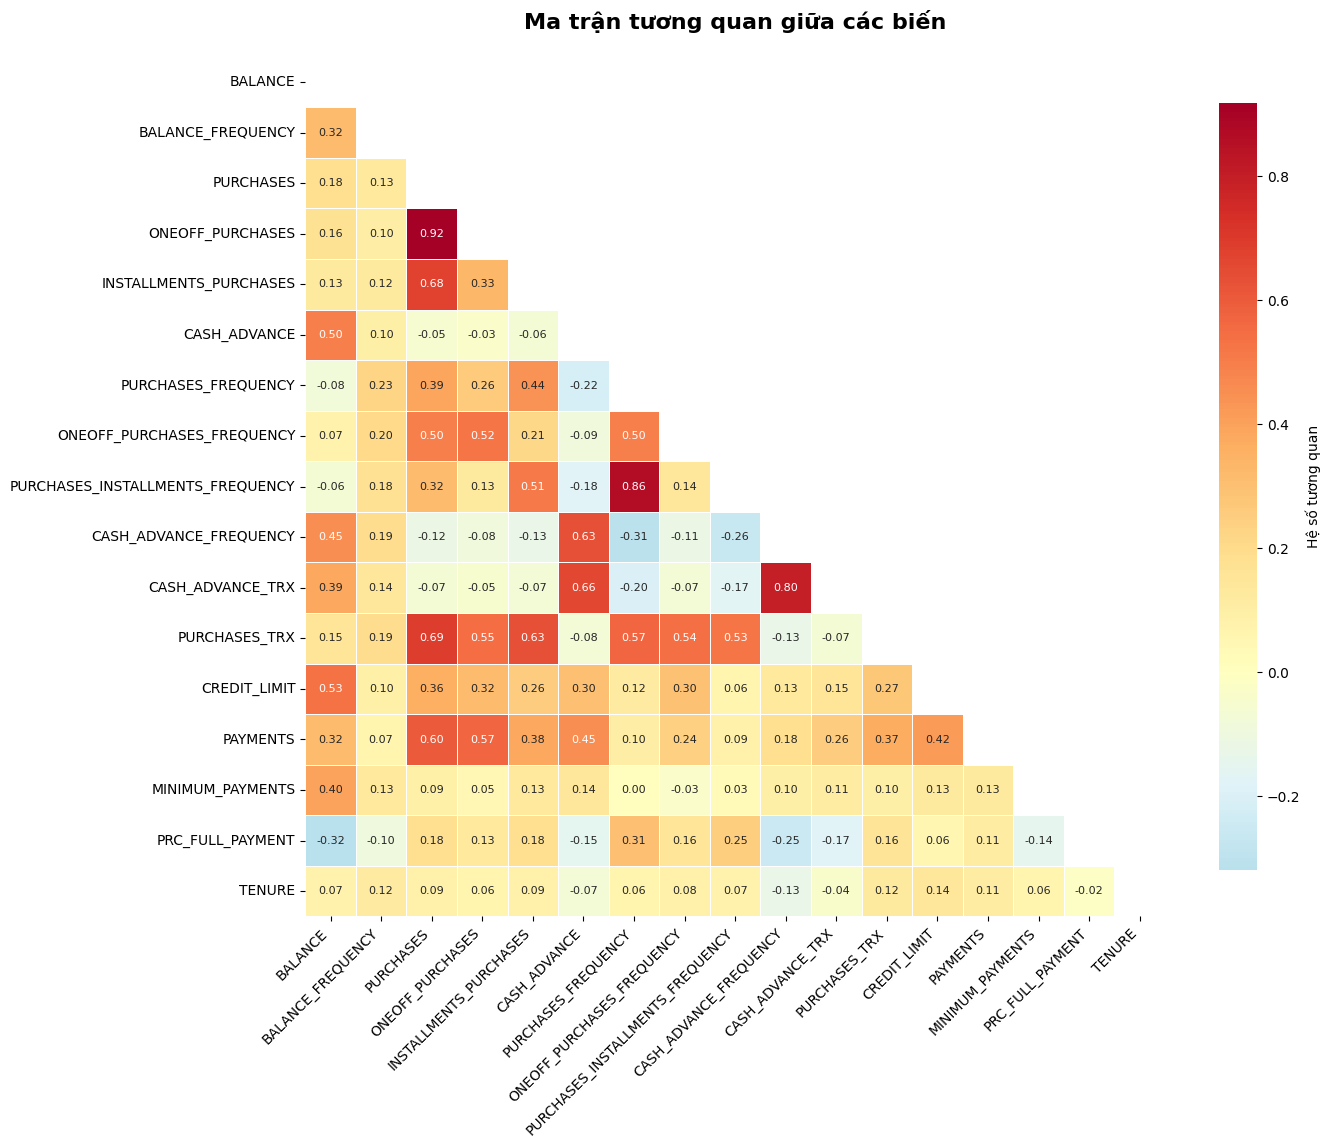


các cặp biến có tương quan CAO (|r| > 0.7):
------------------------------------------------------------


,Biến 1,Biến 2,Tương quan
0,PURCHASES,ONEOFF_PURCHASES,0.916845
1,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.862934
2,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.799561


In [8]:
# Tính ma trận tương quan (chỉ với các cột số)
df_numeric = df.select_dtypes(include=[np.number])
correlation_matrix = df_numeric.corr()

# Vẽ heatmap
plt.figure(figsize=(14, 12))
mask = np.triu(np.ones_like(correlation_matrix, dtype=bool))  # Mask nửa trên

sns.heatmap(correlation_matrix, 
            mask=mask,
            annot=True, 
            fmt='.2f', 
            cmap='RdYlBu_r',
            center=0,
            square=True,
            linewidths=0.5,
            cbar_kws={"shrink": 0.8, "label": "Hệ số tương quan"},
            annot_kws={"size": 8})

plt.title('Ma trận tương quan giữa các biến', fontsize=16, fontweight='bold', pad=20)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# Tìm các cặp biến có tương quan cao
print("\ncác cặp biến có tương quan CAO (|r| > 0.7):")
print("-" * 60)
high_corr_pairs = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        if abs(correlation_matrix.iloc[i, j]) > 0.7:
            high_corr_pairs.append({
                'Biến 1': correlation_matrix.columns[i],
                'Biến 2': correlation_matrix.columns[j],
                'Tương quan': correlation_matrix.iloc[i, j]
            })

if high_corr_pairs:
    high_corr_df = pd.DataFrame(high_corr_pairs).sort_values('Tương quan', ascending=False)
    display(high_corr_df)
else:
    print("Không có cặp biến nào có tương quan cao (|r| > 0.7)")

### **1.3.1 Scatter Plots - Phat hien Patterns**

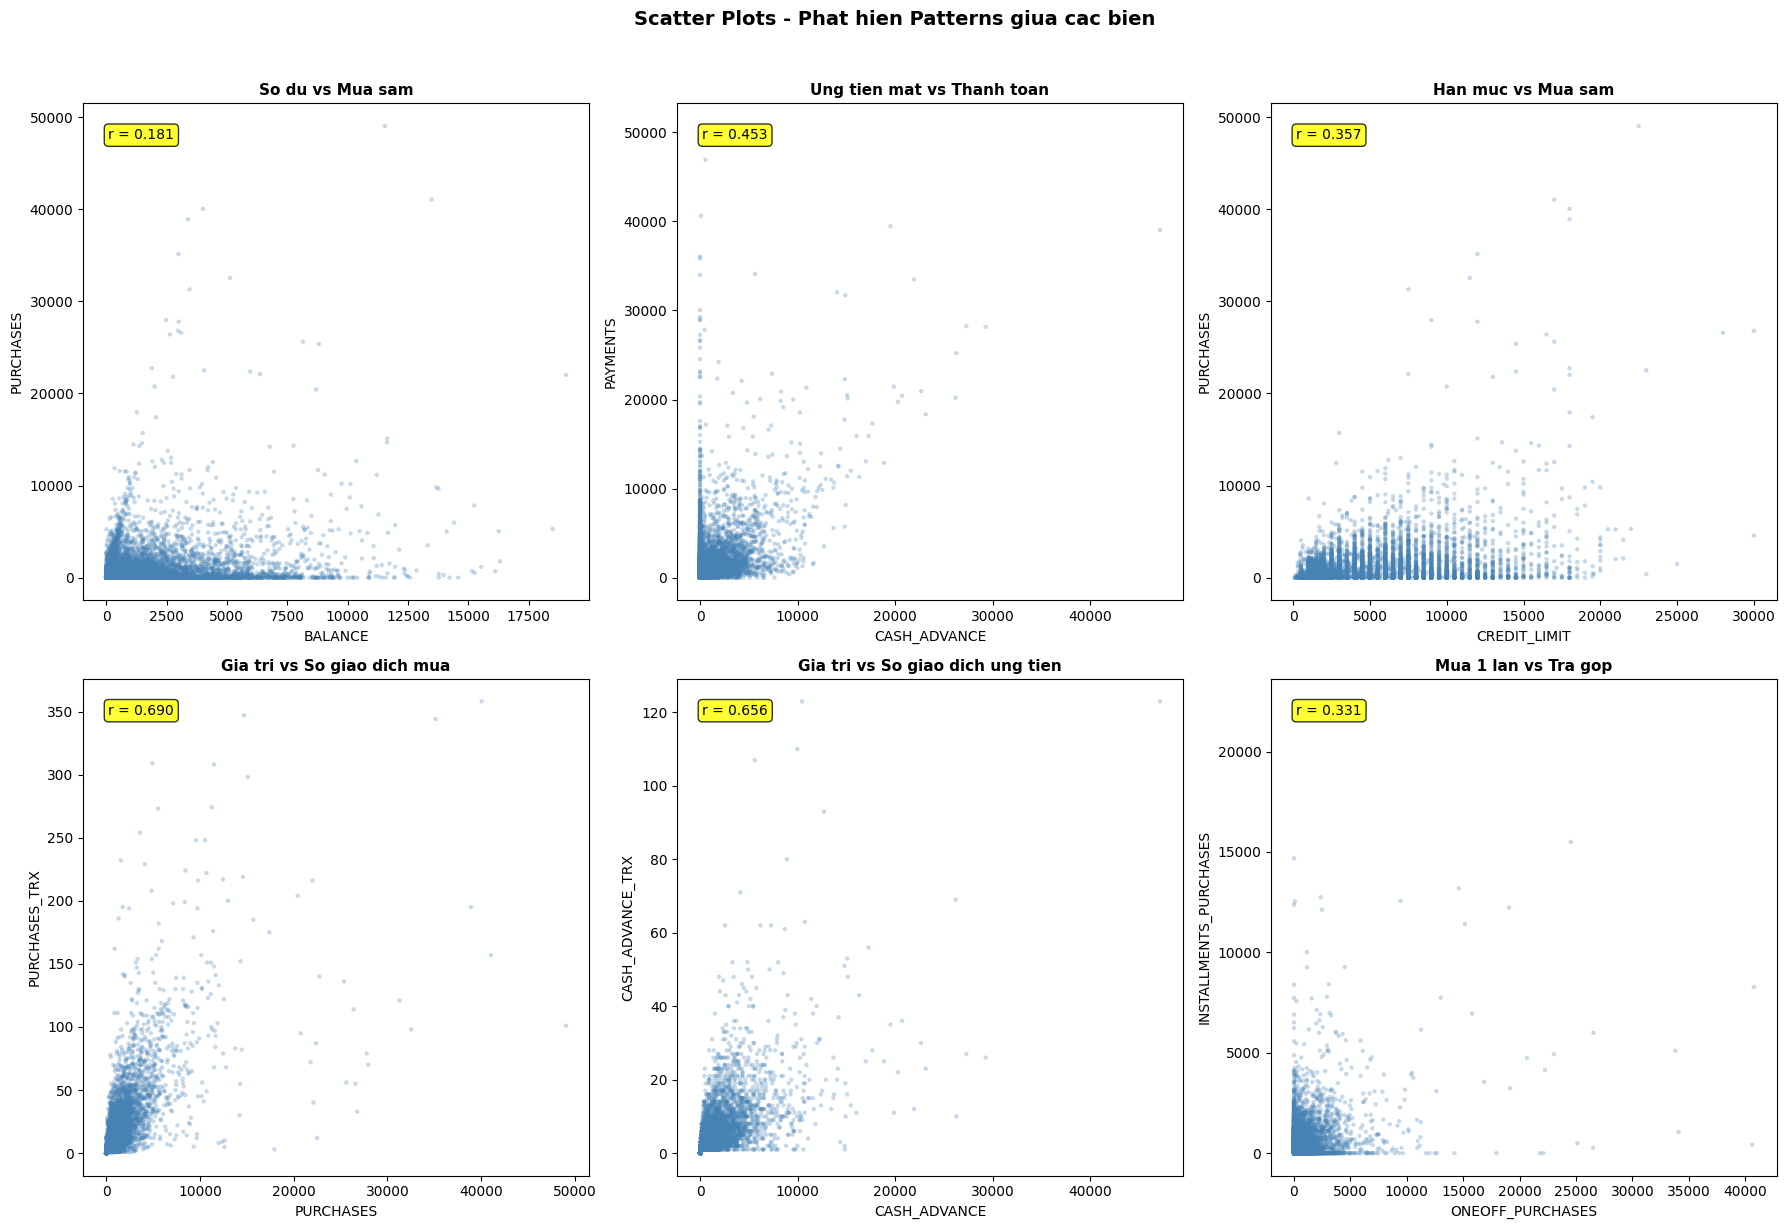

PHAT HIEN TU SCATTER PLOTS:
  - Co 2044 khach hang (22.8%) khong mua sam (PURCHASES=0)
  - Co 4322 khach hang (48.3%) su dung ung tien mat
  - [!] Co 2043 khach hang KHONG mua sam nhung CO ung tien mat
      --> Day la nhom hanh vi DAC BIET, co the la nhom rui ro cao

  - PURCHASES vs PURCHASES_TRX: r = 0.690
      --> Tuong quan CAO, co the loai 1 bien de giam redundancy


In [9]:
scatter_pairs = [
    ('BALANCE', 'PURCHASES', 'So du vs Mua sam'),
    ('CASH_ADVANCE', 'PAYMENTS', 'Ung tien mat vs Thanh toan'),
    ('CREDIT_LIMIT', 'PURCHASES', 'Han muc vs Mua sam'),
    ('PURCHASES', 'PURCHASES_TRX', 'Gia tri vs So giao dich mua'),
    ('CASH_ADVANCE', 'CASH_ADVANCE_TRX', 'Gia tri vs So giao dich ung tien'),
    ('ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'Mua 1 lan vs Tra gop')
]

fig, axes = plt.subplots(2, 3, figsize=(18, 12))
axes = axes.flatten()

for idx, (col1, col2, title) in enumerate(scatter_pairs):
    if col1 in df.columns and col2 in df.columns:
        ax = axes[idx]
        ax.scatter(df[col1], df[col2], alpha=0.3, s=10, c='steelblue', edgecolors='none')
        ax.set_xlabel(col1, fontsize=10)
        ax.set_ylabel(col2, fontsize=10)
        ax.set_title(title, fontsize=11, fontweight='bold')
        
        corr = df[col1].corr(df[col2])
        ax.text(0.05, 0.95, f'r = {corr:.3f}', transform=ax.transAxes, fontsize=10, va='top',
                bbox=dict(boxstyle='round', facecolor='yellow', alpha=0.8))

plt.suptitle('Scatter Plots - Phat hien Patterns giua cac bien', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("=" * 70)
print("PHAT HIEN TU SCATTER PLOTS:")
print("=" * 70)

no_purchase = (df['PURCHASES'] == 0).sum()
has_cash_advance = (df['CASH_ADVANCE'] > 0).sum()
no_purchase_has_cash = ((df['PURCHASES'] == 0) & (df['CASH_ADVANCE'] > 0)).sum()

print(f"  - Co {no_purchase} khach hang ({no_purchase/len(df)*100:.1f}%) khong mua sam (PURCHASES=0)")
print(f"  - Co {has_cash_advance} khach hang ({has_cash_advance/len(df)*100:.1f}%) su dung ung tien mat")
print(f"  - [!] Co {no_purchase_has_cash} khach hang KHONG mua sam nhung CO ung tien mat")
print(f"      --> Day la nhom hanh vi DAC BIET, co the la nhom rui ro cao")
print(f"\n  - PURCHASES vs PURCHASES_TRX: r = {df['PURCHASES'].corr(df['PURCHASES_TRX']):.3f}")
print(f"      --> Tuong quan CAO, co the loai 1 bien de giam redundancy")

In [10]:
print("=" * 70)
print("PHAN TICH NHOM BIEN TUONG QUAN MANH")
print("=" * 70)

corr_pairs_analysis = []
for i in range(len(correlation_matrix.columns)):
    for j in range(i+1, len(correlation_matrix.columns)):
        corr_val = correlation_matrix.iloc[i, j]
        if abs(corr_val) > 0.5:
            level = 'RAT CAO' if abs(corr_val) > 0.8 else ('CAO' if abs(corr_val) > 0.7 else 'TRUNG BINH')
            corr_pairs_analysis.append({
                'Bien 1': correlation_matrix.columns[i],
                'Bien 2': correlation_matrix.columns[j],
                'Correlation': round(corr_val, 3),
                'Muc do': level
            })

corr_analysis_df = pd.DataFrame(corr_pairs_analysis).sort_values('Correlation', ascending=False)
print("\nCac cap bien co tuong quan |r| > 0.5:")
display(corr_analysis_df)

print("\n" + "-" * 70)
print("NHOM TUONG QUAN:")
print("-" * 70)
print("""
  NHOM 1 - Hanh vi MUA SAM:
  - PURCHASES <-> PURCHASES_TRX <-> ONEOFF_PURCHASES <-> INSTALLMENTS_PURCHASES
  - PURCHASES_FREQUENCY <-> cac bien frequency khac
  --> Khach hang mua nhieu thi tan suat cao

  NHOM 2 - Hanh vi UNG TIEN MAT:
  - CASH_ADVANCE <-> CASH_ADVANCE_TRX <-> CASH_ADVANCE_FREQUENCY
  --> Khach hang ung tien thuong ung nhieu lan

  NHOM 3 - Kha nang THANH TOAN:
  - CREDIT_LIMIT <-> BALANCE <-> PAYMENTS
  --> Han muc cao thuong di kem so du va thanh toan cao

  [!] LUU Y: Nhieu bien trong cung nhom co the gay REDUNDANCY
      --> Can can nhac loai bot hoac dung PCA
""")

PHAN TICH NHOM BIEN TUONG QUAN MANH

Cac cap bien co tuong quan |r| > 0.5:


,Bien 1,Bien 2,Correlation,Muc do
1,PURCHASES,ONEOFF_PURCHASES,0.917,RAT CAO
13,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.863,RAT CAO
17,CASH_ADVANCE_FREQUENCY,CASH_ADVANCE_TRX,0.800,CAO
3,PURCHASES,PURCHASES_TRX,0.690,TRUNG BINH
2,PURCHASES,INSTALLMENTS_PURCHASES,0.680,TRUNG BINH
11,CASH_ADVANCE,CASH_ADVANCE_TRX,0.656,TRUNG BINH
10,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,0.629,TRUNG BINH
9,INSTALLMENTS_PURCHASES,PURCHASES_TRX,0.628,TRUNG BINH
4,PURCHASES,PAYMENTS,0.603,TRUNG BINH
14,PURCHASES_FREQUENCY,PURCHASES_TRX,0.568,TRUNG BINH



----------------------------------------------------------------------
NHOM TUONG QUAN:
----------------------------------------------------------------------

  NHOM 1 - Hanh vi MUA SAM:
  - PURCHASES <-> PURCHASES_TRX <-> ONEOFF_PURCHASES <-> INSTALLMENTS_PURCHASES
  - PURCHASES_FREQUENCY <-> cac bien frequency khac
  --> Khach hang mua nhieu thi tan suat cao

  NHOM 2 - Hanh vi UNG TIEN MAT:
  - CASH_ADVANCE <-> CASH_ADVANCE_TRX <-> CASH_ADVANCE_FREQUENCY
  --> Khach hang ung tien thuong ung nhieu lan

  NHOM 3 - Kha nang THANH TOAN:
  - CREDIT_LIMIT <-> BALANCE <-> PAYMENTS
  --> Han muc cao thuong di kem so du va thanh toan cao

  [!] LUU Y: Nhieu bien trong cung nhom co the gay REDUNDANCY
      --> Can can nhac loai bot hoac dung PCA



### **1.4 Phát hiện outliers**

Thống kê Outliers theo phương pháp IQR:
Biến                                 Số outliers    Tỷ lệ (%)   Giới hạn dưới   Giới hạn trên
--------------------------------------------------------------------------------
BALANCE                                      695        7.77%        -2760.51         4942.93
BALANCE_FREQUENCY                          1,493       16.68%            0.72            1.17
PURCHASES                                    808        9.03%        -1566.11         2715.87
ONEOFF_PURCHASES                           1,013       11.32%         -866.11         1443.51
INSTALLMENTS_PURCHASES                       867        9.69%         -702.96         1171.59
CASH_ADVANCE                               1,030       11.51%        -1670.73         2784.55
PURCHASES_FREQUENCY                            0        0.00%           -1.17            2.17
ONEOFF_PURCHASES_FREQUENCY                   782        8.74%           -0.45            0.75
PURCHASES_INSTALLMENTS_FREQUENCY 

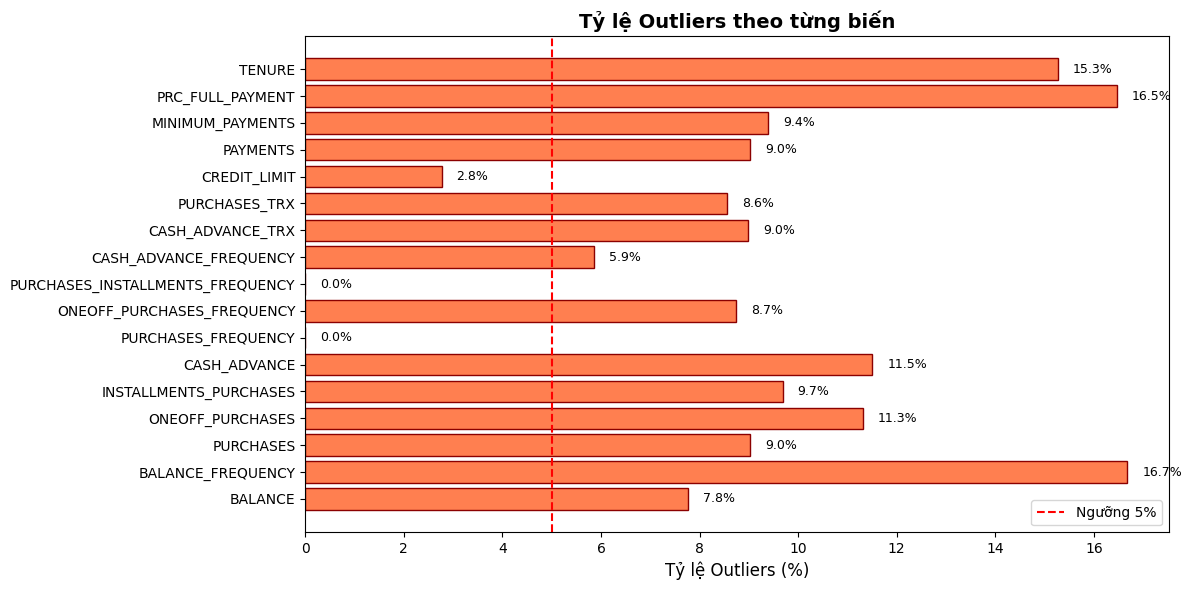

In [11]:
# Thống kê số lượng outliers theo phương pháp IQR
def count_outliers_iqr(df, column):
    """Đếm số outliers sử dụng phương pháp IQR"""
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    outliers = df[(df[column] < lower_bound) | (df[column] > upper_bound)]
    return len(outliers), lower_bound, upper_bound

print("Thống kê Outliers theo phương pháp IQR:")
print("=" * 80)
print(f"{'Biến':<35} {'Số outliers':>12} {'Tỷ lệ (%)':>12} {'Giới hạn dưới':>15} {'Giới hạn trên':>15}")
print("-" * 80)

outlier_summary = []
for col in numeric_cols:
    n_outliers, lower, upper = count_outliers_iqr(df, col)
    pct = (n_outliers / len(df)) * 100
    outlier_summary.append({
        'Biến': col,
        'Số outliers': n_outliers,
        'Tỷ lệ (%)': pct,
        'Giới hạn dưới': lower,
        'Giới hạn trên': upper
    })
    print(f"{col:<35} {n_outliers:>12,} {pct:>11.2f}% {lower:>15.2f} {upper:>15.2f}")

# Tạo biểu đồ tổng hợp outliers
outlier_df = pd.DataFrame(outlier_summary)
plt.figure(figsize=(12, 6))
bars = plt.barh(outlier_df['Biến'], outlier_df['Tỷ lệ (%)'], color='coral', edgecolor='darkred')
plt.xlabel('Tỷ lệ Outliers (%)', fontsize=12)
plt.title('Tỷ lệ Outliers theo từng biến', fontsize=14, fontweight='bold')
plt.axvline(x=5, color='red', linestyle='--', label='Ngưỡng 5%')
plt.legend()

# Thêm giá trị lên bars
for bar, val in zip(bars, outlier_df['Tỷ lệ (%)']):
    plt.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2, 
             f'{val:.1f}%', va='center', fontsize=9)

plt.tight_layout()
plt.show()

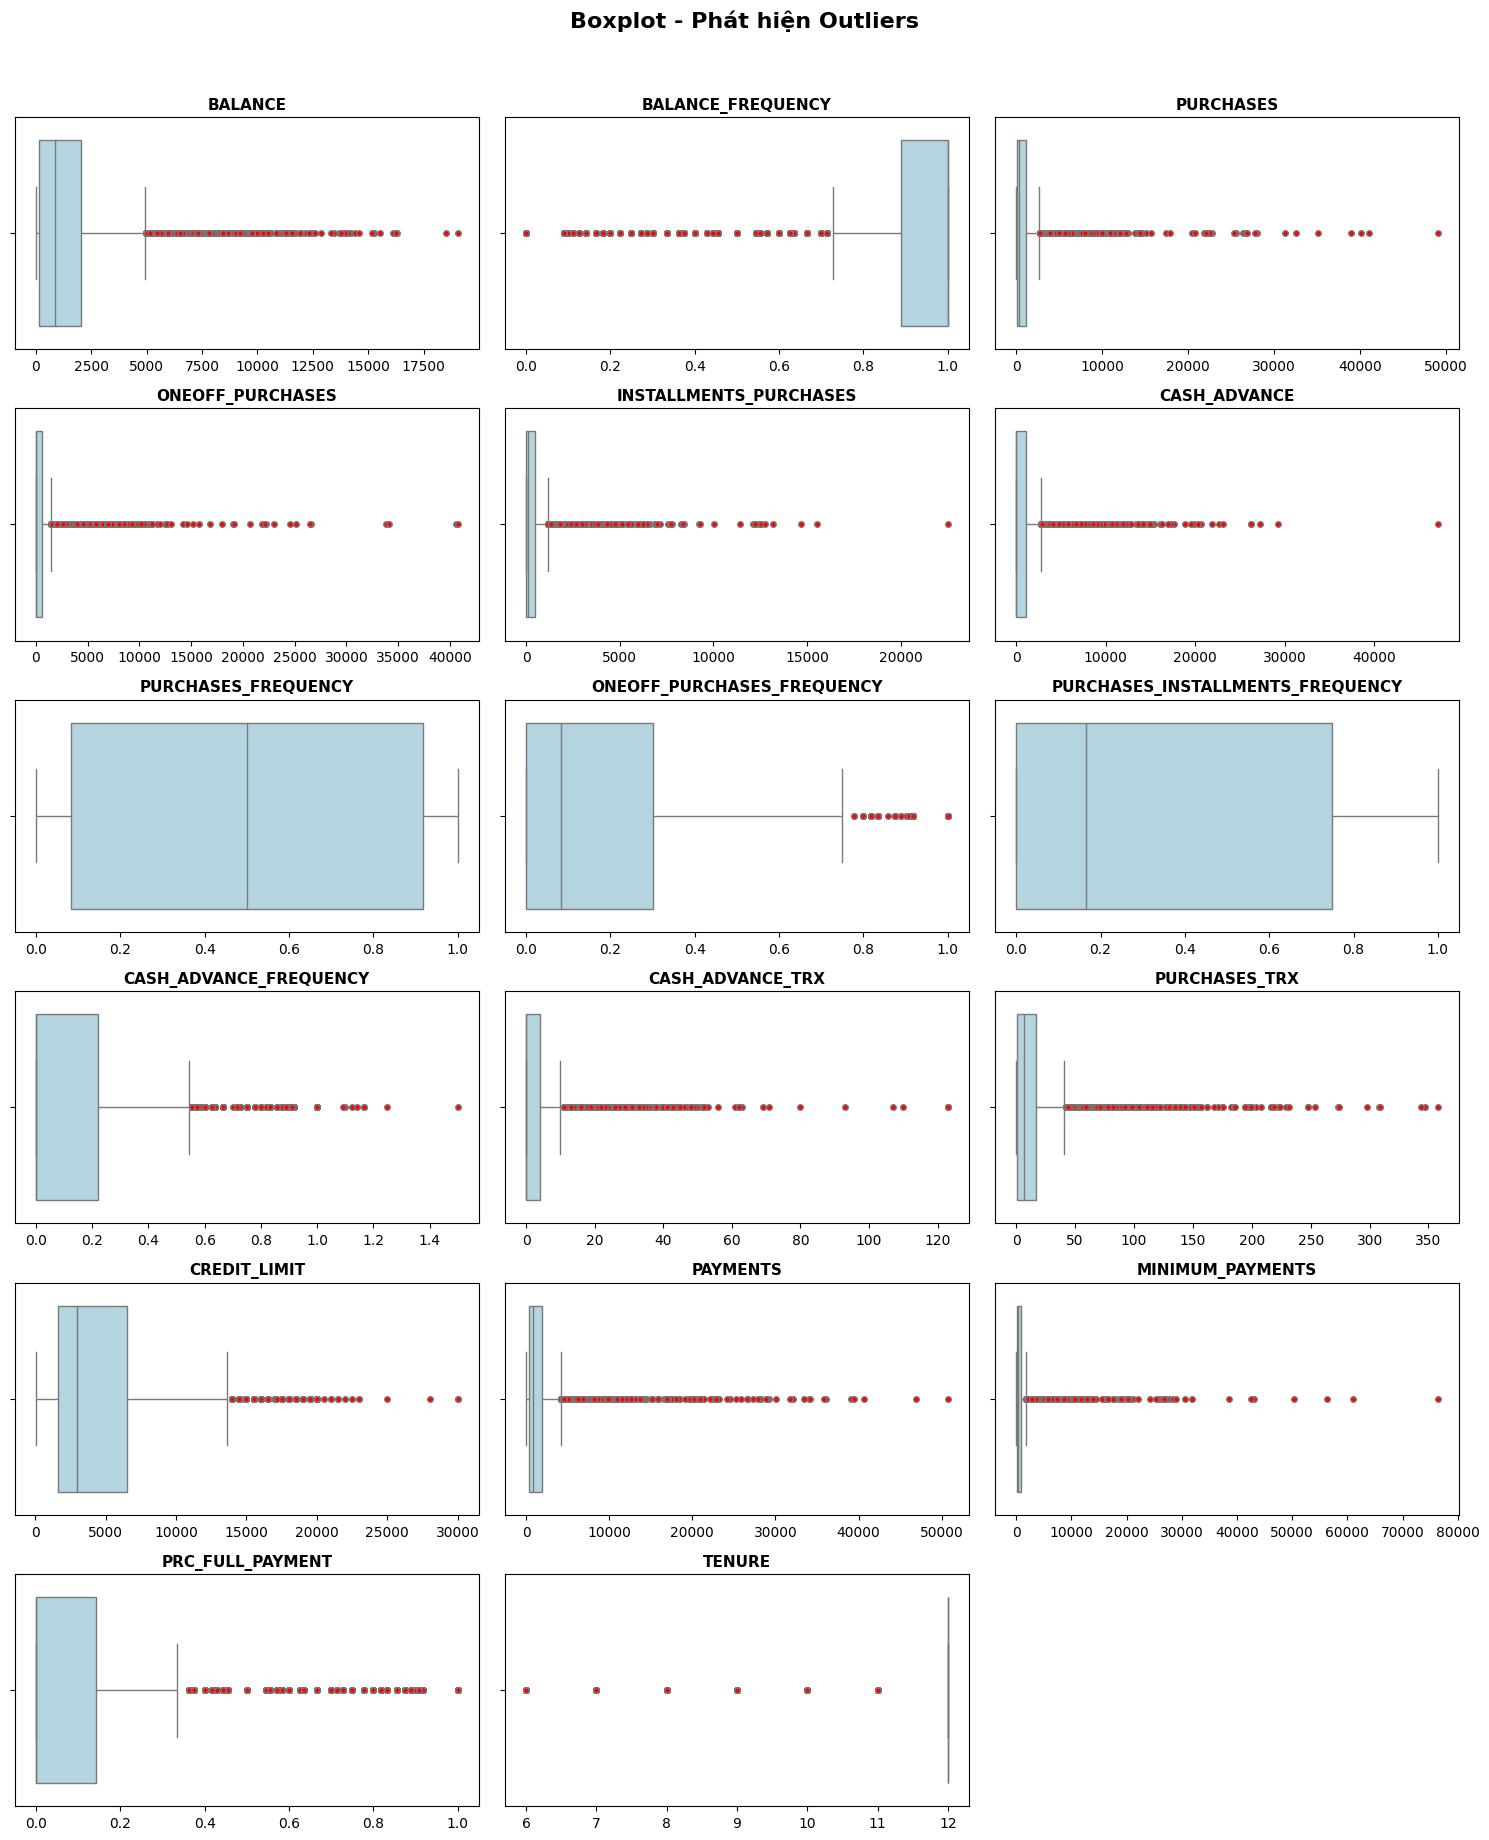

In [12]:
# Vẽ boxplot cho tất cả các biến số để phát hiện outliers
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

n_cols = 3
n_rows = (len(numeric_cols) + n_cols - 1) // n_cols

fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, n_rows * 3))
axes = axes.flatten()

for idx, col in enumerate(numeric_cols):
    ax = axes[idx]
    sns.boxplot(x=df[col], ax=ax, color='lightblue', flierprops=dict(markerfacecolor='red', marker='o', markersize=4))
    ax.set_title(f'{col}', fontsize=11, fontweight='bold')
    ax.set_xlabel('')

# Ẩn các subplot thừa
for idx in range(len(numeric_cols), len(axes)):
    axes[idx].set_visible(False)

plt.suptitle('Boxplot - Phát hiện Outliers', fontsize=16, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **1.5 Tong hop Insights tu EDA**

In [13]:
print("=" * 70)
print("TONG HOP INSIGHTS TU KHAM PHA DU LIEU (EDA)")
print("=" * 70)

print("""
[1] VE PHAN PHOI DU LIEU:
    - Tat ca bien AMOUNT lech phai MANH (skewness > 2)
      --> CAN log transform truoc khi clustering
    
    - Bien FREQUENCY co gia tri 0-1, nhieu gia tri cuc doan (0 hoac 1)
      --> CAN scale cung voi amount de dam bao cong bang

    - Nhieu bien co TY LE ZERO CAO (PURCHASES, CASH_ADVANCE, ...)
      --> Co nhieu NHOM KHACH HANG KHAC BIET

[2] VE OUTLIERS:
    - Cac bien amount co NHIEU outliers (10-25%)
    - Phuong phap IQR se loai qua nhieu du lieu
      --> NEN dung Winsorize (clip percentile) thay vi loai bo

[3] VE TUONG QUAN:
    - PURCHASES = ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES (redundant)
      --> CAN loai bo 1 trong 3
    
    - PURCHASES <-> PURCHASES_TRX tuong quan rat cao (r > 0.8)
      --> CAN loai bo 1

    - Cac nhom bien tuong quan manh:
      + Nhom mua sam: PURCHASES, ONEOFF, INSTALLMENTS, PURCHASES_TRX
      + Nhom ung tien: CASH_ADVANCE, CASH_ADVANCE_TRX, CASH_ADVANCE_FREQUENCY
      --> Co the dung PCA de giam chieu

[4] VE NHOM KHACH HANG DAC BIET:
    - Nhom KHONG MUA SAM nhung CO UNG TIEN MAT
      --> Hanh vi rui ro, can theo doi

    - Nhom mua sam THUONG XUYEN (frequency = 1)
      --> Khach hang trung thanh

    - Nhom THANH TOAN DAY DU (PRC_FULL_PAYMENT = 1)
      --> Khach hang tot, it rui ro
""")

print("=" * 70)
print("KET THUC PHAN EDA - SAN SANG CHO TIEN XU LY")
print("=" * 70)

TONG HOP INSIGHTS TU KHAM PHA DU LIEU (EDA)

[1] VE PHAN PHOI DU LIEU:
    - Tat ca bien AMOUNT lech phai MANH (skewness > 2)
      --> CAN log transform truoc khi clustering

    - Bien FREQUENCY co gia tri 0-1, nhieu gia tri cuc doan (0 hoac 1)
      --> CAN scale cung voi amount de dam bao cong bang

    - Nhieu bien co TY LE ZERO CAO (PURCHASES, CASH_ADVANCE, ...)
      --> Co nhieu NHOM KHACH HANG KHAC BIET

[2] VE OUTLIERS:
    - Cac bien amount co NHIEU outliers (10-25%)
    - Phuong phap IQR se loai qua nhieu du lieu
      --> NEN dung Winsorize (clip percentile) thay vi loai bo

[3] VE TUONG QUAN:
    - PURCHASES = ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES (redundant)
      --> CAN loai bo 1 trong 3

    - PURCHASES <-> PURCHASES_TRX tuong quan rat cao (r > 0.8)
      --> CAN loai bo 1

    - Cac nhom bien tuong quan manh:
      + Nhom mua sam: PURCHASES, ONEOFF, INSTALLMENTS, PURCHASES_TRX
      + Nhom ung tien: CASH_ADVANCE, CASH_ADVANCE_TRX, CASH_ADVANCE_FREQUENCY
      -->

## **2. TIỀN XỬ LÝ DỮ LIỆU**

### **Pipeline Tiền Xử Lý Dữ Liệu**

```
┌─────────────────────────────────────────────────────────────────────────────┐
│                        PIPELINE TIỀN XỬ LÝ DỮ LIỆU                          │
├─────────────────────────────────────────────────────────────────────────────┤
│  1. DROP ID                                                                  │
│     └── Loại bỏ CUST_ID (định danh, không mang thông tin phân cụm)          │
│                              ▼                                               │
│  2. XỬ LÝ MISSING VALUES                                                    │
│     ├── MINIMUM_PAYMENTS → KNNImputer (313 giá trị, sử dụng k=5 láng giềng) │
│     └── CREDIT_LIMIT → Median (chỉ 1 giá trị thiếu)                         │
│                              ▼                                               │
│  3. FEATURE ENGINEERING - TẠO BIẾN MỚI                                      │
│     ├── CREDIT_UTILIZATION = BALANCE / CREDIT_LIMIT                         │
│     ├── PAYMENT_RATIO = PAYMENTS / MINIMUM_PAYMENTS                         │
│     ├── CASH_RATIO = CASH_ADVANCE / CREDIT_LIMIT                            │
│     ├── PURCHASE_PER_TRX = PURCHASES / PURCHASES_TRX                        │
│     └── BALANCE_GROWTH_RATE = (PURCHASES + CASH_ADVANCE - PAYMENTS)/BALANCE │
│                              ▼                                               │
│  4. XỬ LÝ OUTLIERS (Winsorize)                                              │
│     └── Clip theo percentile 1% - 99% (giữ lại dữ liệu, không loại bỏ)      │
│                              ▼                                               │
│  5. GIẢM SKEWNESS (Log Transform)                                           │
│     └── Log1p transform cho các biến "amount" có skewness > 1               │
│                              ▼                                               │
│  6. XỬ LÝ ĐA CỘNG TUYẾN                                                     │
│     └── Loại bỏ biến có tương quan cao (|r| > 0.85)                         │
│                              ▼                                               │
│  7. CHUẨN HÓA (SCALING)                                                     │
│     └── StandardScaler (mean=0, std=1) - bắt buộc cho K-Means               │
│                              ▼                                               │
│  8. GIẢM CHIỀU VỚI PCA                                                      │
│     ├── PCA giữ 90% variance → Clustering                                   │
│     ├── PCA 2D → Trực quan hóa 2 chiều                                      │
│     └── PCA 3D → Trực quan hóa 3 chiều                                      │
└─────────────────────────────────────────────────────────────────────────────┘
```

---

**Lý do cho từng bước:**

| Bước | Kỹ thuật | Lý do |
|------|----------|-------|
| **1. Drop ID** | Loại bỏ CUST_ID | Mã định danh không có ý nghĩa phân cụm, chỉ dùng để ánh xạ kết quả |
| **2. Missing Values** | KNNImputer (k=5) | Sử dụng thông tin từ 5 khách hàng tương tự để ước lượng, tốt hơn median vì giữ được mối quan hệ giữa các biến |
| **3. Feature Engineering** | Tạo 5 biến tỷ lệ | Các tỷ lệ (ratios) mang nhiều ý nghĩa hơn giá trị tuyệt đối. VD: Số dư 10 triệu với hạn mức 100 triệu (10%) khác hoàn toàn với số dư 10 triệu hạn mức 11 triệu (90%) |
| **4. Winsorize** | Clip percentile 1-99% | Giữ lại dữ liệu thay vì loại bỏ outliers, tránh mất thông tin quan trọng |
| **5. Log Transform** | Log1p cho biến lệch phải | Giảm skewness giúp K-Means hoạt động tốt hơn vì thuật toán nhạy cảm với phân phối lệch |
| **6. Đa cộng tuyến** | Loại biến r > 0.85 | Giảm nhiễu, tránh các biến trùng lặp thông tin ảnh hưởng đến clustering |
| **7. StandardScaler** | Mean=0, Std=1 | K-Means dựa trên khoảng cách Euclidean, các biến phải cùng scale để không bị chi phối bởi biến có giá trị lớn |
| **8. PCA** | Giảm chiều | Giảm số chiều giúp giảm nhiễu, tăng tốc tính toán, và cho phép trực quan hóa kết quả |

### **2.1 Xử lý missing values**

In [14]:
# ============================================================================
# CHUẨN BỊ DỮ LIỆU - DROP ID VÀ TẠO BẢN SAO
# ============================================================================

# Tạo bản sao để xử lý (giữ nguyên df gốc)
df_processed = df.copy()

# Lưu CUST_ID để tham chiếu sau này nếu cần
customer_ids = df_processed['CUST_ID'].copy()

# Bỏ cột CUST_ID (định danh, không mang thông tin phân cụm)
ID_COL = 'CUST_ID'
df_processed = df_processed.drop(columns=[ID_COL])

print("=" * 60)
print("DROP CUST_ID")
print("=" * 60)
print(f"Da loai bo cot '{ID_COL}' - la ma dinh danh, khong co y nghia phan cum")
print(f"So cot con lai: {df_processed.shape[1]}")
print(f"Cac cot: {list(df_processed.columns)}")

DROP CUST_ID
Da loai bo cot 'CUST_ID' - la ma dinh danh, khong co y nghia phan cum
So cot con lai: 17
Cac cot: ['BALANCE', 'BALANCE_FREQUENCY', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'CASH_ADVANCE', 'PURCHASES_FREQUENCY', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CASH_ADVANCE_TRX', 'PURCHASES_TRX', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE']


In [15]:
# ============================================================================
# XỬ LÝ MISSING VALUES VỚI KNNImputer
# ============================================================================

from sklearn.impute import KNNImputer

print("=" * 70)
print("XỬ LÝ MISSING VALUES (KNNImputer)")
print("=" * 70)

# Kiểm tra missing values trước khi xử lý
missing_before = df_processed.isnull().sum()
missing_cols = missing_before[missing_before > 0]

print("\nMissing values TRUOC xu ly:")
if len(missing_cols) > 0:
    for col, count in missing_cols.items():
        pct = (count / len(df_processed)) * 100
        print(f"   - {col}: {count} ({pct:.2f}%)")
else:
    print("   Khong co missing values")

# Phan tich moi tuong quan giua MINIMUM_PAYMENTS va BALANCE
print("\n" + "-" * 70)
print("PHAN TICH: MINIMUM_PAYMENTS phu thuoc vao BALANCE")
print("-" * 70)

# Tinh correlation giua cac bien (bo qua missing)
temp_df = df_processed[['BALANCE', 'MINIMUM_PAYMENTS', 'CREDIT_LIMIT', 'PAYMENTS']].dropna()
corr_with_min_pay = temp_df.corr()['MINIMUM_PAYMENTS'].drop('MINIMUM_PAYMENTS')
print("\nTuong quan voi MINIMUM_PAYMENTS:")
for col, corr in corr_with_min_pay.items():
    print(f"   - {col}: r = {corr:.4f}")

print("\nVAN DE: MINIMUM_PAYMENTS phu thuoc BALANCE (r > 0)")
print("    Dien Median chung se LAM MAT moi tuong quan nay!")
print("    --> Su dung KNNImputer de tim khach hang TUONG TU va dien gia tri")

# So sanh phuong phap: Median vs KNNImputer
print("\n" + "-" * 70)
print("SO SANH PHUONG PHAP IMPUTATION")
print("-" * 70)

# Luu gia tri goc de so sanh
df_test = df_processed.copy()
missing_idx = df_test['MINIMUM_PAYMENTS'].isnull()
n_missing = missing_idx.sum()

# Phuong phap 1: Median chung
median_value = df_test['MINIMUM_PAYMENTS'].median()
print(f"\n[1] MEDIAN CHUNG:")
print(f"    Gia tri dien: {median_value:,.2f} (cho tat ca {n_missing} missing)")
print(f"    Van de: Khong xet den BALANCE cua tung khach hang")

# Phuong phap 2: Median theo nhom BALANCE
print(f"\n[2] MEDIAN THEO NHOM BALANCE:")
df_test['BALANCE_GROUP'] = pd.qcut(df_test['BALANCE'], q=5, labels=['Very Low', 'Low', 'Medium', 'High', 'Very High'])
median_by_group = df_test.groupby('BALANCE_GROUP')['MINIMUM_PAYMENTS'].median()
print("    Median theo nhom BALANCE:")
for group, val in median_by_group.items():
    print(f"       {group}: {val:,.2f}")
print("    Uu diem: Xet den moi tuong quan, de hieu")

# Phuong phap 3: KNNImputer
print(f"\n[3] KNNImputer (k=5):")
print("    Tim 5 khach hang TUONG TU NHAT (dua tren tat ca features)")
print("    Dien gia tri = Trung binh cua 5 neighbor")
print("    Uu diem: Tu dong xet den NHIEU features cung luc")
print("    --> DAY LA PHUONG PHAP DUOC CHON!")

# Thuc hien KNNImputer
print("\n" + "-" * 70)
print("THUC HIEN KNNImputer")
print("-" * 70)

# Chon cac features lien quan de KNN tim neighbor
impute_features = ['BALANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASES', 
                   'CASH_ADVANCE', 'MINIMUM_PAYMENTS']
impute_features = [f for f in impute_features if f in df_processed.columns]

# Tao KNNImputer
knn_imputer = KNNImputer(n_neighbors=5, weights='distance')

# Ap dung
df_impute = df_processed[impute_features].copy()
df_imputed = pd.DataFrame(
    knn_imputer.fit_transform(df_impute),
    columns=impute_features,
    index=df_processed.index
)

# Cap nhat lai MINIMUM_PAYMENTS
df_processed['MINIMUM_PAYMENTS'] = df_imputed['MINIMUM_PAYMENTS']

# Hien thi ket qua
print(f"Da dien {n_missing} gia tri missing bang KNNImputer (k=5)")
print(f"\nGia tri MINIMUM_PAYMENTS sau khi dien (cho cac dong truoc do missing):")
filled_values = df_processed.loc[missing_idx, 'MINIMUM_PAYMENTS']
print(f"   - Min:    {filled_values.min():>12,.2f}")
print(f"   - Max:    {filled_values.max():>12,.2f}")
print(f"   - Mean:   {filled_values.mean():>12,.2f}")
print(f"   - Median: {filled_values.median():>12,.2f}")

# So sanh voi Median chung
print(f"\nSo sanh:")
print(f"   - Median chung:        {median_value:>12,.2f}")
print(f"   - KNN mean filled:     {filled_values.mean():>12,.2f}")
print(f"   - KNN phu hop hon vi xet den BALANCE cua tung khach hang")

# Xu ly CREDIT_LIMIT (chi 1 missing)
if 'CREDIT_LIMIT' in df_processed.columns and df_processed['CREDIT_LIMIT'].isnull().any():
    median_credit = df_processed['CREDIT_LIMIT'].median()
    df_processed['CREDIT_LIMIT'] = df_processed['CREDIT_LIMIT'].fillna(median_credit)
    print(f"\nCREDIT_LIMIT: Dien bang MEDIAN = {median_credit:,.2f}")
    print(f"     (Chi 1 gia tri thieu, KNN khong can thiet)")

# Kiem tra ket qua cuoi cung
missing_after = df_processed.isnull().sum().sum()
print(f"\n" + "=" * 70)
print(f"Missing values SAU xu ly: {missing_after}")
print("HOAN THANH XU LY MISSING VALUES VOI KNNImputer!")
print("=" * 70)

# Cleanup
df_test.drop('BALANCE_GROUP', axis=1, inplace=True, errors='ignore')

XỬ LÝ MISSING VALUES (KNNImputer)

Missing values TRUOC xu ly:
   - CREDIT_LIMIT: 1 (0.01%)
   - MINIMUM_PAYMENTS: 313 (3.50%)

----------------------------------------------------------------------
PHAN TICH: MINIMUM_PAYMENTS phu thuoc vao BALANCE
----------------------------------------------------------------------

Tuong quan voi MINIMUM_PAYMENTS:
   - BALANCE: r = 0.3987
   - CREDIT_LIMIT: r = 0.1267
   - PAYMENTS: r = 0.1266

VAN DE: MINIMUM_PAYMENTS phu thuoc BALANCE (r > 0)
    Dien Median chung se LAM MAT moi tuong quan nay!
    --> Su dung KNNImputer de tim khach hang TUONG TU va dien gia tri

----------------------------------------------------------------------
SO SANH PHUONG PHAP IMPUTATION
----------------------------------------------------------------------

[1] MEDIAN CHUNG:
    Gia tri dien: 312.34 (cho tat ca 313 missing)
    Van de: Khong xet den BALANCE cua tung khach hang

[2] MEDIAN THEO NHOM BALANCE:
    Median theo nhom BALANCE:
       Very Low: 122.20
       L

### **2.2 Feature Engineering - Tạo biến mới**

**Tại sao cần tạo biến mới?**
- Dữ liệu thô đôi khi không phản ánh hết hành vi khách hàng
- Trong bài toán tín dụng, các **tỷ lệ (Ratios)** thường mang nhiều ý nghĩa phân loại hơn giá trị tuyệt đối
- Ví dụ: Khách hàng A có số dư 10 triệu với hạn mức 100 triệu (10%) khác hoàn toàn với khách B có số dư 10 triệu với hạn mức 11 triệu (90%)

**Các biến sẽ tạo mới:**

| Biến Mới | Công Thức | Ý Nghĩa |
|----------|-----------|---------|
| `CREDIT_UTILIZATION` | BALANCE / CREDIT_LIMIT | Tỷ lệ sử dụng hạn mức - Cao = rủi ro cao |
| `PAYMENT_RATIO` | PAYMENTS / MINIMUM_PAYMENTS | Tỷ lệ thanh toán - Thấp = chỉ trả tối thiểu |
| `CASH_RATIO` | CASH_ADVANCE / CREDIT_LIMIT | Tỷ lệ rút tiền mặt - Cao = rủi ro cao |
| `PURCHASE_PER_TRX` | PURCHASES / PURCHASES_TRX | Giá trị trung bình mỗi giao dịch mua hàng |
| `BALANCE_GROWTH_RATE` | (PURCHASES + CASH_ADVANCE - PAYMENTS) / BALANCE | Tốc độ tích lũy nợ - Cao = rủi ro cao |

In [16]:
# Lưu số cột ban đầu để so sánh sau
n_cols_before = df_processed.shape[1]
print(f"[INFO] Số cột ban đầu: {n_cols_before}")

[INFO] Số cột ban đầu: 17


#### **2.2.1 CREDIT_UTILIZATION - Tỷ lệ sử dụng hạn mức**

**Công thức:** `CREDIT_UTILIZATION = BALANCE / CREDIT_LIMIT`

**Ý nghĩa:** Khách hàng dùng 90% hạn mức rất khác với khách dùng 10%. Tỷ lệ cao cho thấy rủi ro cao.

In [17]:
df_processed['CREDIT_UTILIZATION'] = np.where(
    df_processed['CREDIT_LIMIT'] > 0,
    df_processed['BALANCE'] / df_processed['CREDIT_LIMIT'],
    0
)

df_processed['CREDIT_UTILIZATION'] = df_processed['CREDIT_UTILIZATION'].clip(lower=0, upper=1.5)

print("Đã tạo CREDIT_UTILIZATION")
print(f"Range: [{df_processed['CREDIT_UTILIZATION'].min():.4f}, {df_processed['CREDIT_UTILIZATION'].max():.4f}]")
print(f"Mean: {df_processed['CREDIT_UTILIZATION'].mean():.4f} | Median: {df_processed['CREDIT_UTILIZATION'].median():.4f}")

Đã tạo CREDIT_UTILIZATION
Range: [0.0000, 1.5000]
Mean: 0.3871 | Median: 0.3027


#### **2.2.2 PAYMENT_RATIO - Tỷ lệ thanh toán**

**Công thức:** `PAYMENT_RATIO = PAYMENTS / MINIMUM_PAYMENTS`

**Ý nghĩa:** Phân biệt nhóm chỉ trả tối thiểu vs nhóm trả hết nợ. Tỷ lệ thấp cho thấy khách hàng chỉ trả tối thiểu.

In [18]:
df_processed['PAYMENT_RATIO'] = np.where(
    df_processed['MINIMUM_PAYMENTS'] > 0,
    df_processed['PAYMENTS'] / df_processed['MINIMUM_PAYMENTS'],
    np.where(df_processed['PAYMENTS'] > 0, 5, 0)
)

df_processed['PAYMENT_RATIO'] = df_processed['PAYMENT_RATIO'].clip(lower=0, upper=10)

pct_at_max = (df_processed['PAYMENT_RATIO'] == 10).sum() / len(df_processed) * 100

print("Đã tạo PAYMENT_RATIO")
print(f"Range: [{df_processed['PAYMENT_RATIO'].min():.4f}, {df_processed['PAYMENT_RATIO'].max():.4f}]")
print(f"Mean: {df_processed['PAYMENT_RATIO'].mean():.4f} | Median: {df_processed['PAYMENT_RATIO'].median():.4f}")
print(f"% tại giá trị max (=10): {pct_at_max:.1f}%")

Đã tạo PAYMENT_RATIO
Range: [0.0000, 10.0000]
Mean: 3.6705 | Median: 2.0490
% tại giá trị max (=10): 14.5%


#### **2.2.3 CASH_RATIO - Tỷ lệ rút tiền mặt**

**Công thức:** `CASH_RATIO = CASH_ADVANCE / CREDIT_LIMIT`

**Ý nghĩa:** Phát hiện nhóm chuyên rút tiền mặt - đây thường là nhóm rủi ro cao trong tín dụng.

In [19]:
df_processed['CASH_RATIO'] = np.where(
    df_processed['CREDIT_LIMIT'] > 0,
    df_processed['CASH_ADVANCE'] / df_processed['CREDIT_LIMIT'],
    0
)

df_processed['CASH_RATIO'] = df_processed['CASH_RATIO'].clip(lower=0, upper=1.5)

print("Đã tạo CASH_RATIO")
print(f"Range: [{df_processed['CASH_RATIO'].min():.4f}, {df_processed['CASH_RATIO'].max():.4f}]")
print(f"Mean: {df_processed['CASH_RATIO'].mean():.4f} | Median: {df_processed['CASH_RATIO'].median():.4f}")

Đã tạo CASH_RATIO
Range: [0.0000, 1.5000]
Mean: 0.2282 | Median: 0.0000


#### **2.2.4 PURCHASE_PER_TRX - Giá trị trung bình mỗi giao dịch**

**Công thức:** `PURCHASE_PER_TRX = PURCHASES / PURCHASES_TRX`

**Ý nghĩa:** Phân biệt khách hàng mua ít nhưng giá trị cao vs khách hàng mua nhiều nhưng giá trị thấp.

In [20]:
df_processed['PURCHASE_PER_TRX'] = np.where(
    df_processed['PURCHASES_TRX'] > 0,
    df_processed['PURCHASES'] / df_processed['PURCHASES_TRX'],
    0
)

p99_purchase_per_trx = df_processed['PURCHASE_PER_TRX'].quantile(0.99)
df_processed['PURCHASE_PER_TRX'] = df_processed['PURCHASE_PER_TRX'].clip(lower=0, upper=p99_purchase_per_trx)

print("Đã tạo PURCHASE_PER_TRX")
print(f"Range: [{df_processed['PURCHASE_PER_TRX'].min():.4f}, {df_processed['PURCHASE_PER_TRX'].max():.4f}]")
print(f"Mean: {df_processed['PURCHASE_PER_TRX'].mean():.4f} | Median: {df_processed['PURCHASE_PER_TRX'].median():.4f}")
print(f"P99 clip value: {p99_purchase_per_trx:.2f}")

Đã tạo PURCHASE_PER_TRX
Range: [0.0000, 756.9921]
Mean: 68.7387 | Median: 41.3939
P99 clip value: 756.99


#### **2.2.5 BALANCE_GROWTH_RATE - Tốc độ tích lũy nợ**

**Công thức:** `BALANCE_GROWTH_RATE = (PURCHASES + CASH_ADVANCE - PAYMENTS) / BALANCE`

**Ý nghĩa:** Phát hiện khách hàng đang tích lũy nợ nhanh (giá trị dương cao = rủi ro cao).

In [21]:
df_processed['BALANCE_GROWTH_RATE'] = 0.0

mask_valid = df_processed['BALANCE'] > 0
df_processed.loc[mask_valid, 'BALANCE_GROWTH_RATE'] = (
    (df_processed.loc[mask_valid, 'PURCHASES'] + 
     df_processed.loc[mask_valid, 'CASH_ADVANCE'] - 
     df_processed.loc[mask_valid, 'PAYMENTS']) / 
    df_processed.loc[mask_valid, 'BALANCE']
)

df_processed['BALANCE_GROWTH_RATE'] = df_processed['BALANCE_GROWTH_RATE'].clip(lower=-2, upper=2)

pct_positive = (df_processed['BALANCE_GROWTH_RATE'] > 0).sum() / len(df_processed) * 100
pct_negative = (df_processed['BALANCE_GROWTH_RATE'] < 0).sum() / len(df_processed) * 100

print("Đã tạo BALANCE_GROWTH_RATE")
print(f"Range: [{df_processed['BALANCE_GROWTH_RATE'].min():.4f}, {df_processed['BALANCE_GROWTH_RATE'].max():.4f}]")
print(f"Mean: {df_processed['BALANCE_GROWTH_RATE'].mean():.4f} | Median: {df_processed['BALANCE_GROWTH_RATE'].median():.4f}")
print(f"% tăng nợ (>0): {pct_positive:.1f}% | % giảm nợ (<0): {pct_negative:.1f}%")

Đã tạo BALANCE_GROWTH_RATE
Range: [-2.0000, 2.0000]
Mean: 0.0426 | Median: 0.0737
% tăng nợ (>0): 52.9% | % giảm nợ (<0): 46.2%


#### **2.2.6 Kiểm tra phân phối các biến mới**

Sau khi tạo các biến mới, cần kiểm tra phân phối để đảm bảo chúng không có extreme values và phù hợp cho clustering.

In [22]:
print("=" * 70)
print("KIỂM TRA PHÂN PHỐI CÁC BIẾN MỚI:")
print("=" * 70)

new_features = ['CREDIT_UTILIZATION', 'PAYMENT_RATIO', 'CASH_RATIO', 
                'PURCHASE_PER_TRX', 'BALANCE_GROWTH_RATE']

for feat in new_features:
    q01 = df_processed[feat].quantile(0.01)
    q99 = df_processed[feat].quantile(0.99)
    skew = df_processed[feat].skew()
    print(f"\n{feat}:")
    print(f"   P1={q01:.3f} | P99={q99:.3f} | Skew={skew:.2f}")

n_cols_after = df_processed.shape[1]
print("\n" + "=" * 70)
print(f"Đã tạo {n_cols_after - n_cols_before} biến mới!")
print("=" * 70)
print(f"\nCác biến mới đã được CLIP để tránh extreme values:")
print("   1. CREDIT_UTILIZATION  - Clip [0, 1.5]")
print("   2. PAYMENT_RATIO       - Clip [0, 10]")  
print("   3. CASH_RATIO          - Clip [0, 1.5]")
print("   4. PURCHASE_PER_TRX    - Clip [0, P99]")
print("   5. BALANCE_GROWTH_RATE - Clip [-2, 2]")

print("\n" + "-" * 70)
print("THỐNG KÊ CÁC BIẾN MỚI:")
print("-" * 70)
display(df_processed[new_features].describe().round(4))

KIỂM TRA PHÂN PHỐI CÁC BIẾN MỚI:

CREDIT_UTILIZATION:
   P1=0.000 | P99=1.057 | Skew=0.47

PAYMENT_RATIO:
   P1=0.000 | P99=10.000 | Skew=0.84

CASH_RATIO:
   P1=0.000 | P99=1.500 | Skew=1.69

PURCHASE_PER_TRX:
   P1=0.000 | P99=753.566 | Skew=4.04

BALANCE_GROWTH_RATE:
   P1=-2.000 | P99=2.000 | Skew=-0.22

Đã tạo 5 biến mới!

Các biến mới đã được CLIP để tránh extreme values:
   1. CREDIT_UTILIZATION  - Clip [0, 1.5]
   2. PAYMENT_RATIO       - Clip [0, 10]
   3. CASH_RATIO          - Clip [0, 1.5]
   4. PURCHASE_PER_TRX    - Clip [0, P99]
   5. BALANCE_GROWTH_RATE - Clip [-2, 2]

----------------------------------------------------------------------
THỐNG KÊ CÁC BIẾN MỚI:
----------------------------------------------------------------------


,CREDIT_UTILIZATION,PAYMENT_RATIO,CASH_RATIO,PURCHASE_PER_TRX,BALANCE_GROWTH_RATE
count,8950.0000,8950.0000,8950.0000,8950.0000,8950.0000
mean,0.3871,3.6705,0.2282,68.7387,0.0426
std,0.3529,3.4530,0.3599,108.0475,1.1994
min,0.0000,0.0000,0.0000,0.0000,-2.0000
25%,0.0415,0.9189,0.0000,11.9834,-0.5274
50%,0.3027,2.0490,0.0000,41.3939,0.0737
75%,0.7176,6.0709,0.3529,78.6623,0.8622
max,1.5000,10.0000,1.5000,756.9921,2.0000


### **2.3 Xử lý outliers**

In [23]:
# ============================================================================
# XỬ LÝ OUTLIERS - WINSORIZE (Clip theo percentile 1%-99%)
# ============================================================================

print("=" * 60)
print("XỬ LÝ OUTLIERS - WINSORIZE")
print("=" * 60)
print("\nPhuong phap: Clip (Winsorize) theo percentile 1% - 99%")
print("   Giu lai tat ca observations, chi dieu chinh gia tri cuc doan")
print("   Phu hop hon IQR cho du lieu lech phai (skewed)")

# Định nghĩa các cột cần winsorize (các biến "amount" có nhiều outliers)
cols_to_winsorize = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'
]

# Thực hiện winsorize
winsorize_summary = []
for col in cols_to_winsorize:
    if col in df_processed.columns:
        # Lưu giá trị trước khi xử lý
        before_min, before_max = df_processed[col].min(), df_processed[col].max()
        
        # Tính percentile 1% và 99%
        p1 = df_processed[col].quantile(0.01)
        p99 = df_processed[col].quantile(0.99)
        
        # Clip giá trị
        df_processed[col] = df_processed[col].clip(lower=p1, upper=p99)
        
        # Lưu summary
        after_min, after_max = df_processed[col].min(), df_processed[col].max()
        winsorize_summary.append({
            'Biến': col,
            'Min trước': before_min,
            'Min sau': after_min,
            'Max trước': before_max,
            'Max sau': after_max,
            'P1': p1,
            'P99': p99
        })

# Hien thi ket qua
winsorize_df = pd.DataFrame(winsorize_summary)
print("\nKet qua Winsorize (Clip 1%-99%):")
print("-" * 100)
for _, row in winsorize_df.iterrows():
    print(f"\n{row['Biến']}:")
    print(f"   Range truoc: [{row['Min trước']:>12,.2f} - {row['Max trước']:>12,.2f}]")
    print(f"   Range sau:   [{row['Min sau']:>12,.2f} - {row['Max sau']:>12,.2f}]")
    print(f"   Clip bounds: [{row['P1']:>12,.2f} - {row['P99']:>12,.2f}]")

print("\nHoan thanh xu ly outliers voi Winsorize!")

XỬ LÝ OUTLIERS - WINSORIZE

Phuong phap: Clip (Winsorize) theo percentile 1% - 99%
   Giu lai tat ca observations, chi dieu chinh gia tri cuc doan
   Phu hop hon IQR cho du lieu lech phai (skewed)

Ket qua Winsorize (Clip 1%-99%):
----------------------------------------------------------------------------------------------------

BALANCE:
   Range truoc: [        0.00 -    19,043.14]
   Range sau:   [        0.07 -     9,338.80]
   Clip bounds: [        0.07 -     9,338.80]

PURCHASES:
   Range truoc: [        0.00 -    49,039.57]
   Range sau:   [        0.00 -     8,977.29]
   Clip bounds: [        0.00 -     8,977.29]

ONEOFF_PURCHASES:
   Range truoc: [        0.00 -    40,761.25]
   Range sau:   [        0.00 -     6,689.90]
   Clip bounds: [        0.00 -     6,689.90]

INSTALLMENTS_PURCHASES:
   Range truoc: [        0.00 -    22,500.00]
   Range sau:   [        0.00 -     3,886.24]
   Clip bounds: [        0.00 -     3,886.24]

CASH_ADVANCE:
   Range truoc: [        0.00 -    

### **2.3 Giảm Skewness (Log Transform)**

In [24]:
# ============================================================================
# GIẢM SKEWNESS - LOG1P TRANSFORM
# ============================================================================

print("=" * 60)
print("GIẢM SKEWNESS - LOG1P TRANSFORM")
print("=" * 60)
print("\nPhuong phap: log1p(x) = log(1 + x)")
print("   Xu ly duoc gia tri 0 (khong bi -inf nhu log(0))")
print("   Giam skewness cho cac bien lech phai")
print("   Giup K-Means hoat dong tot hon (thuat toan nhay voi scale)")

# Cac bien "amount" co skewness cao can transform
cols_to_log = [
    'BALANCE', 'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES',
    'CASH_ADVANCE', 'CREDIT_LIMIT', 'PAYMENTS', 'MINIMUM_PAYMENTS'
]

# So sanh skewness truoc va sau transform
print("\nSo sanh Skewness truoc va sau Log1p Transform:")
print("-" * 70)
print(f"{'Biến':<30} {'Skew Trước':>15} {'Skew Sau':>15} {'Giảm (%)':>10}")
print("-" * 70)

skewness_comparison = []
for col in cols_to_log:
    if col in df_processed.columns:
        skew_before = df_processed[col].skew()
        
        # Apply log1p transform
        df_processed[col] = np.log1p(df_processed[col])
        
        skew_after = df_processed[col].skew()
        reduction = ((abs(skew_before) - abs(skew_after)) / abs(skew_before)) * 100 if skew_before != 0 else 0
        
        skewness_comparison.append({
            'Biến': col,
            'Skew Trước': skew_before,
            'Skew Sau': skew_after,
            'Giảm (%)': reduction
        })
        
        print(f"{col:<30} {skew_before:>15.3f} {skew_after:>15.3f} {reduction:>9.1f}%")

print("-" * 70)
print("\nHoan thanh Log1p Transform!")
print("  Cac bien da duoc transform de giam skewness")
print("  Phan phoi gan doi xung hon, phu hop cho K-Means")

GIẢM SKEWNESS - LOG1P TRANSFORM

Phuong phap: log1p(x) = log(1 + x)
   Xu ly duoc gia tri 0 (khong bi -inf nhu log(0))
   Giam skewness cho cac bien lech phai
   Giup K-Means hoat dong tot hon (thuat toan nhay voi scale)

So sanh Skewness truoc va sau Log1p Transform:
----------------------------------------------------------------------
Biến                                Skew Trước        Skew Sau   Giảm (%)
----------------------------------------------------------------------
BALANCE                                  1.932          -0.865      55.3%
PURCHASES                                2.992          -0.777      74.0%
ONEOFF_PURCHASES                         3.351           0.176      94.7%
INSTALLMENTS_PURCHASES                   2.874          -0.034      98.8%
CASH_ADVANCE                             2.724           0.259      90.5%
CREDIT_LIMIT                             1.332          -0.057      95.7%
PAYMENTS                                 3.005          -1.833      39.

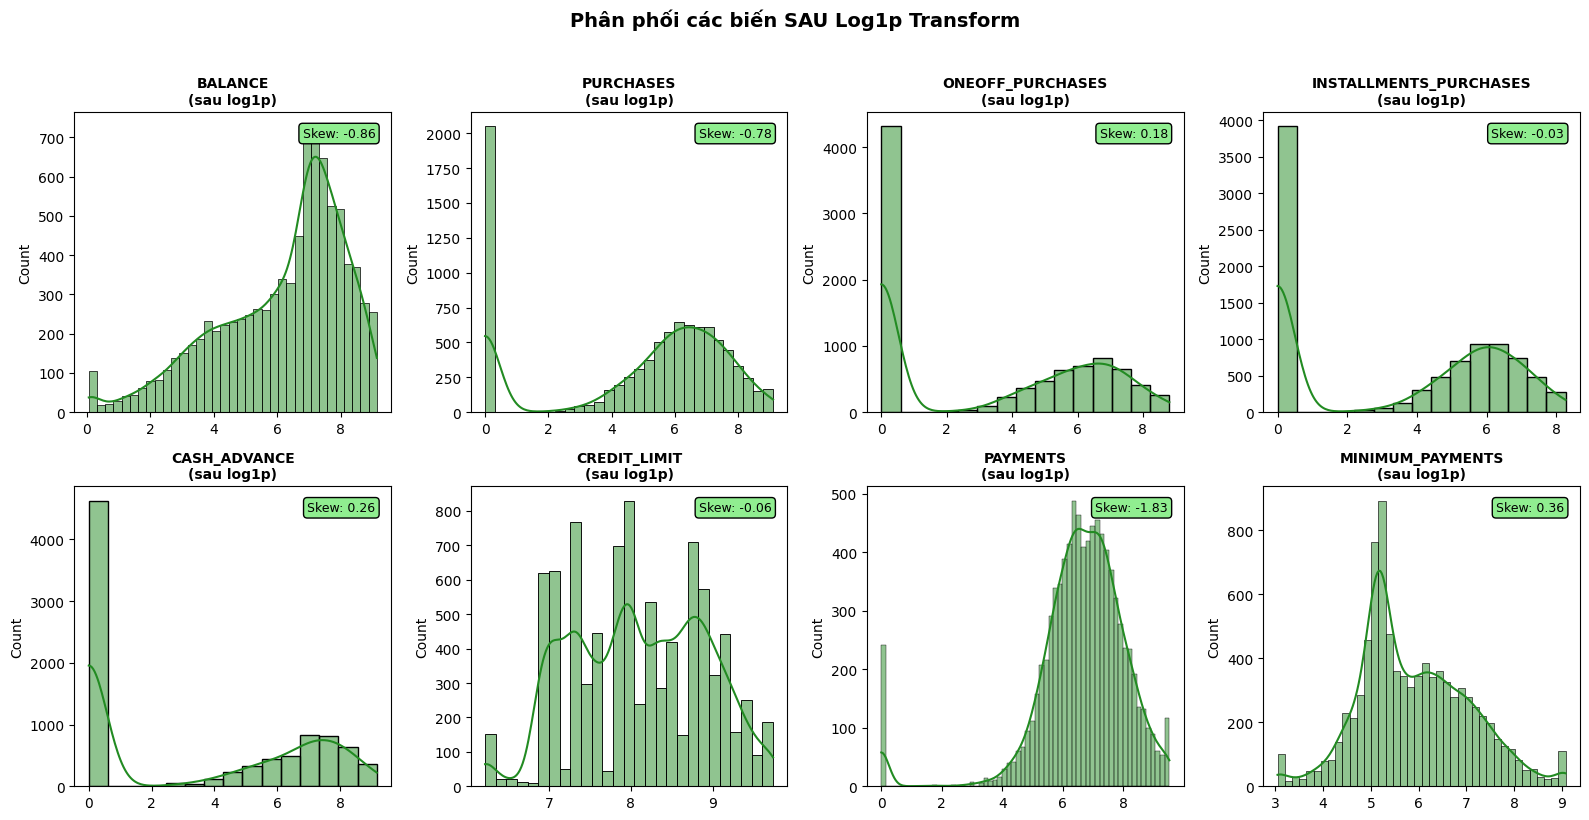

In [25]:
# Visualize phân phối SAU log transform
fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(cols_to_log):
    if col in df_processed.columns and idx < len(axes):
        ax = axes[idx]
        sns.histplot(df_processed[col], kde=True, ax=ax, color='forestgreen', edgecolor='black')
        ax.set_title(f'{col}\n(sau log1p)', fontsize=10, fontweight='bold')
        ax.set_xlabel('')
        
        # Thêm skewness
        skew_val = df_processed[col].skew()
        ax.text(0.95, 0.95, f'Skew: {skew_val:.2f}', transform=ax.transAxes,
                ha='right', va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='lightgreen'))

plt.suptitle('Phân phối các biến SAU Log1p Transform', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### **2.4 Feature Selection - Xử lý đa cộng tuyến**

FEATURE SELECTION - XỬ LÝ ĐA CỘNG TUYẾN

Phan tich tuong quan cao (|r| > 0.85):
------------------------------------------------------------


,Feature 1,Feature 2,Correlation
0,INSTALLMENTS_PURCHASES,PURCHASES_INSTALLMENTS_FREQUENCY,0.878963
1,PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,0.862934


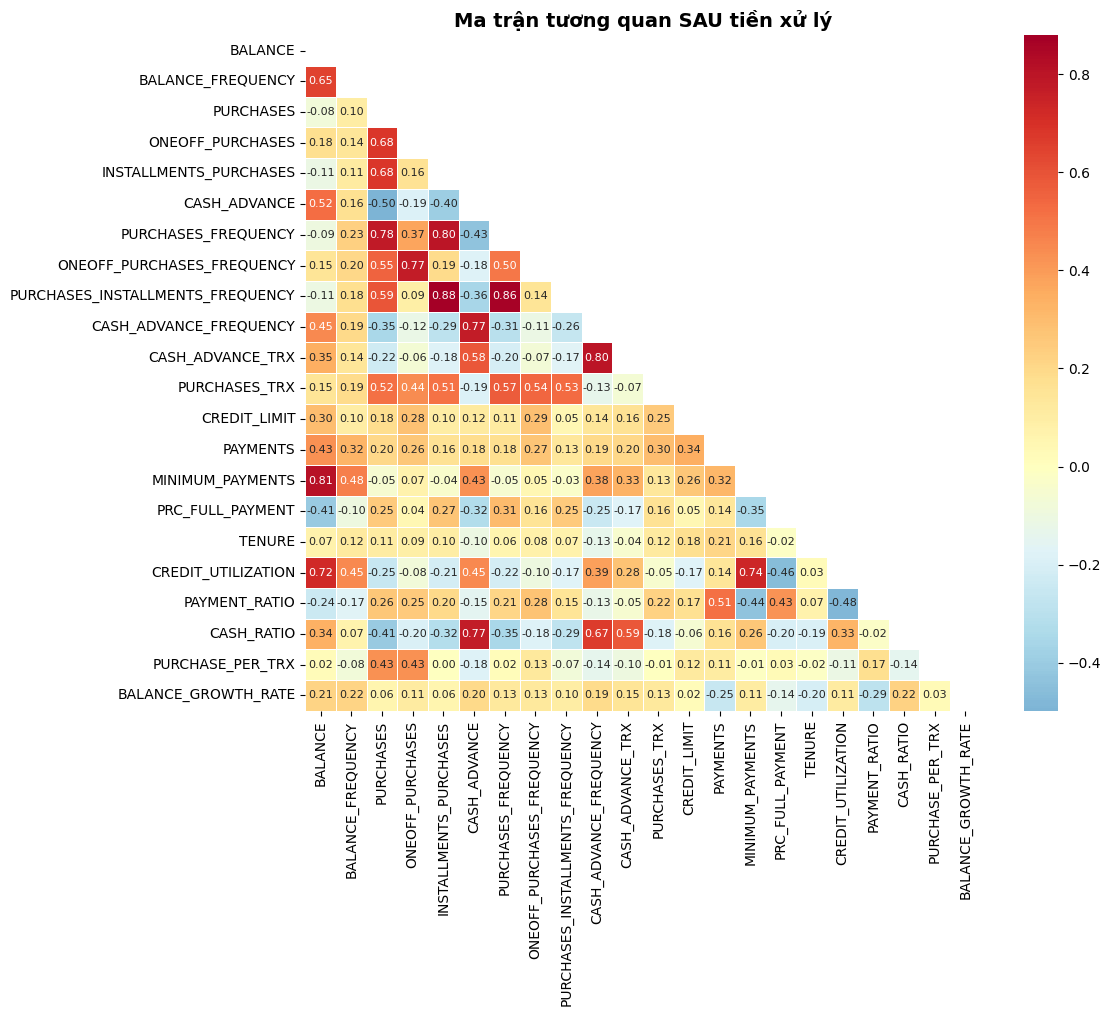


Phan tich cac cap bien co tuong quan cao:
------------------------------------------------------------
Cac cap bien co |r| > 0.7:
   - INSTALLMENTS_PURCHASES <-> PURCHASES_INSTALLMENTS_FREQUENCY: r = 0.879
   - PURCHASES_FREQUENCY <-> PURCHASES_INSTALLMENTS_FREQUENCY: r = 0.863
   - BALANCE <-> MINIMUM_PAYMENTS: r = 0.809
   - CASH_ADVANCE_FREQUENCY <-> CASH_ADVANCE_TRX: r = 0.8
   - INSTALLMENTS_PURCHASES <-> PURCHASES_FREQUENCY: r = 0.795
   - PURCHASES <-> PURCHASES_FREQUENCY: r = 0.782
   - ONEOFF_PURCHASES <-> ONEOFF_PURCHASES_FREQUENCY: r = 0.769
   - CASH_ADVANCE <-> CASH_ADVANCE_FREQUENCY: r = 0.769
   - CASH_ADVANCE <-> CASH_RATIO: r = 0.768
   - MINIMUM_PAYMENTS <-> CREDIT_UTILIZATION: r = 0.739
   - BALANCE <-> CREDIT_UTILIZATION: r = 0.725


In [26]:
# ============================================================================
# FEATURE SELECTION - XỬ LÝ ĐA CỘNG TUYẾN
# ============================================================================

print("=" * 60)
print("FEATURE SELECTION - XỬ LÝ ĐA CỘNG TUYẾN")
print("=" * 60)

# Kiem tra tuong quan cao
print("\nPhan tich tuong quan cao (|r| > 0.85):")
print("-" * 60)

corr_matrix = df_processed.corr()
high_corr_features = []

for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.85:
            high_corr_features.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': corr_matrix.iloc[i, j]
            })

if high_corr_features:
    high_corr_table = pd.DataFrame(high_corr_features)
    display(high_corr_table.sort_values('Correlation', ascending=False))
else:
    print("   Không có cặp biến nào có tương quan > 0.85")

# Vẽ ma trận tương quan sau xử lý
plt.figure(figsize=(12, 10))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, square=True, linewidths=0.5, annot_kws={"size": 8})
plt.title('Ma trận tương quan SAU tiền xử lý', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# Phan tich cac cap tuong quan cao
print("\nPhan tich cac cap bien co tuong quan cao:")
print("-" * 60)

# Tim cac cap co correlation > 0.7
high_corr_07 = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.7:
            high_corr_07.append({
                'Feature 1': corr_matrix.columns[i],
                'Feature 2': corr_matrix.columns[j],
                'Correlation': round(corr_matrix.iloc[i, j], 3)
            })

if high_corr_07:
    print("Cac cap bien co |r| > 0.7:")
    for pair in sorted(high_corr_07, key=lambda x: abs(x['Correlation']), reverse=True):
        print(f"   - {pair['Feature 1']} <-> {pair['Feature 2']}: r = {pair['Correlation']}")
else:
    print("   Khong co cap bien nao co tuong quan > 0.7")

In [27]:
# ============================================================================
# QUYẾT ĐỊNH LOẠI BỎ BIẾN (Marketing-first: dễ diễn giải, hạn chế trùng nghĩa)
# ============================================================================

print("=" * 60)
print("QUYẾT ĐỊNH LOẠI BỎ BIẾN")
print("=" * 60)

# Ý tưởng (marketing thuần):
# - Ưu tiên biến dạng tỷ lệ/tần suất (actionable) hơn là biến đếm/biến trùng nghĩa
# - Loại bớt biến mô tả cùng một hành vi để cụm dễ đặt tên và gắn chiến dịch

features_to_drop = []

# 1) Luôn loại PURCHASES nếu đã có 2 thành phần ONEOFF + INSTALLMENTS (redundant)
if 'PURCHASES' in df_processed.columns:
    has_components = (
        'ONEOFF_PURCHASES' in df_processed.columns and
        'INSTALLMENTS_PURCHASES' in df_processed.columns
    )
    if has_components:
        features_to_drop.append('PURCHASES')
        print("Loai bo 'PURCHASES' - la tong ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES")

# 2) Loại các biến thường gây 'đếm đôi' về mặt hành vi
marketing_redundant = [
    'PURCHASES_TRX',
    'CASH_ADVANCE_TRX',
    'ONEOFF_PURCHASES_FREQUENCY',
    'PURCHASES_INSTALLMENTS_FREQUENCY',
    'BALANCE_FREQUENCY',
    'BALANCE_GROWTH_RATE',
 ]
features_to_drop.extend(marketing_redundant)

# 3) Ưu tiên tỷ lệ thay cho số tuyệt đối (chỉ drop khi ratio tồn tại)
if 'CREDIT_UTILIZATION' in df_processed.columns and 'BALANCE' in df_processed.columns:
    features_to_drop.append('BALANCE')
    print("Loai bo 'BALANCE' - uu tien 'CREDIT_UTILIZATION' de phan khuc theo muc su dung han muc")

if 'CASH_RATIO' in df_processed.columns and 'CASH_ADVANCE' in df_processed.columns:
    features_to_drop.append('CASH_ADVANCE')
    print("Loai bo 'CASH_ADVANCE' - uu tien 'CASH_RATIO' de chuan hoa theo han muc")

# 4) Nếu đã có ratio thanh toán thì MINIMUM_PAYMENTS ít cần cho marketing
if 'PAYMENT_RATIO' in df_processed.columns and 'MINIMUM_PAYMENTS' in df_processed.columns:
    features_to_drop.append('MINIMUM_PAYMENTS')
    print("Loai bo 'MINIMUM_PAYMENTS' - uu tien cac bien ty le (PAYMENT_RATIO) va hanh vi (PRC_FULL_PAYMENT)")

# Chuẩn hoá danh sách drop: chỉ drop cột tồn tại, bỏ trùng
seen = set()
features_to_drop = [c for c in features_to_drop if c in df_processed.columns and not (c in seen or seen.add(c))]

# Thực hiện loại bỏ
if features_to_drop:
    before_shape = df_processed.shape
    df_processed = df_processed.drop(columns=features_to_drop)
    after_shape = df_processed.shape
    print(f"\nDa loai bo {len(features_to_drop)} bien: {features_to_drop}")
    print(f"Shape: {before_shape} -> {after_shape}")
else:
    print("Khong can loai bo bien nao (khong tim thay bien trung/nghi ngo)")

print(f"\nSo features con lai: {df_processed.shape[1]}")
print(f"Danh sach features: {list(df_processed.columns)}")

QUYẾT ĐỊNH LOẠI BỎ BIẾN
Loai bo 'PURCHASES' - la tong ONEOFF_PURCHASES + INSTALLMENTS_PURCHASES
Loai bo 'BALANCE' - uu tien 'CREDIT_UTILIZATION' de phan khuc theo muc su dung han muc
Loai bo 'CASH_ADVANCE' - uu tien 'CASH_RATIO' de chuan hoa theo han muc
Loai bo 'MINIMUM_PAYMENTS' - uu tien cac bien ty le (PAYMENT_RATIO) va hanh vi (PRC_FULL_PAYMENT)

Da loai bo 10 bien: ['PURCHASES', 'PURCHASES_TRX', 'CASH_ADVANCE_TRX', 'ONEOFF_PURCHASES_FREQUENCY', 'PURCHASES_INSTALLMENTS_FREQUENCY', 'BALANCE_FREQUENCY', 'BALANCE_GROWTH_RATE', 'BALANCE', 'CASH_ADVANCE', 'MINIMUM_PAYMENTS']
Shape: (8950, 22) -> (8950, 12)

So features con lai: 12
Danh sach features: ['ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'PURCHASES_FREQUENCY', 'CASH_ADVANCE_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'PRC_FULL_PAYMENT', 'TENURE', 'CREDIT_UTILIZATION', 'PAYMENT_RATIO', 'CASH_RATIO', 'PURCHASE_PER_TRX']


In [28]:
# ============================================================================
# MARKETING FEATURES (Flags + Mix Ratios)
# - Tang do actionability cho segmentation
# - Xu ly zero-inflation (nhieu gia tri = 0)
# ============================================================================

EPS = 1e-9

# Flags hanh vi (0/1)
if 'ONEOFF_PURCHASES' in df_processed.columns and 'INSTALLMENTS_PURCHASES' in df_processed.columns:
    df_processed['HAS_PURCHASE'] = ((df_processed['ONEOFF_PURCHASES'] + df_processed['INSTALLMENTS_PURCHASES']) > 0).astype(int)
else:
    df_processed['HAS_PURCHASE'] = 0

if 'CASH_ADVANCE_FREQUENCY' in df_processed.columns:
    df_processed['HAS_CASH_ADV'] = (df_processed['CASH_ADVANCE_FREQUENCY'] > 0).astype(int)
else:
    df_processed['HAS_CASH_ADV'] = 0

# Mix ratio: ty trong mua tra gop
if 'ONEOFF_PURCHASES' in df_processed.columns and 'INSTALLMENTS_PURCHASES' in df_processed.columns:
    denom = df_processed['ONEOFF_PURCHASES'] + df_processed['INSTALLMENTS_PURCHASES'] + EPS
    df_processed['INSTALLMENT_SHARE'] = (df_processed['INSTALLMENTS_PURCHASES'] / denom).clip(0, 1)
else:
    df_processed['INSTALLMENT_SHARE'] = 0.0

# Flags de dat ten cum/ra chinh sach de hon
if 'PRC_FULL_PAYMENT' in df_processed.columns:
    df_processed['FULL_PAYER_FLAG'] = (df_processed['PRC_FULL_PAYMENT'] >= 0.8).astype(int)
else:
    df_processed['FULL_PAYER_FLAG'] = 0

if 'CREDIT_UTILIZATION' in df_processed.columns:
    df_processed['HIGH_UTIL_FLAG'] = (df_processed['CREDIT_UTILIZATION'] >= 0.7).astype(int)
else:
    df_processed['HIGH_UTIL_FLAG'] = 0

if 'CASH_RATIO' in df_processed.columns:
    df_processed['CASH_HEAVY_FLAG'] = (df_processed['CASH_RATIO'] >= 0.3).astype(int)
else:
    df_processed['CASH_HEAVY_FLAG'] = 0

print('[OK] Da them marketing features:', ['HAS_PURCHASE','HAS_CASH_ADV','INSTALLMENT_SHARE','FULL_PAYER_FLAG','HIGH_UTIL_FLAG','CASH_HEAVY_FLAG'])
display(df_processed[['HAS_PURCHASE','HAS_CASH_ADV','INSTALLMENT_SHARE','FULL_PAYER_FLAG','HIGH_UTIL_FLAG','CASH_HEAVY_FLAG']].describe().T.round(4))

[OK] Da them marketing features: ['HAS_PURCHASE', 'HAS_CASH_ADV', 'INSTALLMENT_SHARE', 'FULL_PAYER_FLAG', 'HIGH_UTIL_FLAG', 'CASH_HEAVY_FLAG']


,count,mean,std,min,25%,50%,75%,max
HAS_PURCHASE,8950.0,0.7718,0.4197,0.0,1.0,1.0000,1.0,1.0
HAS_CASH_ADV,8950.0,0.4829,0.4997,0.0,0.0,0.0000,1.0,1.0
INSTALLMENT_SHARE,8950.0,0.4048,0.4062,0.0,0.0,0.4417,1.0,1.0
FULL_PAYER_FLAG,8950.0,0.0844,0.2779,0.0,0.0,0.0000,0.0,1.0
HIGH_UTIL_FLAG,8950.0,0.2592,0.4382,0.0,0.0,0.0000,1.0,1.0
CASH_HEAVY_FLAG,8950.0,0.2750,0.4465,0.0,0.0,0.0000,1.0,1.0


### **2.5 Chuẩn hóa dữ liệu (Scaling)**

In [29]:
# ============================================================================
# CHUẨN HÓA DỮ LIỆU - STANDARD SCALER
# ============================================================================

print("=" * 60)
print("CHUẨN HÓA DỮ LIỆU - STANDARD SCALER")
print("=" * 60)

print("\nPhuong phap: StandardScaler (Z-score normalization)")
print("   Chuyen doi: z = (x - mean) / std")
print("   Ket qua: mean = 0, std = 1 cho moi feature")
print("   Tai sao can: K-Means su dung khoang cach Euclidean, nhay voi scale")

# Luu ten cot
feature_names = df_processed.columns.tolist()

# Ap dung StandardScaler
scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_processed)

# Tao DataFrame voi du lieu da scale
df_scaled = pd.DataFrame(X_scaled, columns=feature_names)

# Kiem tra ket qua
print("\nThong ke SAU khi chuan hoa:")
print("-" * 60)
scaled_stats = df_scaled.describe().T[['mean', 'std', 'min', 'max']]
display(scaled_stats.round(4))

print("\nHoan thanh chuan hoa du lieu!")
print(f"Shape du lieu cuoi cung: {df_scaled.shape}")

CHUẨN HÓA DỮ LIỆU - STANDARD SCALER

Phuong phap: StandardScaler (Z-score normalization)
   Chuyen doi: z = (x - mean) / std
   Ket qua: mean = 0, std = 1 cho moi feature
   Tai sao can: K-Means su dung khoang cach Euclidean, nhay voi scale

Thong ke SAU khi chuan hoa:
------------------------------------------------------------


,mean,std,min,max
ONEOFF_PURCHASES,0.0,1.0001,-0.9884,1.7327
INSTALLMENTS_PURCHASES,0.0,1.0001,-1.0887,1.5990
PURCHASES_FREQUENCY,-0.0,1.0001,-1.2218,1.2698
CASH_ADVANCE_FREQUENCY,0.0,1.0001,-0.6753,6.8205
CREDIT_LIMIT,-0.0,1.0001,-2.3174,2.0286
PAYMENTS,-0.0,1.0001,-4.1821,1.8308
PRC_FULL_PAYMENT,0.0,1.0001,-0.5256,2.8935
TENURE,0.0,1.0001,-4.1228,0.3607
CREDIT_UTILIZATION,0.0,1.0001,-1.0969,3.1537
PAYMENT_RATIO,-0.0,1.0001,-1.0631,1.8332



Hoan thanh chuan hoa du lieu!
Shape du lieu cuoi cung: (8950, 18)


### **2.6 Giảm chiều với PCA (Principal Component Analysis)**

GIẢM CHIỀU VỚI PCA

Muc dich PCA:
   1. Truc quan hoa du lieu da chieu (2D/3D)
   2. Giam nhieu, tap trung vao thong tin quan trong
   3. Tang toc do training cho cac mo hinh clustering

Phan tich Explained Variance:
------------------------------------------------------------
   Tong so features goc: 18
   So components giu 90% variance: 9
   So components giu 95% variance: 12

Chi tiet Explained Variance theo Component:
------------------------------------------------------------
   PC1:  30.32% | Cumulative:  30.32%
   PC2:  13.08% | Cumulative:  43.40%
   PC3:  10.96% | Cumulative:  54.36%
   PC4:  10.20% | Cumulative:  64.56%
   PC5:   7.10% | Cumulative:  71.65%
   PC6:   6.66% | Cumulative:  78.31%
   PC7:   4.69% | Cumulative:  83.00%
   PC8:   3.86% | Cumulative:  86.86%
   PC9:   3.60% | Cumulative:  90.45%
   PC10:   2.13% | Cumulative:  92.59%


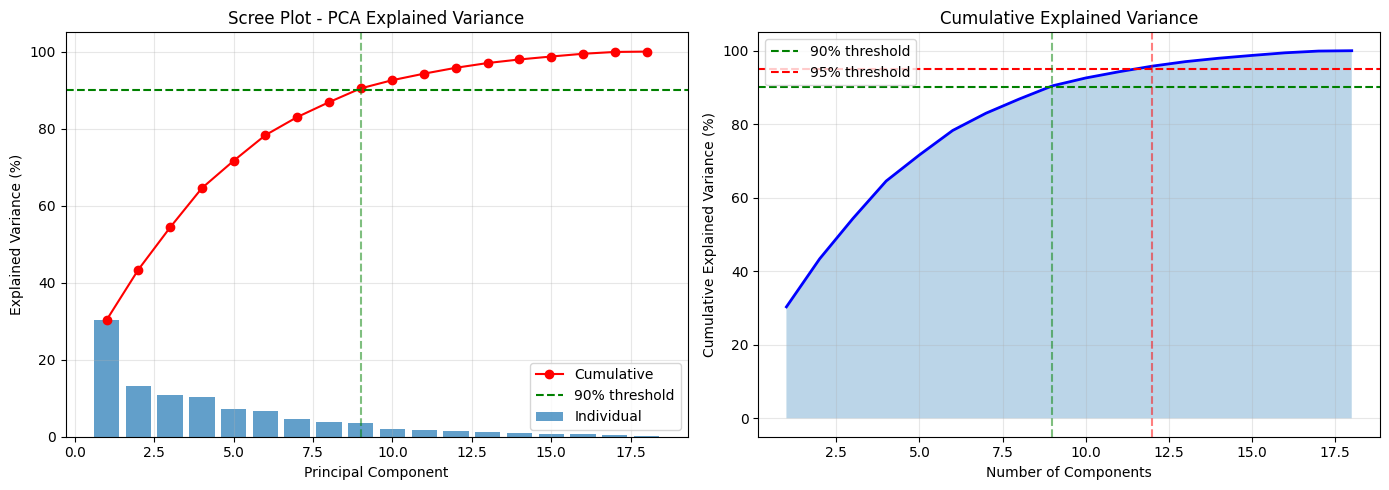


Ket qua PCA:
------------------------------------------------------------
   X_pca_90 (90% variance): (8950, 9) - dung cho Clustering
   X_pca_2d (2 components): (8950, 2) - dung cho Visualization 2D
   X_pca_3d (3 components): (8950, 3) - dung cho Visualization 3D


In [30]:
# ============================================================================
# GIẢM CHIỀU VỚI PCA
# ============================================================================

print("=" * 60)
print("GIẢM CHIỀU VỚI PCA")
print("=" * 60)

print("\nMuc dich PCA:")
print("   1. Truc quan hoa du lieu da chieu (2D/3D)")
print("   2. Giam nhieu, tap trung vao thong tin quan trong")
print("   3. Tang toc do training cho cac mo hinh clustering")

# Phân tích PCA đầy đủ để xem explained variance
pca_full = PCA()
pca_full.fit(X_scaled)

# Tính cumulative explained variance
explained_variance = pca_full.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

# Tìm số components để giữ 90% và 95% variance
n_comp_90 = np.argmax(cumulative_variance >= 0.90) + 1
n_comp_95 = np.argmax(cumulative_variance >= 0.95) + 1

print(f"\nPhan tich Explained Variance:")
print("-" * 60)
print(f"   Tong so features goc: {len(explained_variance)}")
print(f"   So components giu 90% variance: {n_comp_90}")
print(f"   So components giu 95% variance: {n_comp_95}")

# Hiển thị chi tiết từng component
print("\nChi tiet Explained Variance theo Component:")
print("-" * 60)
for i, (ev, cv) in enumerate(zip(explained_variance[:10], cumulative_variance[:10])):
    print(f"   PC{i+1}: {ev*100:6.2f}% | Cumulative: {cv*100:6.2f}%")

# Vẽ biểu đồ Explained Variance
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scree Plot
ax1 = axes[0]
ax1.bar(range(1, len(explained_variance)+1), explained_variance*100, alpha=0.7, label='Individual')
ax1.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 'ro-', label='Cumulative')
ax1.axhline(y=90, color='g', linestyle='--', label='90% threshold')
ax1.axvline(x=n_comp_90, color='g', linestyle='--', alpha=0.5)
ax1.set_xlabel('Principal Component')
ax1.set_ylabel('Explained Variance (%)')
ax1.set_title('Scree Plot - PCA Explained Variance')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. Cumulative Explained Variance
ax2 = axes[1]
ax2.plot(range(1, len(cumulative_variance)+1), cumulative_variance*100, 'b-', linewidth=2)
ax2.fill_between(range(1, len(cumulative_variance)+1), cumulative_variance*100, alpha=0.3)
ax2.axhline(y=90, color='g', linestyle='--', label='90% threshold')
ax2.axhline(y=95, color='r', linestyle='--', label='95% threshold')
ax2.axvline(x=n_comp_90, color='g', linestyle='--', alpha=0.5)
ax2.axvline(x=n_comp_95, color='r', linestyle='--', alpha=0.5)
ax2.set_xlabel('Number of Components')
ax2.set_ylabel('Cumulative Explained Variance (%)')
ax2.set_title('Cumulative Explained Variance')
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Tạo các phiên bản PCA
# PCA cho clustering (giữ 90% variance)
pca_90 = PCA(n_components=n_comp_90)
X_pca_90 = pca_90.fit_transform(X_scaled)

# PCA 2D cho visualization
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)

# PCA 3D cho visualization
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)

print(f"\nKet qua PCA:")
print("-" * 60)
print(f"   X_pca_90 (90% variance): {X_pca_90.shape} - dung cho Clustering")
print(f"   X_pca_2d (2 components): {X_pca_2d.shape} - dung cho Visualization 2D")
print(f"   X_pca_3d (3 components): {X_pca_3d.shape} - dung cho Visualization 3D")

TẠO CÁC PHIÊN BẢN DỮ LIỆU CHO CLUSTERING

[OK] X_full: Du lieu da scale day du - Shape: (8950, 18)
[OK] X_pca_2d: PCA 2D cho truc quan hoa - Shape: (8950, 2)
   Explained variance: 43.40%
[OK] X_pca_3d: PCA 3D cho truc quan hoa - Shape: (8950, 3)
   Explained variance: 54.36%
[OK] X_pca_90: PCA 90% variance cho clustering - Shape: (8950, 9)
   So components: 9
   Explained variance: 90.45%


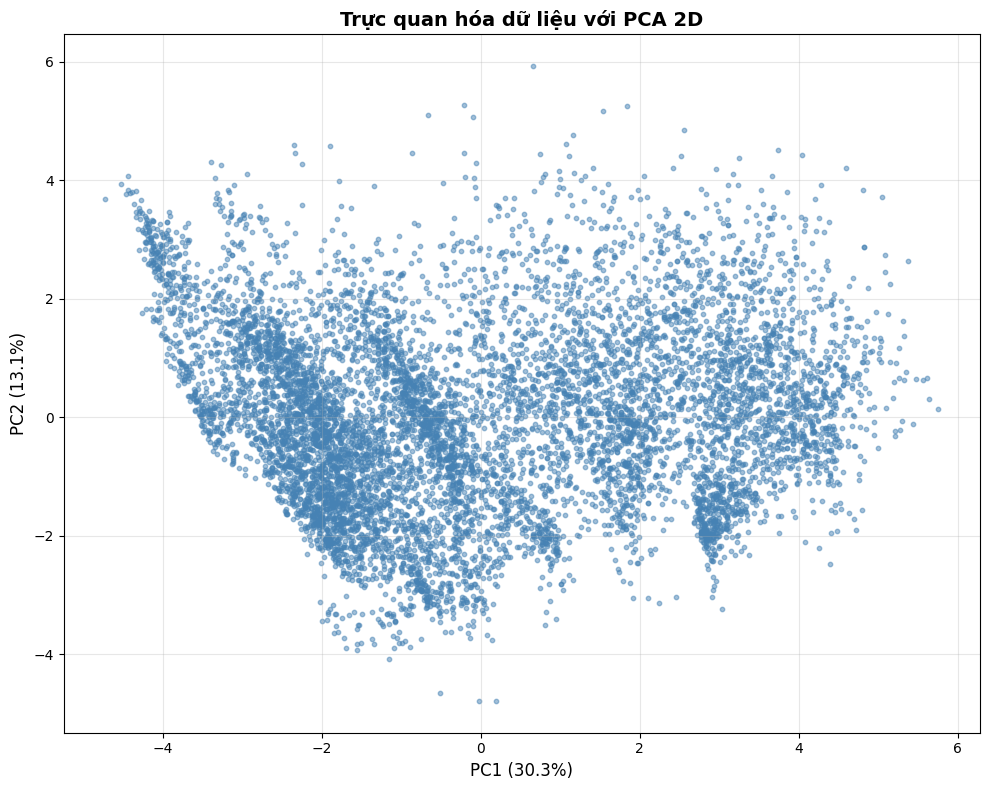


HOAN THANH TIEN XU LY DU LIEU!

[INFO] Du lieu san sang cho Clustering:
   - df_processed: DataFrame da xu ly (truoc scale)
   - X_full: Du lieu da scale day du (8950, 18)
   - X_pca_2d: PCA 2D cho truc quan hoa (8950, 2)
   - X_pca_3d: PCA 3D cho truc quan hoa (8950, 3)
   - X_pca_90: PCA 90% variance cho clustering (8950, 9)
   - feature_names: Danh sach ten features
   - scaler: StandardScaler object (de inverse transform neu can)


In [31]:
# ============================================================================
# TẠO CÁC PHIÊN BẢN DỮ LIỆU CHO CLUSTERING
# ============================================================================

print("=" * 60)
print("TẠO CÁC PHIÊN BẢN DỮ LIỆU CHO CLUSTERING")
print("=" * 60)

# 1. Du lieu da scale day du (cho clustering tren khong gian goc)
X_full = X_scaled.copy()
print(f"\n[OK] X_full: Du lieu da scale day du - Shape: {X_full.shape}")

# 2. PCA giam xuong de truc quan hoa 2D
pca_2d = PCA(n_components=2)
X_pca_2d = pca_2d.fit_transform(X_scaled)
print(f"[OK] X_pca_2d: PCA 2D cho truc quan hoa - Shape: {X_pca_2d.shape}")
print(f"   Explained variance: {pca_2d.explained_variance_ratio_.sum()*100:.2f}%")

# 3. PCA giam xuong de truc quan hoa 3D
pca_3d = PCA(n_components=3)
X_pca_3d = pca_3d.fit_transform(X_scaled)
print(f"[OK] X_pca_3d: PCA 3D cho truc quan hoa - Shape: {X_pca_3d.shape}")
print(f"   Explained variance: {pca_3d.explained_variance_ratio_.sum()*100:.2f}%")

# 4. PCA voi 90% variance (cho clustering)
pca_90 = PCA(n_components=0.90)
X_pca_90 = pca_90.fit_transform(X_scaled)
print(f"[OK] X_pca_90: PCA 90% variance cho clustering - Shape: {X_pca_90.shape}")
print(f"   So components: {pca_90.n_components_}")
print(f"   Explained variance: {pca_90.explained_variance_ratio_.sum()*100:.2f}%")

# Vẽ trực quan hóa 2D PCA
fig, ax = plt.subplots(figsize=(10, 8))
scatter = ax.scatter(X_pca_2d[:, 0], X_pca_2d[:, 1], alpha=0.5, s=10, c='steelblue')
ax.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=12)
ax.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=12)
ax.set_title('Trực quan hóa dữ liệu với PCA 2D', fontsize=14, fontweight='bold')
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n" + "=" * 60)
print("HOAN THANH TIEN XU LY DU LIEU!")
print("=" * 60)
print("\n[INFO] Du lieu san sang cho Clustering:")
print(f"   - df_processed: DataFrame da xu ly (truoc scale)")
print(f"   - X_full: Du lieu da scale day du {X_full.shape}")
print(f"   - X_pca_2d: PCA 2D cho truc quan hoa {X_pca_2d.shape}")
print(f"   - X_pca_3d: PCA 3D cho truc quan hoa {X_pca_3d.shape}")
print(f"   - X_pca_90: PCA 90% variance cho clustering {X_pca_90.shape}")
print(f"   - feature_names: Danh sach ten features")
print(f"   - scaler: StandardScaler object (de inverse transform neu can)")

### **2.7 Tóm tắt Pipeline Tiền Xử Lý**

                    TÓM TẮT PIPELINE TIỀN XỬ LÝ


,Bước,Phương pháp,Lý do
0,1. Drop ID,Loại bỏ CUST_ID,"Định danh, không có ý nghĩa phân cụm"
1,2. Missing Values,Điền Median,Robust với outliers
2,3. Outliers (Winsorize),Clip percentile 1%-99%,"Giữ dữ liệu, giảm extreme values"
3,4. Log Transform,log1p() cho biến amount,Giảm skewness cho K-Means
4,5. Feature Selection,Loại biến đa cộng tuyến,"Giảm redundancy, tăng interpretability"
5,6. Scaling,StandardScaler,K-Means nhạy với scale
6,7. PCA,Giảm chiều,Trực quan + giảm nhiễu


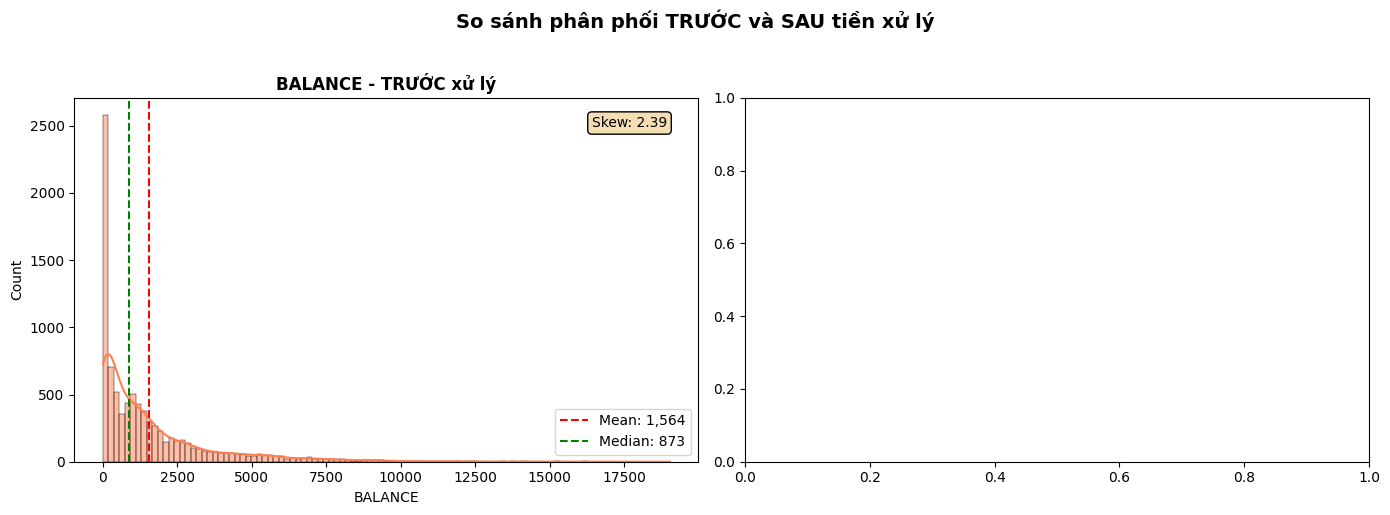

In [32]:
# ============================================================================
# TÓM TẮT PIPELINE TIỀN XỬ LÝ
# ============================================================================

summary_data = {
    'Bước': [
        '1. Drop ID',
        '2. Missing Values',
        '3. Outliers (Winsorize)',
        '4. Log Transform',
        '5. Feature Selection',
        '6. Scaling',
        '7. PCA'
    ],
    'Phương pháp': [
        'Loại bỏ CUST_ID',
        'Điền Median',
        'Clip percentile 1%-99%',
        'log1p() cho biến amount',
        'Loại biến đa cộng tuyến',
        'StandardScaler',
        'Giảm chiều'
    ],
    'Lý do': [
        'Định danh, không có ý nghĩa phân cụm',
        'Robust với outliers',
        'Giữ dữ liệu, giảm extreme values',
        'Giảm skewness cho K-Means',
        'Giảm redundancy, tăng interpretability',
        'K-Means nhạy với scale',
        'Trực quan + giảm nhiễu'
    ]
}

summary_df = pd.DataFrame(summary_data)

print("=" * 80)
print("                    TÓM TẮT PIPELINE TIỀN XỬ LÝ")
print("=" * 80)
display(summary_df)

# Tạo biểu đồ so sánh trước/sau
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Trước xử lý - lấy một biến mẫu từ df gốc (BALANCE)
ax1 = axes[0]
if 'BALANCE' in df.columns:
    sns.histplot(df['BALANCE'], kde=True, ax=ax1, color='coral', edgecolor='black')
    ax1.set_title('BALANCE - TRƯỚC xử lý', fontsize=12, fontweight='bold')
    ax1.axvline(df['BALANCE'].mean(), color='red', linestyle='--', label=f"Mean: {df['BALANCE'].mean():,.0f}")
    ax1.axvline(df['BALANCE'].median(), color='green', linestyle='--', label=f"Median: {df['BALANCE'].median():,.0f}")
    ax1.legend()
    ax1.text(0.95, 0.95, f"Skew: {df['BALANCE'].skew():.2f}", transform=ax1.transAxes,
             ha='right', va='top', bbox=dict(boxstyle='round', facecolor='wheat'))

# Sau xử lý
ax2 = axes[1]
if 'BALANCE' in df_scaled.columns:
    sns.histplot(df_scaled['BALANCE'], kde=True, ax=ax2, color='steelblue', edgecolor='black')
    ax2.set_title('BALANCE - SAU xử lý (Log + Scale)', fontsize=12, fontweight='bold')
    ax2.axvline(df_scaled['BALANCE'].mean(), color='red', linestyle='--', label=f"Mean: {df_scaled['BALANCE'].mean():.2f}")
    ax2.axvline(df_scaled['BALANCE'].median(), color='green', linestyle='--', label=f"Median: {df_scaled['BALANCE'].median():.2f}")
    ax2.legend()
    ax2.text(0.95, 0.95, f"Skew: {df_scaled['BALANCE'].skew():.2f}", transform=ax2.transAxes,
             ha='right', va='top', bbox=dict(boxstyle='round', facecolor='lightblue'))

plt.suptitle('So sánh phân phối TRƯỚC và SAU tiền xử lý', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

## **3. Modeling**

### **3.1 K-Means Clustering**

K-Means là thuật toán clustering phổ biến nhất, hoạt động bằng cách:
1. Khởi tạo k centroid ngẫu nhiên
2. Gán mỗi điểm vào cluster gần nhất
3. Cập nhật centroid = trung bình các điểm trong cluster
4. Lặp lại cho đến khi hội tụ

**Ưu điểm**: Nhanh, đơn giản, hiệu quả với dữ liệu lớn
**Nhược điểm**: Cần chọn k trước, nhạy với outliers và khởi tạo

#### **3.1.1 Xac dinh so cum toi uu (k)**

Su dung 4 phuong phap:
1. **Elbow Method** (Inertia) - Tim diem "khuyu tay"
2. **Silhouette Score** - Do phan tach cac cum (-1 den 1, cang cao cang tot)
3. **Calinski-Harabasz Index** - Ty le phuong sai giua/trong cum (cang cao cang tot)
4. **Davies-Bouldin Index** - Do tuong tu giua cac cum (cang thap cang tot)

In [33]:
# ============================================================================
# TINH TOAN CAC METRICS DE CHON SO CUM TOI UU (Marketing-first)
# - Dung X_full (feature space da scale) de cum phan anh truc tiep bien kinh doanh
# - PCA chi dung de visualization
# ============================================================================

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

print("=" * 70)
print("3.1.1 XAC DINH SO CUM TOI UU CHO K-MEANS")
print("=" * 70)

# Khoang gia tri k can thu
k_range = range(2, 11)

# Luu ket qua
inertias = []
silhouettes = []
calinski_scores = []
davies_bouldin_scores = []

print("\n[INFO] Dang tinh toan cac metrics cho k = 2 den 10 (tren X_full)...")
print("-" * 70)

for k in k_range:
    # Train K-Means tren feature space da scale
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20, max_iter=300, random_state=42)
    labels = kmeans.fit_predict(X_full)
    
    # Tinh cac metrics
    inertia = kmeans.inertia_
    silhouette = silhouette_score(X_full, labels)
    calinski = calinski_harabasz_score(X_full, labels)
    davies = davies_bouldin_score(X_full, labels)
    
    # Luu ket qua
    inertias.append(inertia)
    silhouettes.append(silhouette)
    calinski_scores.append(calinski)
    davies_bouldin_scores.append(davies)
    
    print(f"k={k}: Inertia={inertia:,.0f} | Silhouette={silhouette:.4f} | "
          f"Calinski={calinski:,.0f} | Davies-Bouldin={davies:.4f}")

print("-" * 70)
print("[OK] Hoan thanh tinh toan!")

3.1.1 XAC DINH SO CUM TOI UU CHO K-MEANS

[INFO] Dang tinh toan cac metrics cho k = 2 den 10 (tren X_full)...
----------------------------------------------------------------------
k=2: Inertia=123,028 | Silhouette=0.2410 | Calinski=2,769 | Davies-Bouldin=1.6851
k=3: Inertia=108,266 | Silhouette=0.2422 | Calinski=2,183 | Davies-Bouldin=1.5188
k=4: Inertia=97,291 | Silhouette=0.2336 | Calinski=1,956 | Davies-Bouldin=1.6931
k=5: Inertia=88,377 | Silhouette=0.2249 | Calinski=1,840 | Davies-Bouldin=1.6759
k=6: Inertia=81,325 | Silhouette=0.2147 | Calinski=1,755 | Davies-Bouldin=1.6035
k=7: Inertia=75,519 | Silhouette=0.2136 | Calinski=1,689 | Davies-Bouldin=1.5322
k=8: Inertia=71,132 | Silhouette=0.2084 | Calinski=1,616 | Davies-Bouldin=1.5584
k=9: Inertia=67,206 | Silhouette=0.2182 | Calinski=1,561 | Davies-Bouldin=1.4910
k=10: Inertia=64,854 | Silhouette=0.2195 | Calinski=1,474 | Davies-Bouldin=1.4657
----------------------------------------------------------------------
[OK] Hoan thanh 

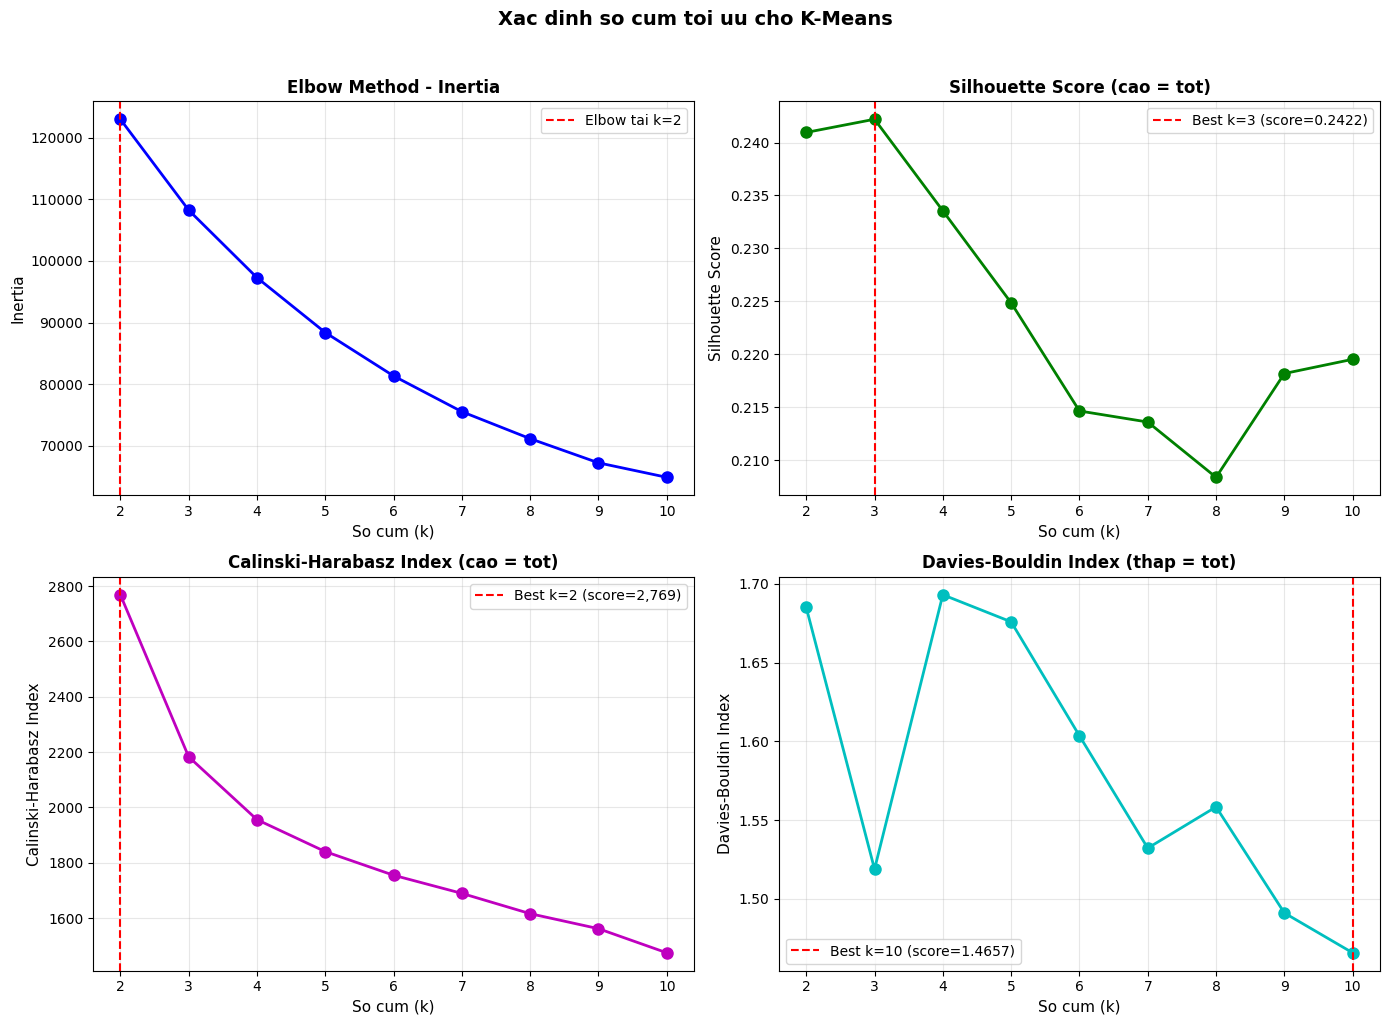

In [34]:
# ============================================================================
# TRUC QUAN HOA CAC METRICS
# ============================================================================

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Elbow Method (Inertia)
ax1 = axes[0, 0]
ax1.plot(k_range, inertias, 'bo-', linewidth=2, markersize=8)
ax1.set_xlabel('So cum (k)', fontsize=11)
ax1.set_ylabel('Inertia', fontsize=11)
ax1.set_title('Elbow Method - Inertia', fontsize=12, fontweight='bold')
ax1.set_xticks(list(k_range))
ax1.grid(True, alpha=0.3)

# Tim diem elbow (su dung phuong phap do goc)
# Tinh do giam inertia
inertia_diff = np.diff(inertias)
inertia_diff2 = np.diff(inertia_diff)
elbow_idx = np.argmax(inertia_diff2) + 2  # +2 vi diff giam 1 index 2 lan
ax1.axvline(x=elbow_idx, color='red', linestyle='--', label=f'Elbow tai k={elbow_idx}')
ax1.legend()

# 2. Silhouette Score
ax2 = axes[0, 1]
ax2.plot(k_range, silhouettes, 'go-', linewidth=2, markersize=8)
ax2.set_xlabel('So cum (k)', fontsize=11)
ax2.set_ylabel('Silhouette Score', fontsize=11)
ax2.set_title('Silhouette Score (cao = tot)', fontsize=12, fontweight='bold')
ax2.set_xticks(list(k_range))
ax2.grid(True, alpha=0.3)

# Danh dau k tot nhat
best_silhouette_k = k_range[np.argmax(silhouettes)]
ax2.axvline(x=best_silhouette_k, color='red', linestyle='--', 
            label=f'Best k={best_silhouette_k} (score={max(silhouettes):.4f})')
ax2.legend()

# 3. Calinski-Harabasz Index
ax3 = axes[1, 0]
ax3.plot(k_range, calinski_scores, 'mo-', linewidth=2, markersize=8)
ax3.set_xlabel('So cum (k)', fontsize=11)
ax3.set_ylabel('Calinski-Harabasz Index', fontsize=11)
ax3.set_title('Calinski-Harabasz Index (cao = tot)', fontsize=12, fontweight='bold')
ax3.set_xticks(list(k_range))
ax3.grid(True, alpha=0.3)

best_calinski_k = k_range[np.argmax(calinski_scores)]
ax3.axvline(x=best_calinski_k, color='red', linestyle='--',
            label=f'Best k={best_calinski_k} (score={max(calinski_scores):,.0f})')
ax3.legend()

# 4. Davies-Bouldin Index
ax4 = axes[1, 1]
ax4.plot(k_range, davies_bouldin_scores, 'co-', linewidth=2, markersize=8)
ax4.set_xlabel('So cum (k)', fontsize=11)
ax4.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax4.set_title('Davies-Bouldin Index (thap = tot)', fontsize=12, fontweight='bold')
ax4.set_xticks(list(k_range))
ax4.grid(True, alpha=0.3)

best_db_k = k_range[np.argmin(davies_bouldin_scores)]
ax4.axvline(x=best_db_k, color='red', linestyle='--',
            label=f'Best k={best_db_k} (score={min(davies_bouldin_scores):.4f})')
ax4.legend()

plt.suptitle('Xac dinh so cum toi uu cho K-Means', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

In [35]:
# ============================================================================
# TONG HOP KET QUA VA QUYET DINH CHON K
# ============================================================================

print("=" * 70)
print("TONG HOP KET QUA CHON SO CUM TOI UU")
print("=" * 70)

# Tao bang tong hop
metrics_df = pd.DataFrame({
    'k': list(k_range),
    'Inertia': inertias,
    'Silhouette': silhouettes,
    'Calinski-Harabasz': calinski_scores,
    'Davies-Bouldin': davies_bouldin_scores
})

display(metrics_df.round(4))

# Tong hop khuyen nghi tu cac phuong phap
print("\n" + "-" * 70)
print("KHUYEN NGHI TU CAC PHUONG PHAP:")
print("-" * 70)
print(f"  [1] Elbow Method:        k = {elbow_idx}")
print(f"  [2] Silhouette Score:    k = {best_silhouette_k} (max = {max(silhouettes):.4f})")
print(f"  [3] Calinski-Harabasz:   k = {best_calinski_k} (max = {max(calinski_scores):,.0f})")
print(f"  [4] Davies-Bouldin:      k = {best_db_k} (min = {min(davies_bouldin_scores):.4f})")

# Dem so vote cho moi k
votes = {}
for k in [elbow_idx, best_silhouette_k, best_calinski_k, best_db_k]:
    votes[k] = votes.get(k, 0) + 1

best_k = max(votes, key=votes.get)
print(f"\n  --> SO CUM DUOC KHUYEN NGHI: k = {best_k} (duoc {votes[best_k]}/4 phuong phap dong y)")

# Phan tich them Silhouette cho cac k gan toi uu
print("\n" + "-" * 70)
print("PHAN TICH CHI TIET SILHOUETTE:")
print("-" * 70)
for k in range(max(2, best_k-1), min(11, best_k+3)):
    idx = k - 2  # vi k_range bat dau tu 2
    if 0 <= idx < len(silhouettes):
        score = silhouettes[idx]
        if score >= 0.5:
            quality = "MANH (cau truc cum ro rang)"
        elif score >= 0.25:
            quality = "TRUNG BINH (cau truc hop ly)"
        else:
            quality = "YEU (cum chong cheo)"
        marker = " <-- CHON" if k == best_k else ""
        print(f"  k={k}: Silhouette = {score:.4f} - {quality}{marker}")

TONG HOP KET QUA CHON SO CUM TOI UU


,k,Inertia,Silhouette,Calinski-Harabasz,Davies-Bouldin
0,2,123027.6725,0.2410,2769.0637,1.6851
1,3,108266.2331,0.2422,2183.0620,1.5188
2,4,97291.1319,0.2336,1955.7605,1.6931
3,5,88376.6914,0.2249,1840.1628,1.6759
4,6,81324.8395,0.2147,1754.7184,1.6035
5,7,75518.9135,0.2136,1689.0949,1.5322
6,8,71131.6010,0.2084,1615.7123,1.5584
7,9,67206.3453,0.2182,1561.4291,1.4910
8,10,64853.6329,0.2195,1474.1614,1.4657



----------------------------------------------------------------------
KHUYEN NGHI TU CAC PHUONG PHAP:
----------------------------------------------------------------------
  [1] Elbow Method:        k = 2
  [2] Silhouette Score:    k = 3 (max = 0.2422)
  [3] Calinski-Harabasz:   k = 2 (max = 2,769)
  [4] Davies-Bouldin:      k = 10 (min = 1.4657)

  --> SO CUM DUOC KHUYEN NGHI: k = 2 (duoc 2/4 phuong phap dong y)

----------------------------------------------------------------------
PHAN TICH CHI TIET SILHOUETTE:
----------------------------------------------------------------------
  k=2: Silhouette = 0.2410 - YEU (cum chong cheo) <-- CHON
  k=3: Silhouette = 0.2422 - YEU (cum chong cheo)
  k=4: Silhouette = 0.2336 - YEU (cum chong cheo)


#### **3.1.2 Silhouette Analysis chi tiet**

Silhouette plot giup truc quan hoa chat luong tung cum:
- **Chieu rong**: So luong mau trong cum
- **Chieu dai**: Silhouette score cua moi mau
- Duong do: Silhouette trung binh

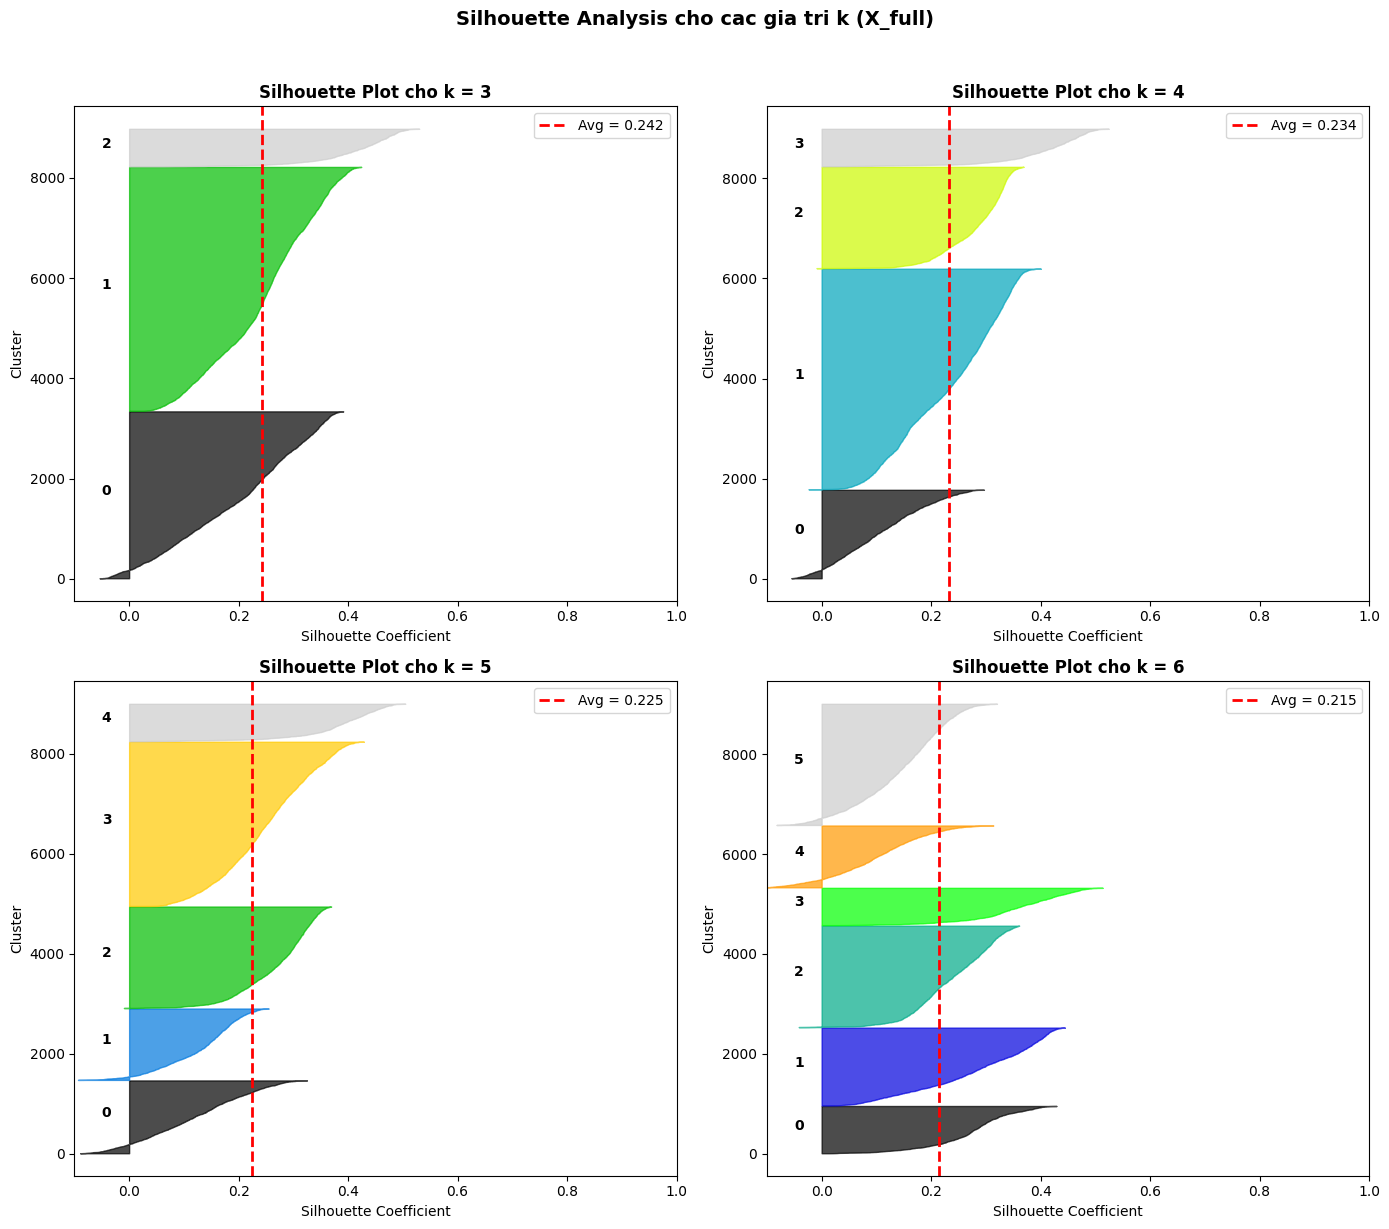


[INFO] Huong dan doc Silhouette Plot:
  - Cum co nhieu mau va score duong cao = chat luong tot
  - Mau co score am (<0) = co the bi gan sai cum


In [36]:
# ============================================================================
# SILHOUETTE ANALYSIS CHI TIET CHO CAC GIA TRI K (tren X_full)
# ============================================================================

from sklearn.metrics import silhouette_samples

# Chon cac gia tri k can phan tich chi tiet
k_values_to_analyze = [3, 4, 5, 6]

fig, axes = plt.subplots(2, 2, figsize=(14, 12))
axes = axes.flatten()

for idx, k in enumerate(k_values_to_analyze):
    ax = axes[idx]
    
    # Train K-Means tren feature space da scale
    kmeans = KMeans(n_clusters=k, init='k-means++', n_init=20, random_state=42)
    cluster_labels = kmeans.fit_predict(X_full)
    
    # Tinh silhouette scores
    silhouette_avg = silhouette_score(X_full, cluster_labels)
    sample_silhouette_values = silhouette_samples(X_full, cluster_labels)
    
    y_lower = 10
    colors_list = plt.cm.nipy_spectral(np.linspace(0, 1, k))
    
    for i in range(k):
        ith_cluster_silhouette_values = sample_silhouette_values[cluster_labels == i]
        ith_cluster_silhouette_values.sort()
        
        size_cluster_i = ith_cluster_silhouette_values.shape[0]
        y_upper = y_lower + size_cluster_i
        
        ax.fill_betweenx(
            np.arange(y_lower, y_upper),
            0, ith_cluster_silhouette_values,
            facecolor=colors_list[i], edgecolor=colors_list[i], alpha=0.7
        )
        
        ax.text(-0.05, y_lower + 0.5 * size_cluster_i, str(i), fontsize=10, fontweight='bold')
        y_lower = y_upper + 10
    
    ax.axvline(x=silhouette_avg, color="red", linestyle="--", linewidth=2, label=f'Avg = {silhouette_avg:.3f}')
    ax.set_title(f'Silhouette Plot cho k = {k}', fontsize=12, fontweight='bold')
    ax.set_xlabel('Silhouette Coefficient', fontsize=10)
    ax.set_ylabel('Cluster', fontsize=10)
    ax.set_xlim([-0.1, 1])
    ax.legend(loc='upper right')

plt.suptitle('Silhouette Analysis cho cac gia tri k (X_full)', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

print("\n[INFO] Huong dan doc Silhouette Plot:")
print("  - Cum co nhieu mau va score duong cao = chat luong tot")
print("  - Mau co score am (<0) = co the bi gan sai cum")

#### **3.1.3 Train K-Means voi k toi uu**

In [37]:
# ============================================================================
# TRAIN K-MEANS VOI K TOI UU (Marketing-first: train tren X_full)
# ============================================================================

from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score

# Chon k toi uu (dua tren phan tich o tren)
# Luu y: metrics co the goi y k nho, nhung k=4 thuong de dat persona marketing de hanh dong
optimal_k = 4  # co the thay doi neu ban muon nhieu/it persona hon

print("=" * 70)
print(f"3.1.3 TRAIN K-MEANS VOI k = {optimal_k}")
print("=" * 70)

kmeans_final = KMeans(
    n_clusters=optimal_k,
    init='k-means++',
    n_init=50,
    max_iter=300,
    random_state=42
)

# Fit va predict tren X_full (feature space da scale)
kmeans_labels = kmeans_final.fit_predict(X_full)

# Them labels vao DataFrame da xu ly
df_processed['Cluster'] = kmeans_labels

print(f"\n[OK] Da train K-Means voi k = {optimal_k} (X_full)")
print(f"\n[INFO] Thong tin mo hinh:")
print(f"   - So cum: {optimal_k}")
print(f"   - So vong lap hoi tu: {kmeans_final.n_iter_}")
print(f"   - Inertia: {kmeans_final.inertia_:,.2f}")

print(f"\n[INFO] Phan phoi mau trong cac cum:")
print("-" * 40)
cluster_counts = pd.Series(kmeans_labels).value_counts().sort_index()
for cluster, count in cluster_counts.items():
    pct = count / len(kmeans_labels) * 100
    print(f"   Cluster {cluster}: {count:,} mau ({pct:.1f}%)")

# Tinh cac metrics tren X_full
final_silhouette = silhouette_score(X_full, kmeans_labels)
final_calinski = calinski_harabasz_score(X_full, kmeans_labels)
final_davies = davies_bouldin_score(X_full, kmeans_labels)

print(f"\n[INFO] Danh gia chat luong clustering (X_full):")
print("-" * 40)
print(f"   Silhouette Score:      {final_silhouette:.4f}")
print(f"   Calinski-Harabasz:     {final_calinski:,.2f}")
print(f"   Davies-Bouldin:        {final_davies:.4f}")

3.1.3 TRAIN K-MEANS VOI k = 4

[OK] Da train K-Means voi k = 4 (X_full)

[INFO] Thong tin mo hinh:
   - So cum: 4
   - So vong lap hoi tu: 22
   - Inertia: 97,291.13

[INFO] Phan phoi mau trong cac cum:
----------------------------------------
   Cluster 0: 1,768 mau (19.8%)
   Cluster 1: 4,407 mau (49.2%)
   Cluster 2: 2,025 mau (22.6%)
   Cluster 3: 750 mau (8.4%)

[INFO] Danh gia chat luong clustering (X_full):
----------------------------------------
   Silhouette Score:      0.2336
   Calinski-Harabasz:     1,955.76
   Davies-Bouldin:        1.6931


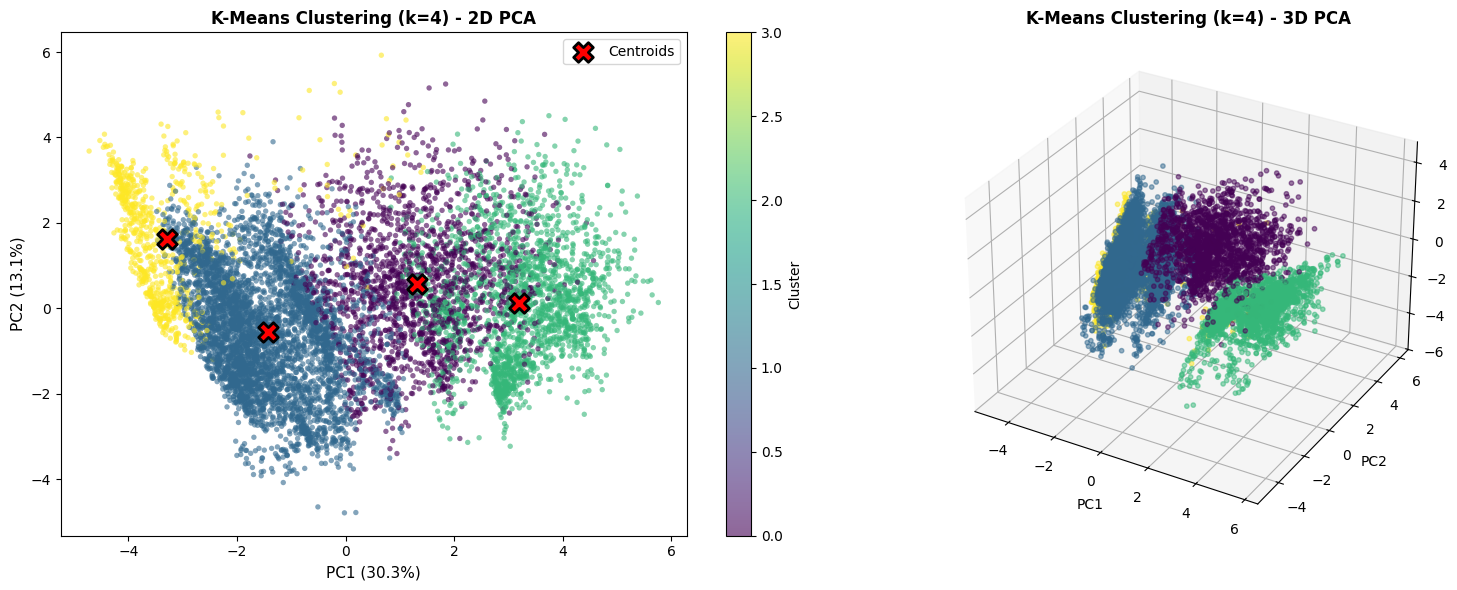


[INFO] Visualization:
   - Mau sac: Cac cum khac nhau
   - Dau X do: Tam cum (centroids) project qua PCA
   - Cum tach biet ro hon = de hanh dong marketing


In [38]:
# ============================================================================
# TRUC QUAN HOA KET QUA CLUSTERING (2D va 3D)
# - Labels lay tu KMeans train tren X_full
# - PCA chi dung de visualize; centroid duoc project qua PCA da fit tren X_scaled
# ============================================================================

fig = plt.figure(figsize=(16, 6))

# 1. Visualization 2D
ax1 = fig.add_subplot(121)
scatter = ax1.scatter(
    X_pca_2d[:, 0], X_pca_2d[:, 1],
    c=kmeans_labels, cmap='viridis', alpha=0.6, s=15, edgecolors='none'
 )

# Ve centroids (project sang 2D PCA)
centroids_2d = pca_2d.transform(kmeans_final.cluster_centers_)
ax1.scatter(
    centroids_2d[:, 0], centroids_2d[:, 1],
    c='red', marker='X', s=200, edgecolors='black', linewidths=2, label='Centroids'
 )

ax1.set_xlabel(f'PC1 ({pca_2d.explained_variance_ratio_[0]*100:.1f}%)', fontsize=11)
ax1.set_ylabel(f'PC2 ({pca_2d.explained_variance_ratio_[1]*100:.1f}%)', fontsize=11)
ax1.set_title(f'K-Means Clustering (k={optimal_k}) - 2D PCA', fontsize=12, fontweight='bold')
ax1.legend()

# Colorbar
cbar = plt.colorbar(scatter, ax=ax1)
cbar.set_label('Cluster', fontsize=10)

# 2. Visualization 3D
ax2 = fig.add_subplot(122, projection='3d')
scatter3d = ax2.scatter(
    X_pca_3d[:, 0], X_pca_3d[:, 1], X_pca_3d[:, 2],
    c=kmeans_labels, cmap='viridis', alpha=0.5, s=10
 )

# (Optional) centroids in 3D
try:
    centroids_3d = pca_3d.transform(kmeans_final.cluster_centers_)
    ax2.scatter(
        centroids_3d[:, 0], centroids_3d[:, 1], centroids_3d[:, 2],
        c='red', marker='X', s=120
    )
except Exception:
    pass

ax2.set_xlabel('PC1', fontsize=10)
ax2.set_ylabel('PC2', fontsize=10)
ax2.set_zlabel('PC3', fontsize=10)
ax2.set_title(f'K-Means Clustering (k={optimal_k}) - 3D PCA', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

print("\n[INFO] Visualization:")
print("   - Mau sac: Cac cum khac nhau")
print("   - Dau X do: Tam cum (centroids) project qua PCA")
print("   - Cum tach biet ro hon = de hanh dong marketing")

#### **3.1.4 Phan tich dac trung tung cum**

In [39]:
# ============================================================================
# PHAN TICH DAC TRUNG TUNG CUM (Marketing-first profiling)
# - Dung du lieu goc (de doc amount that)
# - Bo sung ratios + flags de dat ten cum/ra chien dich de hon
# ============================================================================

print("=" * 70)
print("3.1.4 PHAN TICH DAC TRUNG TUNG CUM")
print("=" * 70)

df_with_clusters = df.copy()
df_with_clusters['Cluster'] = kmeans_labels

EPS = 1e-9

# Ratios (de doc theo nghia kinh doanh)
if 'CREDIT_LIMIT' in df_with_clusters.columns and 'BALANCE' in df_with_clusters.columns:
    df_with_clusters['CREDIT_UTILIZATION'] = np.where(
        df_with_clusters['CREDIT_LIMIT'] > 0,
        df_with_clusters['BALANCE'] / (df_with_clusters['CREDIT_LIMIT'] + EPS),
        0.0
    ).clip(0, 1.5)

if 'CREDIT_LIMIT' in df_with_clusters.columns and 'CASH_ADVANCE' in df_with_clusters.columns:
    df_with_clusters['CASH_RATIO'] = np.where(
        df_with_clusters['CREDIT_LIMIT'] > 0,
        df_with_clusters['CASH_ADVANCE'] / (df_with_clusters['CREDIT_LIMIT'] + EPS),
        0.0
    ).clip(0, 1.5)

if 'MINIMUM_PAYMENTS' in df_with_clusters.columns and 'PAYMENTS' in df_with_clusters.columns:
    df_with_clusters['PAYMENT_RATIO'] = np.where(
        df_with_clusters['MINIMUM_PAYMENTS'] > 0,
        df_with_clusters['PAYMENTS'] / (df_with_clusters['MINIMUM_PAYMENTS'] + EPS),
        np.where(df_with_clusters['PAYMENTS'] > 0, 5.0, 0.0)
    ).clip(0, 10)

if 'PURCHASES_TRX' in df_with_clusters.columns and 'PURCHASES' in df_with_clusters.columns:
    df_with_clusters['PURCHASE_PER_TRX'] = np.where(
        df_with_clusters['PURCHASES_TRX'] > 0,
        df_with_clusters['PURCHASES'] / (df_with_clusters['PURCHASES_TRX'] + EPS),
        0.0
    )

if 'ONEOFF_PURCHASES' in df_with_clusters.columns and 'INSTALLMENTS_PURCHASES' in df_with_clusters.columns:
    denom = df_with_clusters['ONEOFF_PURCHASES'] + df_with_clusters['INSTALLMENTS_PURCHASES'] + EPS
    df_with_clusters['INSTALLMENT_SHARE'] = (df_with_clusters['INSTALLMENTS_PURCHASES'] / denom).clip(0, 1)

# Flags (0/1)
if 'PURCHASES' in df_with_clusters.columns:
    df_with_clusters['HAS_PURCHASE'] = (df_with_clusters['PURCHASES'] > 0).astype(int)
else:
    df_with_clusters['HAS_PURCHASE'] = 0

if 'CASH_ADVANCE' in df_with_clusters.columns:
    df_with_clusters['HAS_CASH_ADV'] = (df_with_clusters['CASH_ADVANCE'] > 0).astype(int)
else:
    df_with_clusters['HAS_CASH_ADV'] = 0

if 'PRC_FULL_PAYMENT' in df_with_clusters.columns:
    df_with_clusters['FULL_PAYER_FLAG'] = (df_with_clusters['PRC_FULL_PAYMENT'] >= 0.8).astype(int)
else:
    df_with_clusters['FULL_PAYER_FLAG'] = 0

# Tinh mean/median
cluster_profile = df_with_clusters.groupby('Cluster').mean(numeric_only=True)
cluster_median = df_with_clusters.groupby('Cluster').median(numeric_only=True)

print("\n[INFO] Gia tri TRUNG BINH cua tung cum (kem ratios/flags):")
display(cluster_profile.round(3))

print("\n[INFO] Gia tri MEDIAN cua tung cum (robust hon voi outliers):")
display(cluster_median.round(3))

3.1.4 PHAN TICH DAC TRUNG TUNG CUM

[INFO] Gia tri TRUNG BINH cua tung cum (kem ratios/flags):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PRC_FULL_PAYMENT,TENURE,CREDIT_UTILIZATION,CASH_RATIO,PAYMENT_RATIO,PURCHASE_PER_TRX,INSTALLMENT_SHARE,HAS_PURCHASE,HAS_CASH_ADV,FULL_PAYER_FLAG
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2944.574,0.960,1024.835,613.887,411.198,2480.833,0.550,0.248,0.378,0.331,...,0.034,11.388,0.640,0.530,2.670,91.097,0.403,0.999,1.000,0.001
1,963.681,0.847,1269.418,744.956,524.829,54.723,0.643,0.253,0.489,0.014,...,0.121,11.672,0.259,0.011,3.990,99.510,0.532,1.000,0.105,0.000
2,2171.056,0.889,0.044,0.044,0.000,2001.146,0.000,0.000,0.000,0.274,...,0.033,11.329,0.572,0.512,2.725,0.044,0.000,0.003,1.000,0.002
3,203.618,0.830,2096.483,1245.139,852.184,108.396,0.777,0.344,0.586,0.013,...,0.953,11.424,0.045,0.028,6.803,81.941,0.608,0.969,0.088,1.000



[INFO] Gia tri MEDIAN cua tung cum (robust hon voi outliers):


,BALANCE,BALANCE_FREQUENCY,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,CASH_ADVANCE,PURCHASES_FREQUENCY,ONEOFF_PURCHASES_FREQUENCY,PURCHASES_INSTALLMENTS_FREQUENCY,CASH_ADVANCE_FREQUENCY,...,PRC_FULL_PAYMENT,TENURE,CREDIT_UTILIZATION,CASH_RATIO,PAYMENT_RATIO,PURCHASE_PER_TRX,INSTALLMENT_SHARE,HAS_PURCHASE,HAS_CASH_ADV,FULL_PAYER_FLAG
Cluster,,,,,,,,,,,,,,,,,,,,,
0,2066.956,1.0,520.660,227.885,132.580,1644.935,0.545,0.167,0.250,0.25,...,0.0,12.0,0.679,0.454,1.155,56.784,0.273,1.0,1.0,0.0
1,344.288,1.0,584.260,172.000,235.000,0.000,0.727,0.083,0.500,0.00,...,0.0,12.0,0.107,0.000,2.724,53.742,0.546,1.0,0.0,0.0
2,1472.378,1.0,0.000,0.000,0.000,1224.607,0.000,0.000,0.000,0.25,...,0.0,12.0,0.609,0.428,1.112,0.000,0.000,0.0,1.0,0.0
3,91.131,1.0,927.815,100.000,446.915,0.000,0.917,0.083,0.667,0.00,...,1.0,12.0,0.024,0.000,7.738,60.512,0.775,1.0,0.0,1.0


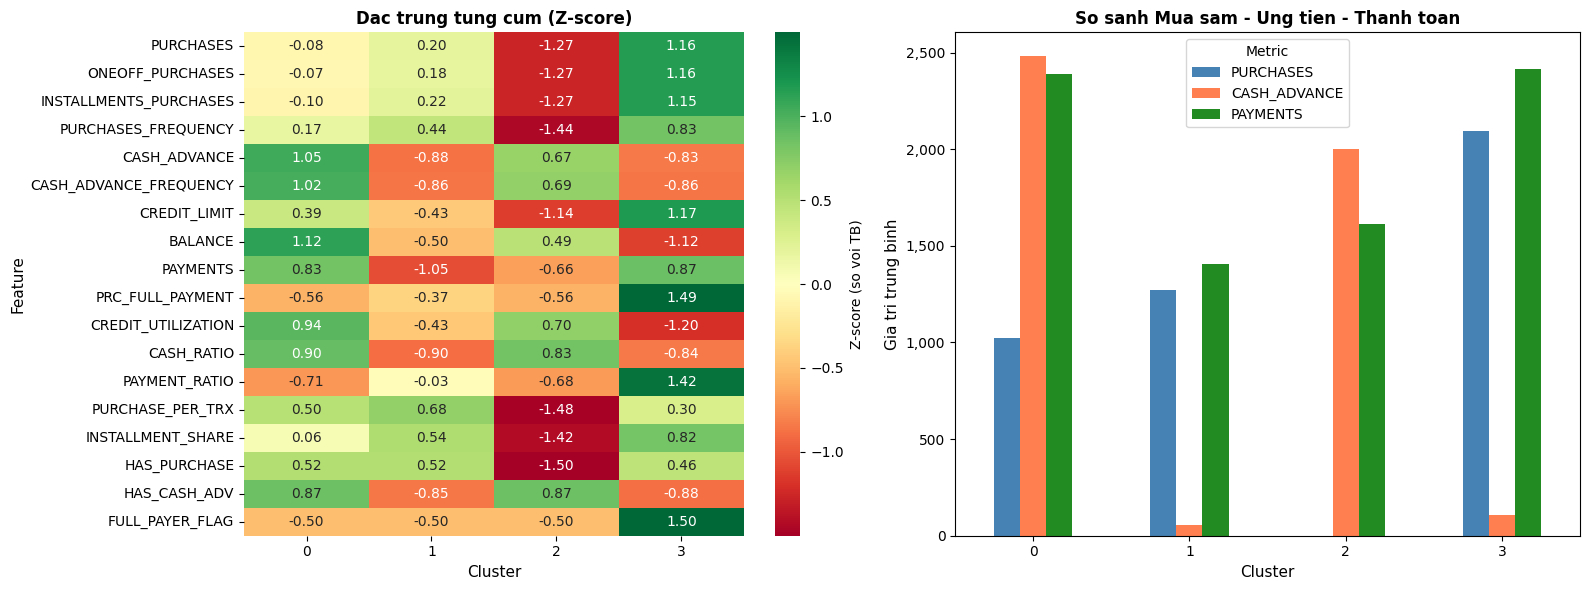

In [40]:
# ============================================================================
# TRUC QUAN HOA DAC TRUNG TUNG CUM (Marketing-first)
# ============================================================================

import numpy as np

# Chon cac bien quan trong de phan tich
key_features = [
    'PURCHASES', 'ONEOFF_PURCHASES', 'INSTALLMENTS_PURCHASES', 'PURCHASES_FREQUENCY',
    'CASH_ADVANCE', 'CASH_ADVANCE_FREQUENCY',
    'CREDIT_LIMIT', 'BALANCE', 'PAYMENTS', 'PRC_FULL_PAYMENT',
    # ratios + flags (neu co)
    'CREDIT_UTILIZATION', 'CASH_RATIO', 'PAYMENT_RATIO', 'PURCHASE_PER_TRX',
    'INSTALLMENT_SHARE', 'HAS_PURCHASE', 'HAS_CASH_ADV', 'FULL_PAYER_FLAG'
 ]

# Chi lay cac bien co trong df
key_features = [f for f in key_features if f in df_with_clusters.columns]

# Tinh gia tri trung binh cho moi cluster (chuan hoa de so sanh)
cluster_means = df_with_clusters.groupby('Cluster')[key_features].mean()

# Chuan hoa theo z-score de so sanh tren cung thang do
cluster_means_normalized = (cluster_means - cluster_means.mean()) / (cluster_means.std() + 1e-9)

# Ve heatmap + bar chart
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# 1. Heatmap
ax1 = axes[0]
sns.heatmap(
    cluster_means_normalized.T, annot=True, fmt='.2f', cmap='RdYlGn',
    center=0, ax=ax1, cbar_kws={'label': 'Z-score (so voi TB)'}
 )
ax1.set_title('Dac trung tung cum (Z-score)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Cluster', fontsize=11)
ax1.set_ylabel('Feature', fontsize=11)

# 2. Bar chart so sanh (neu co)
ax2 = axes[1]
bar_cols = [c for c in ['PURCHASES', 'CASH_ADVANCE', 'PAYMENTS'] if c in cluster_means.columns]
if bar_cols:
    cluster_means[bar_cols].plot(kind='bar', ax=ax2, color=['steelblue','coral','forestgreen'][:len(bar_cols)])
    ax2.set_title('So sanh Mua sam - Ung tien - Thanh toan', fontsize=12, fontweight='bold')
    ax2.set_xlabel('Cluster', fontsize=11)
    ax2.set_ylabel('Gia tri trung binh', fontsize=11)
    ax2.legend(title='Metric')
    ax2.set_xticklabels(ax2.get_xticklabels(), rotation=0)
    ax2.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: format(int(x), ',')))
else:
    ax2.axis('off')
    ax2.text(0.5, 0.5, 'Khong du cot PURCHASES/CASH_ADVANCE/PAYMENTS de ve bar chart', ha='center', va='center')

plt.tight_layout()
plt.show()

In [41]:
print("=" * 70)
print("MO TA DAC TRUNG TUNG CUM")
print("=" * 70)

for cluster in range(optimal_k):
    cluster_data = df_with_clusters[df_with_clusters['Cluster'] == cluster]
    n_customers = len(cluster_data)
    pct = n_customers / len(df_with_clusters) * 100
    
    avg_balance = cluster_data['BALANCE'].mean()
    avg_purchases = cluster_data['PURCHASES'].mean()
    avg_cash_advance = cluster_data['CASH_ADVANCE'].mean()
    avg_payments = cluster_data['PAYMENTS'].mean()
    avg_credit_limit = cluster_data['CREDIT_LIMIT'].mean()
    avg_prc_full = cluster_data['PRC_FULL_PAYMENT'].mean()
    avg_purchases_freq = cluster_data['PURCHASES_FREQUENCY'].mean()
    avg_cash_freq = cluster_data['CASH_ADVANCE_FREQUENCY'].mean()
    
    print(f"\n{'='*60}")
    print(f"CLUSTER {cluster}: {n_customers:,} khach hang ({pct:.1f}%)")
    print(f"{'='*60}")
    print(f"  So du TB:           ${avg_balance:>10,.0f}")
    print(f"  Mua sam TB:         ${avg_purchases:>10,.0f}")
    print(f"  Ung tien mat TB:    ${avg_cash_advance:>10,.0f}")
    print(f"  Thanh toan TB:      ${avg_payments:>10,.0f}")
    print(f"  Han muc tin dung:   ${avg_credit_limit:>10,.0f}")
    print(f"  Ty le thanh toan day du: {avg_prc_full*100:>6.1f}%")
    print(f"  Tan suat mua sam:   {avg_purchases_freq:>10.2f}")
    print(f"  Tan suat ung tien:  {avg_cash_freq:>10.2f}")
    
    if avg_purchases > cluster_means['PURCHASES'].mean() and avg_cash_advance < cluster_means['CASH_ADVANCE'].mean():
        profile = "KHACH HANG MUA SAM TICH CUC"
    elif avg_cash_advance > cluster_means['CASH_ADVANCE'].mean() and avg_purchases < cluster_means['PURCHASES'].mean():
        profile = "KHACH HANG UNG TIEN MAT (RUI RO)"
    elif avg_balance < cluster_means['BALANCE'].mean() and avg_purchases < cluster_means['PURCHASES'].mean():
        profile = "KHACH HANG IT HOAT DONG"
    elif avg_prc_full > 0.3:
        profile = "KHACH HANG THANH TOAN TOT"
    else:
        profile = "KHACH HANG TRUNG BINH"
    
    print(f"\n  --> NHAN DIEN: {profile}")

MO TA DAC TRUNG TUNG CUM

CLUSTER 0: 1,768 khach hang (19.8%)
  So du TB:           $     2,945
  Mua sam TB:         $     1,025
  Ung tien mat TB:    $     2,481
  Thanh toan TB:      $     2,392
  Han muc tin dung:   $     4,866
  Ty le thanh toan day du:    3.4%
  Tan suat mua sam:         0.55
  Tan suat ung tien:        0.33

  --> NHAN DIEN: KHACH HANG UNG TIEN MAT (RUI RO)

CLUSTER 1: 4,407 khach hang (49.2%)
  So du TB:           $       964
  Mua sam TB:         $     1,269
  Ung tien mat TB:    $        55
  Thanh toan TB:      $     1,408
  Han muc tin dung:   $     4,421
  Ty le thanh toan day du:   12.1%
  Tan suat mua sam:         0.64
  Tan suat ung tien:        0.01

  --> NHAN DIEN: KHACH HANG MUA SAM TICH CUC

CLUSTER 2: 2,025 khach hang (22.6%)
  So du TB:           $     2,171
  Mua sam TB:         $         0
  Ung tien mat TB:    $     2,001
  Thanh toan TB:      $     1,614
  Han muc tin dung:   $     4,036
  Ty le thanh toan day du:    3.3%
  Tan suat mua sam: 

In [42]:
print("=" * 70)
print("TONG KET K-MEANS CLUSTERING (Marketing segmentation)")
print("=" * 70)

# AUTO NAMING: tranh hard-code cluster id (0/1/2/3) bi lech khi rerun
profile_cols = [
    'PURCHASES','PURCHASES_FREQUENCY','CASH_ADVANCE','CASH_ADVANCE_FREQUENCY',
    'PRC_FULL_PAYMENT','CREDIT_UTILIZATION','CASH_RATIO','INSTALLMENT_SHARE','HAS_PURCHASE','HAS_CASH_ADV'
 ]
profile_cols = [c for c in profile_cols if c in df_with_clusters.columns]
cluster_profile_small = df_with_clusters.groupby('Cluster')[profile_cols].mean() if profile_cols else None

cluster_names = {}
if cluster_profile_small is not None and len(profile_cols) > 0:
    # quantile thresholds de dat ten tuong doi (robust hon)
    q75 = cluster_profile_small.quantile(0.75)
    q25 = cluster_profile_small.quantile(0.25)
    
    for c in sorted(cluster_profile_small.index):
        row = cluster_profile_small.loc[c]
        cash_heavy = False
        if 'CASH_RATIO' in row.index:
            cash_heavy = row['CASH_RATIO'] >= q75.get('CASH_RATIO', row['CASH_RATIO'])
        elif 'CASH_ADVANCE' in row.index:
            cash_heavy = row['CASH_ADVANCE'] >= q75.get('CASH_ADVANCE', row['CASH_ADVANCE'])
        
        high_spend = row.get('PURCHASES', 0) >= q75.get('PURCHASES', row.get('PURCHASES', 0))
        full_payer = row.get('PRC_FULL_PAYMENT', 0) >= q75.get('PRC_FULL_PAYMENT', row.get('PRC_FULL_PAYMENT', 0))
        low_activity = (row.get('HAS_PURCHASE', 1) <= q25.get('HAS_PURCHASE', row.get('HAS_PURCHASE', 1))) or (row.get('PURCHASES', 0) <= q25.get('PURCHASES', row.get('PURCHASES', 0)))
        installment_oriented = row.get('INSTALLMENT_SHARE', 0) >= q75.get('INSTALLMENT_SHARE', row.get('INSTALLMENT_SHARE', 0))
        high_util = row.get('CREDIT_UTILIZATION', 0) >= q75.get('CREDIT_UTILIZATION', row.get('CREDIT_UTILIZATION', 0))
        
        if cash_heavy:
            cluster_names[c] = "Cash-Advance Heavy (Need control)"
        elif low_activity:
            cluster_names[c] = "Low Activity (Activation)"
        elif high_spend and full_payer:
            cluster_names[c] = "High Spend + Full Payer (VIP/Rewards)"
        elif installment_oriented:
            cluster_names[c] = "Installment Oriented (Merchant/BNPL)"
        elif high_util and not full_payer:
            cluster_names[c] = "High Utilization Revolver (Balance mgmt)"
        else:
            cluster_names[c] = "Regular Users (Maintain)"
else:
    # fallback
    for c in range(optimal_k):
        cluster_names[c] = f"Cluster {c}"

print("\nPHAN LOAI CUOI CUNG (Auto-naming):")
print("-" * 70)
for cluster in sorted(pd.Series(kmeans_labels).unique()):
    name = cluster_names.get(cluster, f"Cluster {cluster}")
    count = (kmeans_labels == cluster).sum()
    pct = count / len(kmeans_labels) * 100
    print(f"  Cluster {cluster}: {name:<38} - {count:,} KH ({pct:.1f}%)")

print("\nDANH GIA CHAT LUONG (X_full):")
print("-" * 70)
print(f"  Silhouette Score:      {final_silhouette:.4f}")
print(f"  Calinski-Harabasz:     {final_calinski:,.2f}")
print(f"  Davies-Bouldin:        {final_davies:.4f}")

TONG KET K-MEANS CLUSTERING (Marketing segmentation)

PHAN LOAI CUOI CUNG (Auto-naming):
----------------------------------------------------------------------
  Cluster 0: Cash-Advance Heavy (Need control)      - 1,768 KH (19.8%)
  Cluster 1: Regular Users (Maintain)               - 4,407 KH (49.2%)
  Cluster 2: Low Activity (Activation)              - 2,025 KH (22.6%)
  Cluster 3: High Spend + Full Payer (VIP/Rewards)  - 750 KH (8.4%)

DANH GIA CHAT LUONG (X_full):
----------------------------------------------------------------------
  Silhouette Score:      0.2336
  Calinski-Harabasz:     1,955.76
  Davies-Bouldin:        1.6931


#### **3.1.5 STAGE-2 SEGMENTATION - REGULAR USERS (SCORECARD)**
- Tách Regular -> tính Value/Risk/Engagement score (z-score trong subset)

- Chia theo quantile -> 4 sub-persona (High/Low Value x High/Low Risk)

### **3.2 Hierarchical Clustering (Phân cụm phân cấp)**

Hierarchical Clustering là phương pháp phân cụm tạo ra cây phân cấp (dendrogram) thể hiện mối quan hệ giữa các điểm dữ liệu.

**Có 2 phương pháp chính:**
1. **Agglomerative (Bottom-up)**: Bắt đầu từ mỗi điểm là 1 cụm, sau đó gộp dần
2. **Divisive (Top-down)**: Bắt đầu từ 1 cụm lớn, sau đó chia nhỏ dần

**Các phương pháp tính khoảng cách giữa cụm (Linkage):**
- **Ward**: Tối thiểu hóa tổng phương sai trong cụm (thường cho kết quả tốt nhất)
- **Complete**: Khoảng cách lớn nhất giữa các điểm
- **Average**: Khoảng cách trung bình giữa các điểm
- **Single**: Khoảng cách nhỏ nhất giữa các điểm

**Ưu điểm**: Không cần chọn k trước, trực quan qua dendrogram, phát hiện cấu trúc phân cấp
**Nhược điểm**: Chậm với dữ liệu lớn O(n²), khó thay đổi khi đã gộp/chia

#### **3.2.1 Vẽ Dendrogram để xác định số cụm**

3.2.1 HIERARCHICAL CLUSTERING - DENDROGRAM

[INFO] Sử dụng 2000 mẫu để vẽ dendrogram
[INFO] Đang tính toán linkage matrix với phương pháp Ward...
[OK] Hoàn thành tính toán linkage!


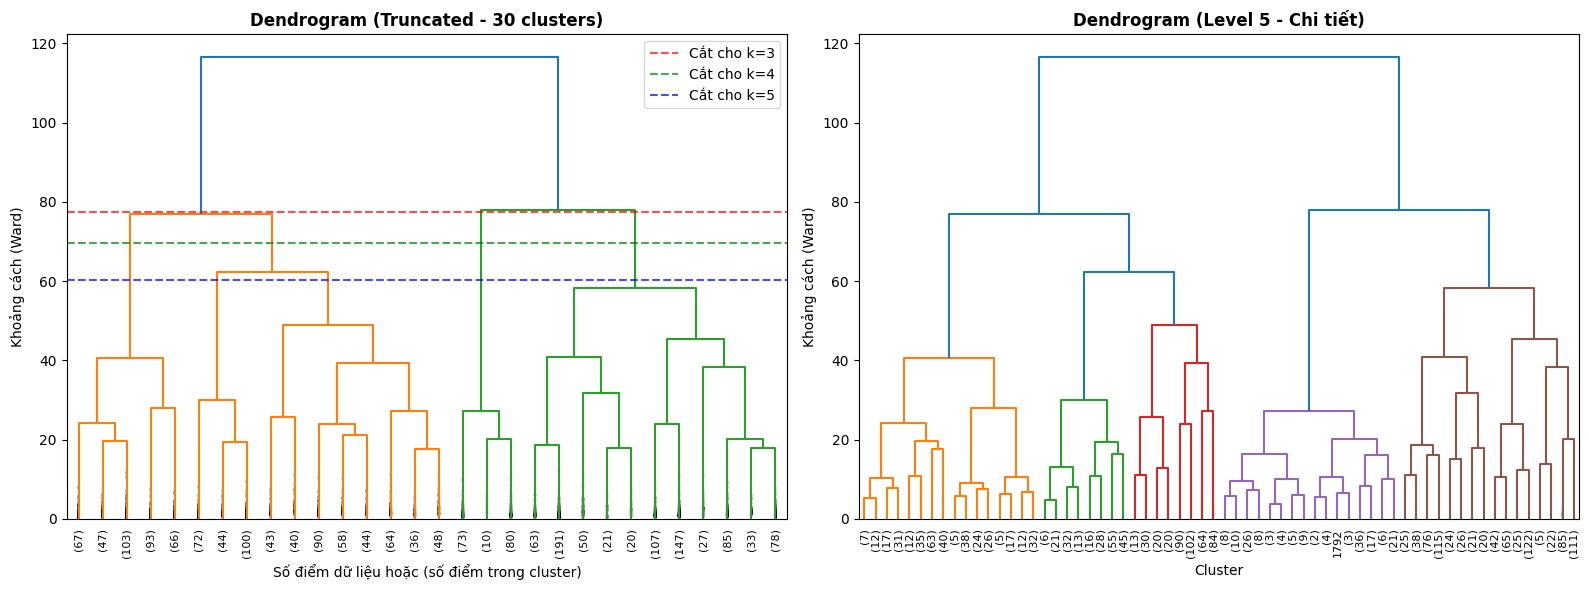


[INFO] Hướng dẫn đọc Dendrogram:
  - Trục Y: Khoảng cách Ward (càng cao = các cụm càng khác biệt)
  - Cắt ngang ở độ cao nhất định sẽ cho số cụm tương ứng
  - Chọn vị trí cắt sao cho các nhánh có chiều cao ĐỒNG ĐỀU


In [45]:
# ============================================================================
# VẼ DENDROGRAM ĐỂ XÁC ĐỊNH SỐ CỤM TỐI ƯU (train/eval space: X_full)
# ============================================================================

from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.cluster import AgglomerativeClustering

print("=" * 70)
print("3.2.1 HIERARCHICAL CLUSTERING - DENDROGRAM")
print("=" * 70)

# Do dữ liệu lớn, lấy mẫu để vẽ dendrogram (nếu cần)
n_samples = min(2000, len(X_full))
np.random.seed(42)
sample_indices = np.random.choice(len(X_full), n_samples, replace=False)
X_sample = X_full[sample_indices]

print(f"\n[INFO] Sử dụng {n_samples} mẫu để vẽ dendrogram")
print("[INFO] Đang tính toán linkage matrix với phương pháp Ward...")

# Tính linkage matrix với phương pháp Ward
linkage_matrix = linkage(X_sample, method='ward')

print("[OK] Hoàn thành tính toán linkage!")

# Vẽ dendrogram
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Dendrogram đầy đủ
ax1 = axes[0]
dendrogram(linkage_matrix, ax=ax1, truncate_mode='lastp', p=30, 
           leaf_rotation=90, leaf_font_size=8, show_contracted=True)
ax1.set_title('Dendrogram (Truncated - 30 clusters)', fontsize=12, fontweight='bold')
ax1.set_xlabel('Số điểm dữ liệu hoặc (số điểm trong cluster)', fontsize=10)
ax1.set_ylabel('Khoảng cách (Ward)', fontsize=10)

# Thêm đường cắt gợi ý cho k=3, 4, 5
colors = ['red', 'green', 'blue']
k_suggestions = [3, 4, 5]
# Tìm các mức cắt phù hợp
sorted_distances = sorted(linkage_matrix[:, 2], reverse=True)

for i, k in enumerate(k_suggestions):
    if k-1 < len(sorted_distances):
        cut_distance = (sorted_distances[k-2] + sorted_distances[k-1]) / 2 if k > 1 else sorted_distances[0]
        ax1.axhline(y=cut_distance, color=colors[i], linestyle='--', 
                   label=f'Cắt cho k={k}', alpha=0.7)

ax1.legend(loc='upper right')

# Dendrogram đơn giản hơn
ax2 = axes[1]
dendrogram(linkage_matrix, ax=ax2, truncate_mode='level', p=5,
           leaf_rotation=90, leaf_font_size=8, show_contracted=True,
           color_threshold=sorted_distances[3] if len(sorted_distances) > 3 else 0)
ax2.set_title('Dendrogram (Level 5 - Chi tiết)', fontsize=12, fontweight='bold')
ax2.set_xlabel('Cluster', fontsize=10)
ax2.set_ylabel('Khoảng cách (Ward)', fontsize=10)

plt.tight_layout()
plt.show()

print("\n[INFO] Hướng dẫn đọc Dendrogram:")
print("  - Trục Y: Khoảng cách Ward (càng cao = các cụm càng khác biệt)")
print("  - Cắt ngang ở độ cao nhất định sẽ cho số cụm tương ứng")
print("  - Chọn vị trí cắt sao cho các nhánh có chiều cao ĐỒNG ĐỀU")

#### **3.2.2 So sánh các phương pháp Linkage**

3.2.2 SO SÁNH CÁC PHƯƠNG PHÁP LINKAGE

[INFO] Đang so sánh các phương pháp linkage...

  Đang tính: WARD

  Đang tính: COMPLETE

  Đang tính: AVERAGE

  Đang tính: SINGLE

[OK] Hoàn thành so sánh!


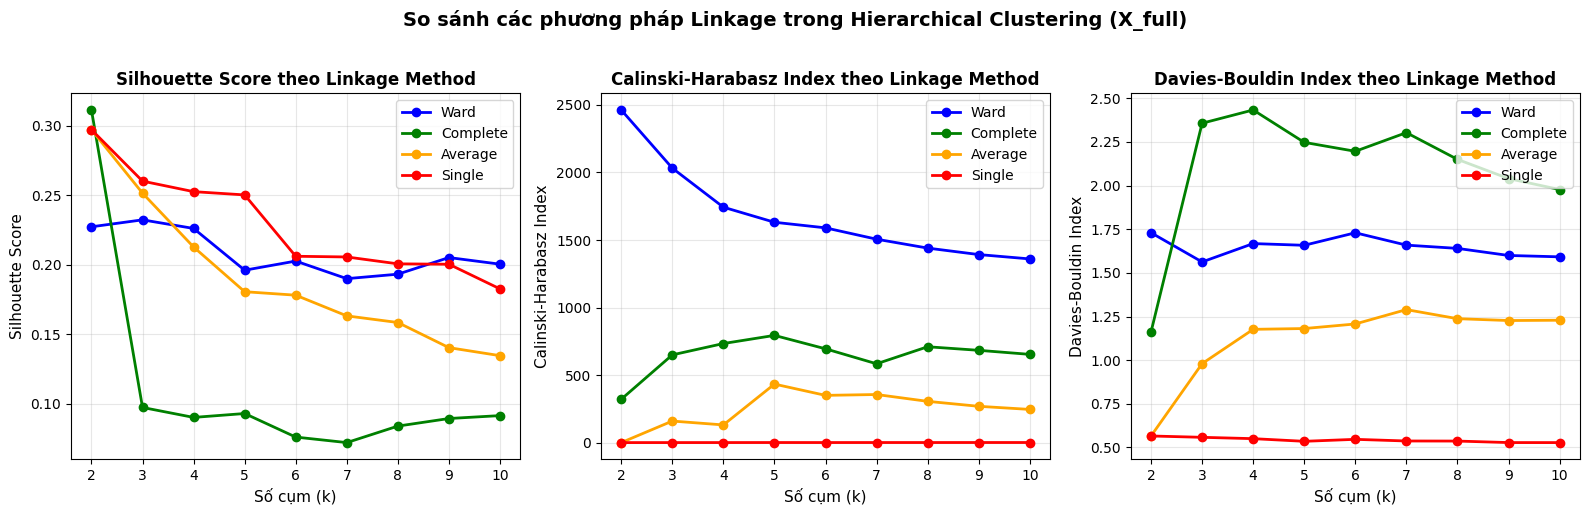


BẢNG SO SÁNH CHI TIẾT (k=4)

Linkage      |   Silhouette |  Calinski-Harabasz | Davies-Bouldin
----------------------------------------------------------------------
Ward         |       0.2261 |           1,742.58 |         1.6679
Complete     |       0.0902 |             734.98 |         2.4333
Average      |       0.2128 |             133.53 |         1.1767
Single       |       0.2526 |               3.16 |         0.5504


In [46]:
# ============================================================================
# SO SÁNH CÁC PHƯƠNG PHÁP LINKAGE (tren X_full de so sanh cong bang voi K-Means)
# ============================================================================

print("=" * 70)
print("3.2.2 SO SÁNH CÁC PHƯƠNG PHÁP LINKAGE")
print("=" * 70)

linkage_methods = ['ward', 'complete', 'average', 'single']
k_range_hier = range(2, 11)

# Lưu kết quả
hier_results = {method: {'silhouette': [], 'calinski': [], 'davies': []} for method in linkage_methods}

print("\n[INFO] Đang so sánh các phương pháp linkage...")

for method in linkage_methods:
    print(f"\n  Đang tính: {method.upper()}")
    
    for k in k_range_hier:
        # Train Agglomerative Clustering
        agg_clustering = AgglomerativeClustering(n_clusters=k, linkage=method)
        labels = agg_clustering.fit_predict(X_full)
        
        # Tính metrics (tren X_full)
        sil = silhouette_score(X_full, labels)
        cal = calinski_harabasz_score(X_full, labels)
        dav = davies_bouldin_score(X_full, labels)
        
        hier_results[method]['silhouette'].append(sil)
        hier_results[method]['calinski'].append(cal)
        hier_results[method]['davies'].append(dav)

print("\n[OK] Hoàn thành so sánh!")

# Vẽ biểu đồ so sánh
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

colors_linkage = {'ward': 'blue', 'complete': 'green', 'average': 'orange', 'single': 'red'}

# Silhouette Score
ax1 = axes[0]
for method in linkage_methods:
    ax1.plot(k_range_hier, hier_results[method]['silhouette'], 
             'o-', label=method.capitalize(), color=colors_linkage[method], linewidth=2)
ax1.set_xlabel('Số cụm (k)', fontsize=11)
ax1.set_ylabel('Silhouette Score', fontsize=11)
ax1.set_title('Silhouette Score theo Linkage Method', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# Calinski-Harabasz Index
ax2 = axes[1]
for method in linkage_methods:
    ax2.plot(k_range_hier, hier_results[method]['calinski'], 
             'o-', label=method.capitalize(), color=colors_linkage[method], linewidth=2)
ax2.set_xlabel('Số cụm (k)', fontsize=11)
ax2.set_ylabel('Calinski-Harabasz Index', fontsize=11)
ax2.set_title('Calinski-Harabasz Index theo Linkage Method', fontsize=12, fontweight='bold')
ax2.legend()
ax2.grid(True, alpha=0.3)

# Davies-Bouldin Index
ax3 = axes[2]
for method in linkage_methods:
    ax3.plot(k_range_hier, hier_results[method]['davies'], 
             'o-', label=method.capitalize(), color=colors_linkage[method], linewidth=2)
ax3.set_xlabel('Số cụm (k)', fontsize=11)
ax3.set_ylabel('Davies-Bouldin Index', fontsize=11)
ax3.set_title('Davies-Bouldin Index theo Linkage Method', fontsize=12, fontweight='bold')
ax3.legend()
ax3.grid(True, alpha=0.3)

plt.suptitle('So sánh các phương pháp Linkage trong Hierarchical Clustering (X_full)', 
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

# Tìm phương pháp và k tốt nhất
print("\n" + "=" * 70)
print("BẢNG SO SÁNH CHI TIẾT (k=4)")
print("=" * 70)
print(f"\n{'Linkage':<12} | {'Silhouette':>12} | {'Calinski-Harabasz':>18} | {'Davies-Bouldin':>14}")
print("-" * 70)

for method in linkage_methods:
    idx = 2  # k=4 (index 2 trong range 2-10)
    sil = hier_results[method]['silhouette'][idx]
    cal = hier_results[method]['calinski'][idx]
    dav = hier_results[method]['davies'][idx]
    print(f"{method.capitalize():<12} | {sil:>12.4f} | {cal:>18,.2f} | {dav:>14.4f}")

#### **3.2.3 Train Hierarchical Clustering với k=4 (Ward linkage)**

In [47]:
# ============================================================================
# TRAIN HIERARCHICAL CLUSTERING VỚI K TỐI ƯU (train/eval tren X_full)
# ============================================================================

print("=" * 70)
print("3.2.3 TRAIN HIERARCHICAL CLUSTERING (WARD, k=4)")
print("=" * 70)

# Sử dụng cùng k với K-Means để so sánh
hier_k = 4
hier_linkage = 'ward'

print(f"\n[INFO] Cấu hình:")
print(f"  - Số cụm: k = {hier_k}")
print(f"  - Phương pháp linkage: {hier_linkage}")
print("  - Input space: X_full (scaled features)")

# Train model
hier_model = AgglomerativeClustering(n_clusters=hier_k, linkage=hier_linkage)
hier_labels = hier_model.fit_predict(X_full)

# Tính metrics (tren X_full)
hier_silhouette = silhouette_score(X_full, hier_labels)
hier_calinski = calinski_harabasz_score(X_full, hier_labels)
hier_davies = davies_bouldin_score(X_full, hier_labels)

print("\n[OK] Hoàn thành training!")
print("\n" + "-" * 70)
print("ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM:")
print("-" * 70)
print(f"  Silhouette Score:      {hier_silhouette:.4f}")
print(f"  Calinski-Harabasz:     {hier_calinski:,.2f}")
print(f"  Davies-Bouldin:        {hier_davies:.4f}")

# Phân phối cụm
print("\n" + "-" * 70)
print("PHÂN PHỐI CÁC CỤM:")
print("-" * 70)

hier_cluster_counts = pd.Series(hier_labels).value_counts().sort_index()
for cluster, count in hier_cluster_counts.items():
    pct = count / len(hier_labels) * 100
    bar = '█' * int(pct / 2)
    print(f"  Cluster {cluster}: {count:>5,} khách hàng ({pct:>5.1f}%) {bar}")

3.2.3 TRAIN HIERARCHICAL CLUSTERING (WARD, k=4)

[INFO] Cấu hình:
  - Số cụm: k = 4
  - Phương pháp linkage: ward
  - Input space: X_full (scaled features)

[OK] Hoàn thành training!

----------------------------------------------------------------------
ĐÁNH GIÁ CHẤT LƯỢNG PHÂN CỤM:
----------------------------------------------------------------------
  Silhouette Score:      0.2261
  Calinski-Harabasz:     1,742.58
  Davies-Bouldin:        1.6679

----------------------------------------------------------------------
PHÂN PHỐI CÁC CỤM:
----------------------------------------------------------------------
  Cluster 0: 5,092 khách hàng ( 56.9%) ████████████████████████████
  Cluster 1: 1,381 khách hàng ( 15.4%) ███████
  Cluster 2:   755 khách hàng (  8.4%) ████
  Cluster 3: 1,722 khách hàng ( 19.2%) █████████


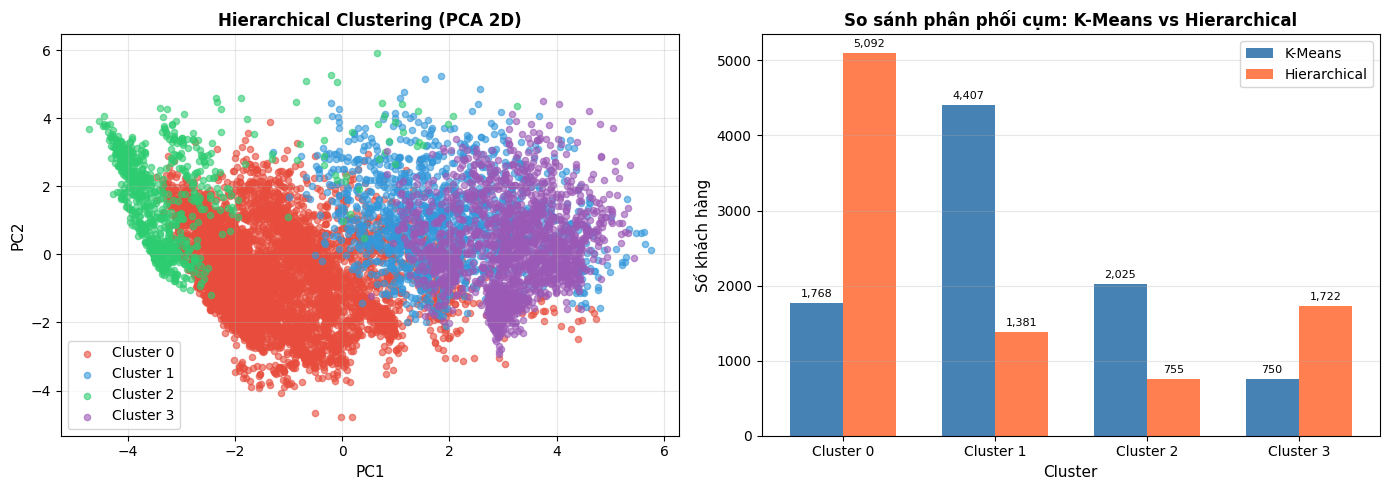

In [48]:
# ============================================================================
# TRỰC QUAN HÓA KẾT QUẢ HIERARCHICAL CLUSTERING
# ============================================================================

# Thêm labels vào dataframe
df_with_hier = df_with_clusters.copy()
df_with_hier['Hier_Cluster'] = hier_labels

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# 1. Scatter plot trên PCA 2D
ax1 = axes[0]
colors_hier = ['#e74c3c', '#3498db', '#2ecc71', '#9b59b6']
for cluster in range(hier_k):
    mask = hier_labels == cluster
    ax1.scatter(X_pca_2d[mask, 0], X_pca_2d[mask, 1], 
                c=colors_hier[cluster], label=f'Cluster {cluster}', 
                alpha=0.6, s=20)

ax1.set_xlabel('PC1', fontsize=11)
ax1.set_ylabel('PC2', fontsize=11)
ax1.set_title('Hierarchical Clustering (PCA 2D)', fontsize=12, fontweight='bold')
ax1.legend()
ax1.grid(True, alpha=0.3)

# 2. So sánh phân phối cụm giữa K-Means và Hierarchical
ax2 = axes[1]
x = np.arange(hier_k)
width = 0.35

kmeans_counts = pd.Series(kmeans_labels).value_counts().sort_index().values
hier_counts = hier_cluster_counts.values

bars1 = ax2.bar(x - width/2, kmeans_counts, width, label='K-Means', color='steelblue')
bars2 = ax2.bar(x + width/2, hier_counts, width, label='Hierarchical', color='coral')

ax2.set_xlabel('Cluster', fontsize=11)
ax2.set_ylabel('Số khách hàng', fontsize=11)
ax2.set_title('So sánh phân phối cụm: K-Means vs Hierarchical', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels([f'Cluster {i}' for i in range(hier_k)])
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

# Thêm số liệu trên cột
for bar in bars1:
    height = bar.get_height()
    ax2.annotate(f'{int(height):,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)
for bar in bars2:
    height = bar.get_height()
    ax2.annotate(f'{int(height):,}', xy=(bar.get_x() + bar.get_width() / 2, height),
                xytext=(0, 3), textcoords="offset points", ha='center', va='bottom', fontsize=8)

plt.tight_layout()
plt.show()

#### **3.2.4 Phân tích đặc trưng các cụm Hierarchical Clustering**

In [49]:
# ============================================================================
# PHÂN TÍCH ĐẶC TRƯNG CÁC CỤM HIERARCHICAL CLUSTERING
# ============================================================================

print("=" * 70)
print("3.2.4 PHÂN TÍCH ĐẶC TRƯNG CÁC CỤM (HIERARCHICAL)")
print("=" * 70)

# Tính thống kê cho từng cụm
hier_cluster_means = df_with_hier.groupby('Hier_Cluster')[key_features].mean()

print("\nGIÁ TRỊ TRUNG BÌNH CỦA CÁC FEATURE CHÍNH THEO CỤM:")
print("-" * 70)
display(hier_cluster_means.round(2))

# Mô tả từng cụm
print("\n" + "=" * 70)
print("MÔ TẢ ĐẶC TRƯNG TỪNG CỤM (HIERARCHICAL)")
print("=" * 70)

for cluster in range(hier_k):
    cluster_data = df_with_hier[df_with_hier['Hier_Cluster'] == cluster]
    n_customers = len(cluster_data)
    pct = n_customers / len(df_with_hier) * 100
    
    avg_balance = cluster_data['BALANCE'].mean()
    avg_purchases = cluster_data['PURCHASES'].mean()
    avg_cash_advance = cluster_data['CASH_ADVANCE'].mean()
    avg_payments = cluster_data['PAYMENTS'].mean()
    avg_credit_limit = cluster_data['CREDIT_LIMIT'].mean()
    avg_prc_full = cluster_data['PRC_FULL_PAYMENT'].mean()
    
    print(f"\n{'='*60}")
    print(f"HIER CLUSTER {cluster}: {n_customers:,} khách hàng ({pct:.1f}%)")
    print(f"{'='*60}")
    print(f"  Số dư TB:           ${avg_balance:>10,.0f}")
    print(f"  Mua sắm TB:         ${avg_purchases:>10,.0f}")
    print(f"  Ứng tiền mặt TB:    ${avg_cash_advance:>10,.0f}")
    print(f"  Thanh toán TB:      ${avg_payments:>10,.0f}")
    print(f"  Hạn mức tín dụng:   ${avg_credit_limit:>10,.0f}")
    print(f"  Tỷ lệ thanh toán đầy đủ: {avg_prc_full*100:>6.1f}%")
    
    # Phân loại tự động
    overall_mean = df_with_hier[['PURCHASES', 'CASH_ADVANCE', 'BALANCE']].mean()
    if avg_purchases > overall_mean['PURCHASES'] and avg_cash_advance < overall_mean['CASH_ADVANCE']:
        profile = "KHÁCH HÀNG MUA SẮM TÍCH CỰC"
    elif avg_cash_advance > overall_mean['CASH_ADVANCE'] and avg_purchases < overall_mean['PURCHASES']:
        profile = "KHÁCH HÀNG ỨNG TIỀN MẶT (RỦI RO)"
    elif avg_balance < overall_mean['BALANCE'] and avg_purchases < overall_mean['PURCHASES']:
        profile = "KHÁCH HÀNG ÍT HOẠT ĐỘNG"
    elif avg_prc_full > 0.3:
        profile = "KHÁCH HÀNG THANH TOÁN TỐT"
    else:
        profile = "KHÁCH HÀNG TRUNG BÌNH"
    
    print(f"\n  --> NHẬN DIỆN: {profile}")

3.2.4 PHÂN TÍCH ĐẶC TRƯNG CÁC CỤM (HIERARCHICAL)

GIÁ TRỊ TRUNG BÌNH CỦA CÁC FEATURE CHÍNH THEO CỤM:
----------------------------------------------------------------------


,PURCHASES,ONEOFF_PURCHASES,INSTALLMENTS_PURCHASES,PURCHASES_FREQUENCY,CASH_ADVANCE,CASH_ADVANCE_FREQUENCY,CREDIT_LIMIT,BALANCE,PAYMENTS,PRC_FULL_PAYMENT,CREDIT_UTILIZATION,CASH_RATIO,PAYMENT_RATIO,PURCHASE_PER_TRX,INSTALLMENT_SHARE,HAS_PURCHASE,HAS_CASH_ADV,FULL_PAYER_FLAG
Hier_Cluster,,,,,,,,,,,,,,,,,,
0,1237.88,733.02,505.18,0.62,179.02,0.04,4473.69,1228.54,1408.58,0.11,0.31,0.04,3.66,97.75,0.50,0.98,0.23,0.0
1,798.63,460.37,338.56,0.47,3213.49,0.37,4568.18,2608.66,2529.44,0.04,0.59,0.73,3.14,73.80,0.37,0.86,1.00,0.0
2,2082.79,1237.09,846.54,0.77,124.32,0.02,5264.87,203.86,2421.99,0.95,0.05,0.04,6.82,81.43,0.60,0.96,0.09,1.0
3,0.00,0.00,0.00,0.00,1926.63,0.27,4158.92,2316.98,1752.27,0.03,0.60,0.47,2.80,0.00,0.00,0.00,1.00,0.0



MÔ TẢ ĐẶC TRƯNG TỪNG CỤM (HIERARCHICAL)

HIER CLUSTER 0: 5,092 khách hàng (56.9%)
  Số dư TB:           $     1,229
  Mua sắm TB:         $     1,238
  Ứng tiền mặt TB:    $       179
  Thanh toán TB:      $     1,409
  Hạn mức tín dụng:   $     4,474
  Tỷ lệ thanh toán đầy đủ:   10.6%

  --> NHẬN DIỆN: KHÁCH HÀNG MUA SẮM TÍCH CỰC

HIER CLUSTER 1: 1,381 khách hàng (15.4%)
  Số dư TB:           $     2,609
  Mua sắm TB:         $       799
  Ứng tiền mặt TB:    $     3,213
  Thanh toán TB:      $     2,529
  Hạn mức tín dụng:   $     4,568
  Tỷ lệ thanh toán đầy đủ:    4.4%

  --> NHẬN DIỆN: KHÁCH HÀNG ỨNG TIỀN MẶT (RỦI RO)

HIER CLUSTER 2: 755 khách hàng (8.4%)
  Số dư TB:           $       204
  Mua sắm TB:         $     2,083
  Ứng tiền mặt TB:    $       124
  Thanh toán TB:      $     2,422
  Hạn mức tín dụng:   $     5,265
  Tỷ lệ thanh toán đầy đủ:   95.3%

  --> NHẬN DIỆN: KHÁCH HÀNG MUA SẮM TÍCH CỰC

HIER CLUSTER 3: 1,722 khách hàng (19.2%)
  Số dư TB:           $     2,317
  

#### **3.2.5 Tổng kết HIERARCHICAL CLUSTERING**

In [50]:
# ============================================================================
# TỔNG KẾT HIERARCHICAL CLUSTERING (Auto-naming giong K-Means de tranh trung ten)
# ============================================================================

print("=" * 70)
print("TỔNG KẾT HIERARCHICAL CLUSTERING")
print("=" * 70)

# AUTO NAMING (quantile-based)
profile_cols = [
    'PURCHASES','PURCHASES_FREQUENCY','CASH_ADVANCE','CASH_ADVANCE_FREQUENCY',
    'PRC_FULL_PAYMENT','CREDIT_UTILIZATION','CASH_RATIO','INSTALLMENT_SHARE','HAS_PURCHASE','HAS_CASH_ADV'
 ]
profile_cols = [c for c in profile_cols if c in df_with_hier.columns]

hier_cluster_names = {}
if profile_cols:
    cluster_profile_small = df_with_hier.groupby('Hier_Cluster')[profile_cols].mean()
    q75 = cluster_profile_small.quantile(0.75)
    q25 = cluster_profile_small.quantile(0.25)
    
    for c in sorted(cluster_profile_small.index):
        row = cluster_profile_small.loc[c]
        cash_heavy = False
        if 'CASH_RATIO' in row.index:
            cash_heavy = row['CASH_RATIO'] >= q75.get('CASH_RATIO', row['CASH_RATIO'])
        elif 'CASH_ADVANCE' in row.index:
            cash_heavy = row['CASH_ADVANCE'] >= q75.get('CASH_ADVANCE', row['CASH_ADVANCE'])
        
        high_spend = row.get('PURCHASES', 0) >= q75.get('PURCHASES', row.get('PURCHASES', 0))
        full_payer = row.get('PRC_FULL_PAYMENT', 0) >= q75.get('PRC_FULL_PAYMENT', row.get('PRC_FULL_PAYMENT', 0))
        low_activity = (row.get('HAS_PURCHASE', 1) <= q25.get('HAS_PURCHASE', row.get('HAS_PURCHASE', 1))) or (row.get('PURCHASES', 0) <= q25.get('PURCHASES', row.get('PURCHASES', 0)))
        installment_oriented = row.get('INSTALLMENT_SHARE', 0) >= q75.get('INSTALLMENT_SHARE', row.get('INSTALLMENT_SHARE', 0))
        high_util = row.get('CREDIT_UTILIZATION', 0) >= q75.get('CREDIT_UTILIZATION', row.get('CREDIT_UTILIZATION', 0))
        
        if cash_heavy:
            hier_cluster_names[c] = "Cash-Advance Heavy (Need control)"
        elif low_activity:
            hier_cluster_names[c] = "Low Activity (Activation)"
        elif high_spend and full_payer:
            hier_cluster_names[c] = "High Spend + Full Payer (VIP/Rewards)"
        elif installment_oriented:
            hier_cluster_names[c] = "Installment Oriented (Merchant/BNPL)"
        elif high_util and not full_payer:
            hier_cluster_names[c] = "High Utilization Revolver (Balance mgmt)"
        else:
            hier_cluster_names[c] = "Regular Users (Maintain)"
else:
    for c in range(hier_k):
        hier_cluster_names[c] = f"Cluster {c}"

print("\nPHÂN LOẠI CUỐI CÙNG (HIERARCHICAL - Auto-naming):")
print("-" * 70)
for cluster in sorted(pd.Series(hier_labels).unique()):
    name = hier_cluster_names.get(cluster, f"Cluster {cluster}")
    count = (hier_labels == cluster).sum()
    pct = count / len(hier_labels) * 100
    print(f"  Cluster {cluster}: {name:<38} - {count:,} KH ({pct:.1f}%)")

print("\nĐÁNH GIÁ CHẤT LƯỢNG (X_full):")
print("-" * 70)
print(f"  Silhouette Score:      {hier_silhouette:.4f}")
print(f"  Calinski-Harabasz:     {hier_calinski:,.2f}")
print(f"  Davies-Bouldin:        {hier_davies:.4f}")

TỔNG KẾT HIERARCHICAL CLUSTERING

PHÂN LOẠI CUỐI CÙNG (HIERARCHICAL - Auto-naming):
----------------------------------------------------------------------
  Cluster 0: Regular Users (Maintain)               - 5,092 KH (56.9%)
  Cluster 1: Cash-Advance Heavy (Need control)      - 1,381 KH (15.4%)
  Cluster 2: High Spend + Full Payer (VIP/Rewards)  - 755 KH (8.4%)
  Cluster 3: Low Activity (Activation)              - 1,722 KH (19.2%)

ĐÁNH GIÁ CHẤT LƯỢNG (X_full):
----------------------------------------------------------------------
  Silhouette Score:      0.2261
  Calinski-Harabasz:     1,742.58
  Davies-Bouldin:        1.6679


### **3.3 So sánh K-Means vs Hierarchical Clustering**

3.2.5 SO SÁNH K-MEANS vs HIERARCHICAL CLUSTERING

BẢNG SO SÁNH CHẤT LƯỢNG PHÂN CỤM:
----------------------------------------------------------------------


,Metric,K-Means,Hierarchical,Tốt hơn
0,Silhouette Score,0.233551,0.226125,K-Means
1,Calinski-Harabasz Index,1955.760504,1742.579585,K-Means
2,Davies-Bouldin Index,1.693097,1.667935,Hierarchical



----------------------------------------------------------------------
ĐỘ TƯƠNG ĐỒNG GIỮA 2 PHƯƠNG PHÁP:
----------------------------------------------------------------------
  Adjusted Rand Index (ARI):         0.7530
  Normalized Mutual Information:     0.7531

  [Giải thích]
  - ARI = 1: Hai phương pháp cho kết quả GIỐNG NHAU hoàn toàn
  - ARI = 0: Hai phương pháp cho kết quả NGẪU NHIÊN
  - ARI = 0.7530: Hai phương pháp có sự TƯƠNG ĐỒNG CAO

----------------------------------------------------------------------
MA TRẬN SO SÁNH PHÂN CỤM (K-Means vs Hierarchical):
----------------------------------------------------------------------


Hierarchical,0,1,2,3
K-Means,,,,
0,587,1180,1,0
1,4402,4,0,1
2,103,197,4,1721
3,0,0,750,0


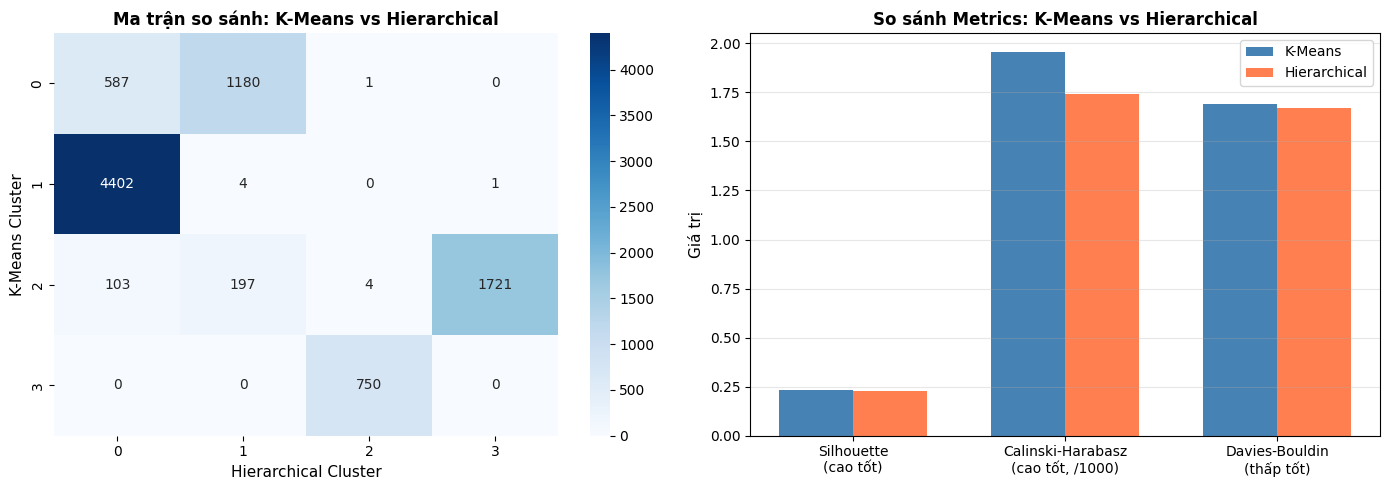


KẾT LUẬN

  ✓ Phương pháp tốt hơn cho bài toán này: K-MEANS
    Lý do: có metrics tổng thể tốt hơn

  ✓ Độ tương đồng giữa 2 phương pháp: 75.3%
    → Có thể sử dụng kết quả của cả 2 để cross-validate


In [51]:
# ============================================================================
# SO SÁNH K-MEANS VS HIERARCHICAL CLUSTERING
# ============================================================================

print("=" * 70)
print("3.2.5 SO SÁNH K-MEANS vs HIERARCHICAL CLUSTERING")
print("=" * 70)

# Bảng so sánh metrics
comparison_data = {
    'Metric': ['Silhouette Score', 'Calinski-Harabasz Index', 'Davies-Bouldin Index'],
    'K-Means': [final_silhouette, final_calinski, final_davies],
    'Hierarchical': [hier_silhouette, hier_calinski, hier_davies],
    'Tốt hơn': ['', '', '']
}

# Xác định phương pháp tốt hơn cho từng metric
comparison_data['Tốt hơn'][0] = 'K-Means' if final_silhouette > hier_silhouette else 'Hierarchical'
comparison_data['Tốt hơn'][1] = 'K-Means' if final_calinski > hier_calinski else 'Hierarchical'
comparison_data['Tốt hơn'][2] = 'K-Means' if final_davies < hier_davies else 'Hierarchical'

comparison_df = pd.DataFrame(comparison_data)
print("\nBẢNG SO SÁNH CHẤT LƯỢNG PHÂN CỤM:")
print("-" * 70)
display(comparison_df)

# Adjusted Rand Index - đo độ tương đồng giữa 2 phương pháp phân cụm
from sklearn.metrics import adjusted_rand_score, normalized_mutual_info_score

ari = adjusted_rand_score(kmeans_labels, hier_labels)
nmi = normalized_mutual_info_score(kmeans_labels, hier_labels)

print("\n" + "-" * 70)
print("ĐỘ TƯƠNG ĐỒNG GIỮA 2 PHƯƠNG PHÁP:")
print("-" * 70)
print(f"  Adjusted Rand Index (ARI):         {ari:.4f}")
print(f"  Normalized Mutual Information:     {nmi:.4f}")
print("\n  [Giải thích]")
print("  - ARI = 1: Hai phương pháp cho kết quả GIỐNG NHAU hoàn toàn")
print("  - ARI = 0: Hai phương pháp cho kết quả NGẪU NHIÊN")
print(f"  - ARI = {ari:.4f}: Hai phương pháp có sự {'TƯƠNG ĐỒNG CAO' if ari > 0.6 else 'KHÁC BIỆT ĐÁNG KỂ'}")

# Confusion matrix giữa 2 phương pháp
print("\n" + "-" * 70)
print("MA TRẬN SO SÁNH PHÂN CỤM (K-Means vs Hierarchical):")
print("-" * 70)
cross_tab = pd.crosstab(kmeans_labels, hier_labels, 
                        rownames=['K-Means'], colnames=['Hierarchical'])
display(cross_tab)

# Trực quan hóa
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Heatmap của confusion matrix
ax1 = axes[0]
import seaborn as sns
sns.heatmap(cross_tab, annot=True, fmt='d', cmap='Blues', ax=ax1)
ax1.set_title('Ma trận so sánh: K-Means vs Hierarchical', fontsize=12, fontweight='bold')
ax1.set_xlabel('Hierarchical Cluster', fontsize=11)
ax1.set_ylabel('K-Means Cluster', fontsize=11)

# So sánh metrics
ax2 = axes[1]
metrics_names = ['Silhouette\n(cao tốt)', 'Calinski-Harabasz\n(cao tốt, /1000)', 'Davies-Bouldin\n(thấp tốt)']
kmeans_vals = [final_silhouette, final_calinski/1000, final_davies]
hier_vals = [hier_silhouette, hier_calinski/1000, hier_davies]

x = np.arange(len(metrics_names))
width = 0.35

bars1 = ax2.bar(x - width/2, kmeans_vals, width, label='K-Means', color='steelblue')
bars2 = ax2.bar(x + width/2, hier_vals, width, label='Hierarchical', color='coral')

ax2.set_ylabel('Giá trị', fontsize=11)
ax2.set_title('So sánh Metrics: K-Means vs Hierarchical', fontsize=12, fontweight='bold')
ax2.set_xticks(x)
ax2.set_xticklabels(metrics_names)
ax2.legend()
ax2.grid(True, alpha=0.3, axis='y')

plt.tight_layout()
plt.show()

# Kết luận
print("\n" + "=" * 70)
print("KẾT LUẬN")
print("=" * 70)

kmeans_wins = sum([
    final_silhouette > hier_silhouette,
    final_calinski > hier_calinski,
    final_davies < hier_davies
])

if kmeans_wins >= 2:
    winner = "K-MEANS"
    reason = "có metrics tổng thể tốt hơn"
else:
    winner = "HIERARCHICAL"
    reason = "có metrics tổng thể tốt hơn"

print(f"\n  ✓ Phương pháp tốt hơn cho bài toán này: {winner}")
print(f"    Lý do: {reason}")
print(f"\n  ✓ Độ tương đồng giữa 2 phương pháp: {ari*100:.1f}%")
print(f"    {'→ Có thể sử dụng kết quả của cả 2 để cross-validate' if ari > 0.5 else '→ Cần xem xét kỹ sự khác biệt'}")

### **3.4 Scatter Plot các Features theo Cluster**

Trực quan hóa phân bố các features quan trọng theo từng cluster để đánh giá chất lượng phân cụm.

3.4.1 PAIRPLOT - PHÂN BỐ CÁC FEATURE THEO CLUSTER

[INFO] Đang vẽ pairplot cho 8 features...


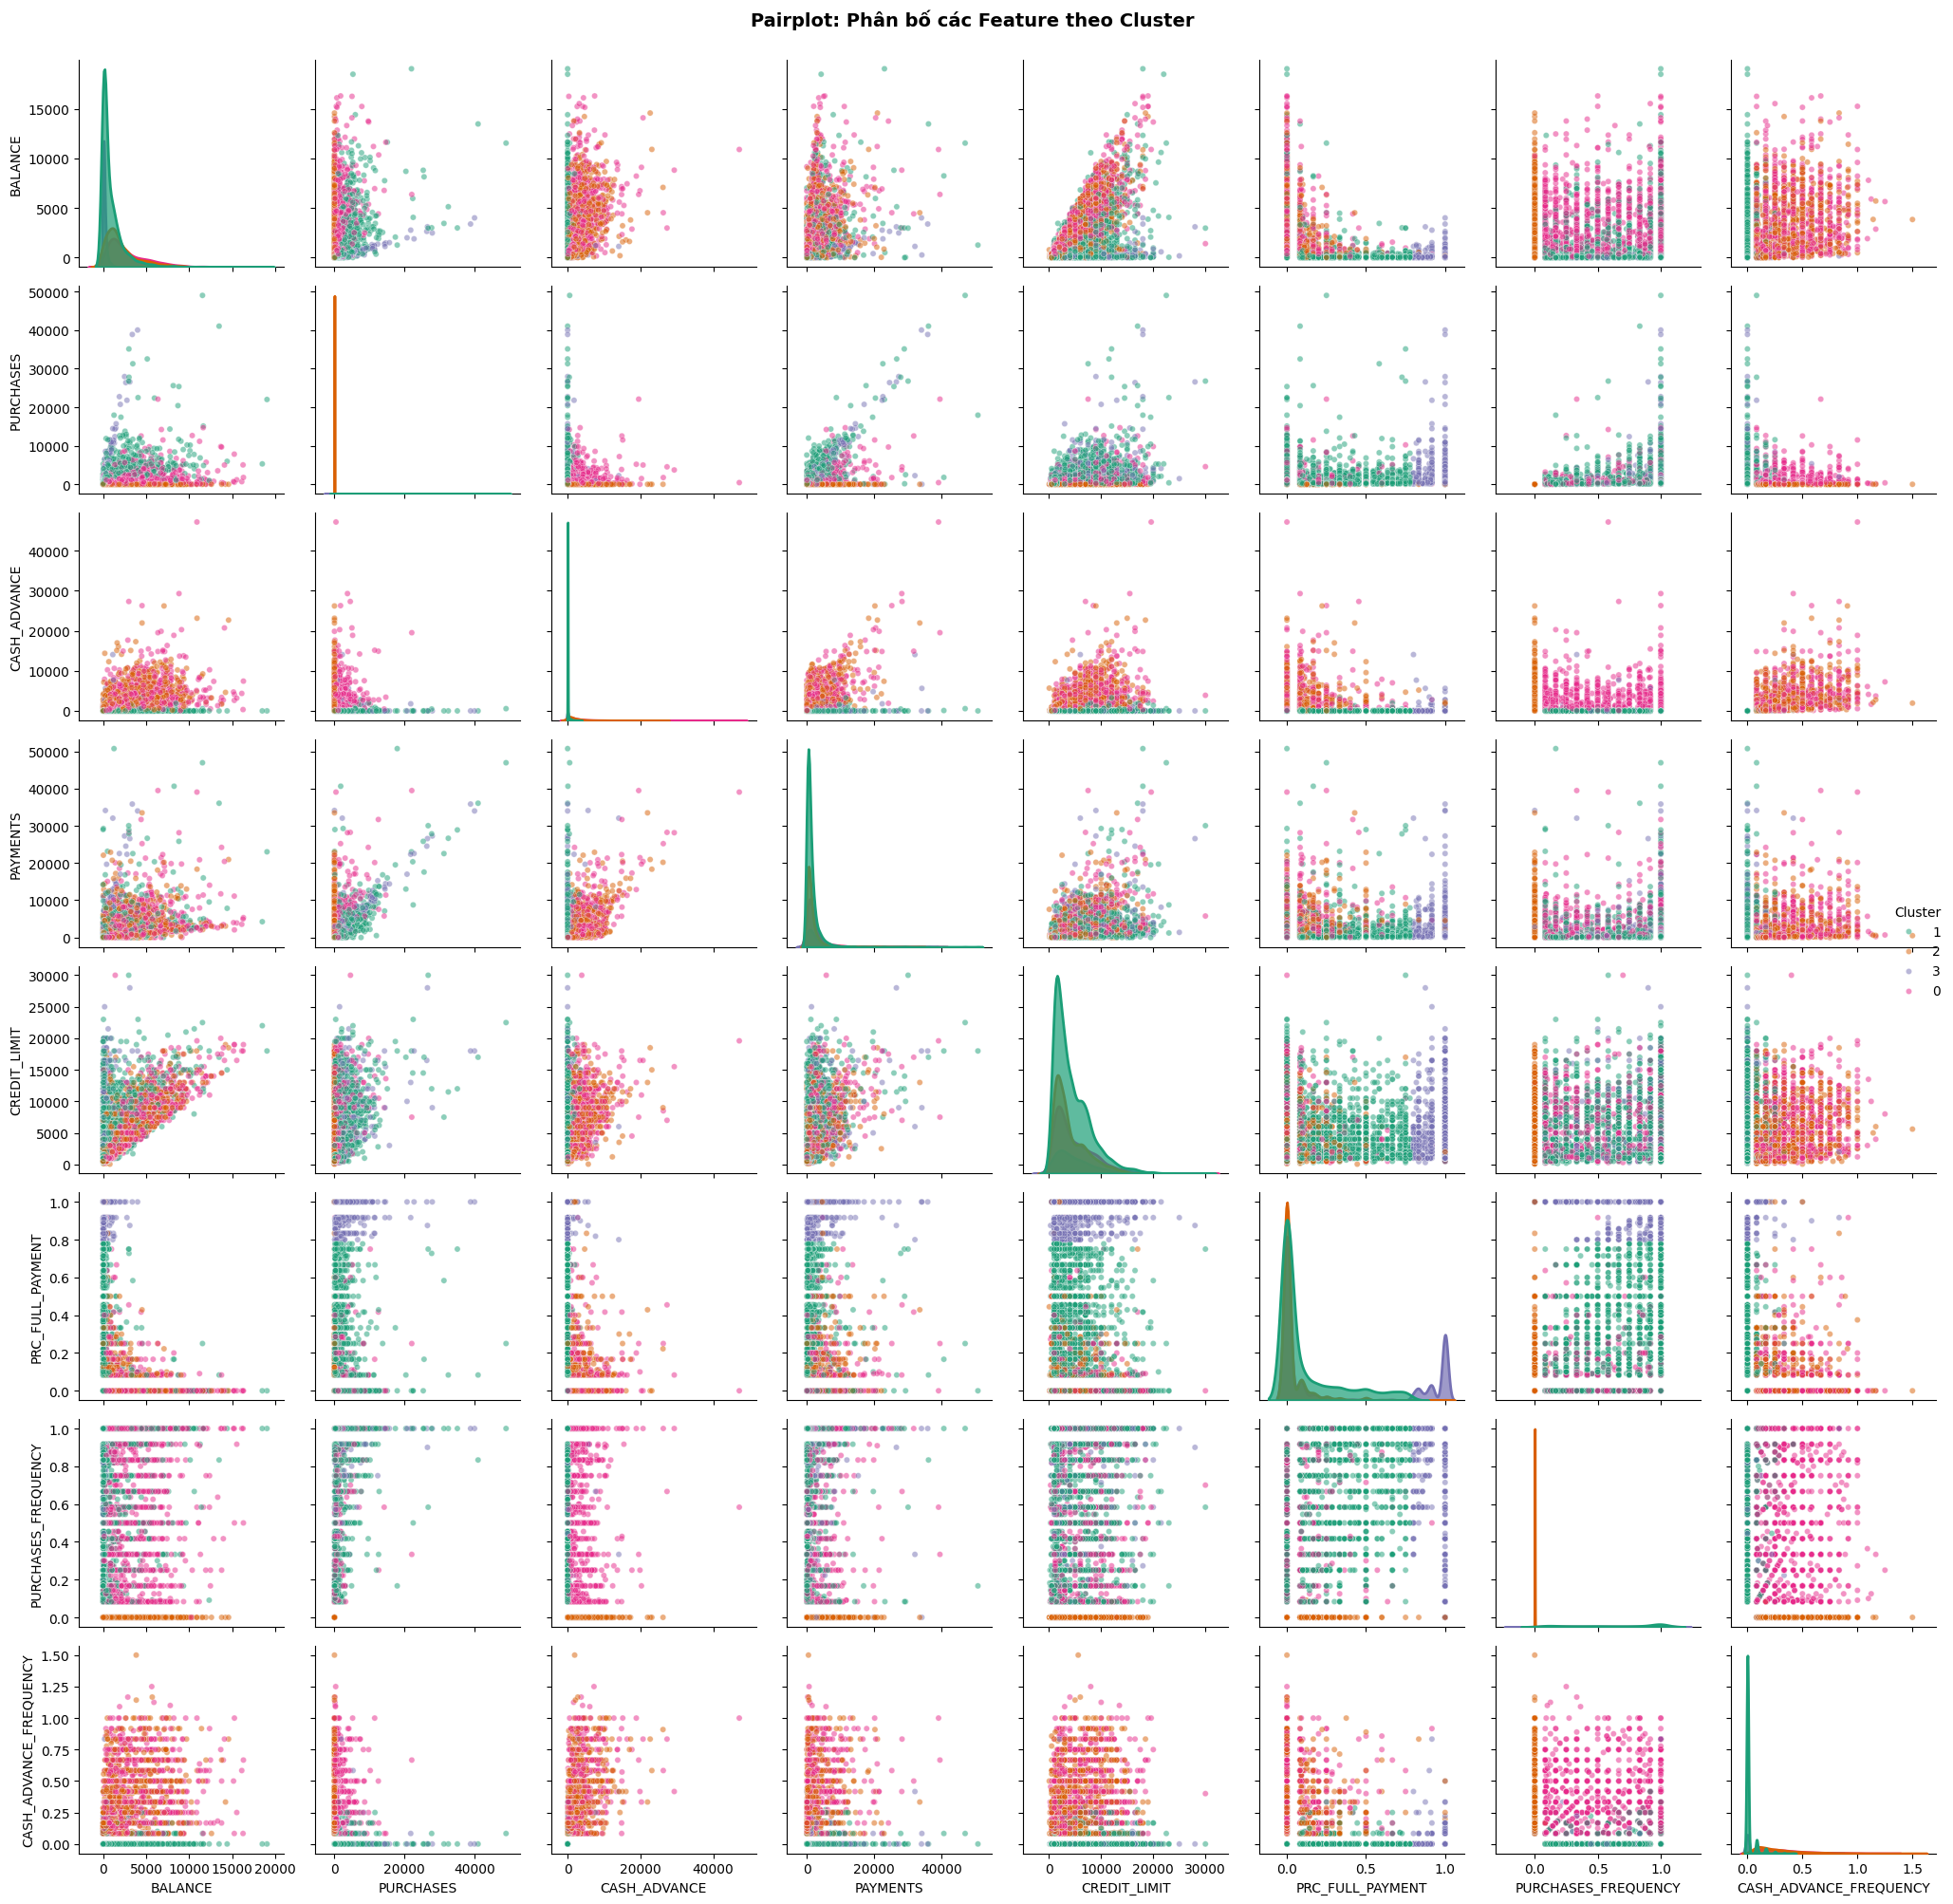

In [52]:
# ============================================================================
# PAIRPLOT - SCATTER PLOT TỪNG CẶP FEATURE THEO CLUSTER
# ============================================================================

print("=" * 70)
print("3.4.1 PAIRPLOT - PHÂN BỐ CÁC FEATURE THEO CLUSTER")
print("=" * 70)

# Chọn các features quan trọng để vẽ pairplot (không quá nhiều để tránh quá tải)
selected_features = ['BALANCE', 'PURCHASES', 'CASH_ADVANCE', 'PAYMENTS', 
                     'CREDIT_LIMIT', 'PRC_FULL_PAYMENT', 'PURCHASES_FREQUENCY', 
                     'CASH_ADVANCE_FREQUENCY', 'Cluster']

# Lọc các features có trong dataframe
selected_features = [f for f in selected_features if f in df_with_clusters.columns]

# Tạo subset với các features đã chọn
df_pairplot = df_with_clusters[selected_features].copy()

# Chuyển Cluster thành categorical để dễ phân biệt màu
df_pairplot['Cluster'] = df_pairplot['Cluster'].astype(str)

print(f"\n[INFO] Đang vẽ pairplot cho {len(selected_features)-1} features...")

# Vẽ pairplot
pairplot_fig = sns.pairplot(df_pairplot, hue='Cluster', palette='Dark2', 
                            diag_kind='kde', corner=False,
                            plot_kws={'alpha': 0.5, 's': 20},
                            diag_kws={'alpha': 0.7, 'linewidth': 2})

# Tùy chỉnh tiêu đề
pairplot_fig.fig.suptitle('Pairplot: Phân bố các Feature theo Cluster', 
                          fontsize=14, fontweight='bold', y=1.001)

plt.tight_layout()
plt.show()

#### **3.6 STAGE-2 SEGMENTATION - REGULAR USERS (SCORECARD)**
- Tách Regular -> tính Value/Risk/Engagement score (z-score trong subset)

- Chia theo quantile -> 4 sub-persona (High/Low Value x High/Low Risk)

In [54]:
import numpy as np
import pandas as pd

print("=" * 70)
print("3.6 STAGE-2 SEGMENTATION - REGULAR USERS (SCORECARD)")
print("=" * 70)

if 'df_with_clusters' not in globals() or not isinstance(globals().get('df_with_clusters'), pd.DataFrame):
    raise RuntimeError("Chưa có df_with_clusters. Hãy chạy K-Means đến phần profiling trước.")

regular_cluster_ids = []
try:
    regular_cluster_ids = [cid for cid, nm in (cluster_names or {}).items() if isinstance(nm, str) and "Regular Users" in nm]
except Exception:
    regular_cluster_ids = []

if not regular_cluster_ids:
    if 'kmeans_labels' in globals():
        regular_cluster_ids = [pd.Series(kmeans_labels).value_counts().idxmax()]
    else:
        regular_cluster_ids = [df_with_clusters['Cluster'].value_counts().idxmax()]

regular_df = df_with_clusters[df_with_clusters['Cluster'].isin(regular_cluster_ids)].copy()

value_feats = [c for c in ['PURCHASES', 'PURCHASES_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASE_PER_TRX'] if c in regular_df.columns]
risk_feats_pos = [c for c in ['CREDIT_UTILIZATION', 'CASH_RATIO', 'CASH_ADVANCE_FREQUENCY', 'BALANCE'] if c in regular_df.columns]
risk_feats_neg = [c for c in ['PRC_FULL_PAYMENT', 'PAYMENT_RATIO'] if c in regular_df.columns]
engage_feats = [c for c in ['PURCHASES_FREQUENCY', 'TENURE', 'HAS_PURCHASE'] if c in regular_df.columns]

print(f"[INFO] Regular cluster id(s): {regular_cluster_ids}")
print(f"[INFO] Regular subset size: {len(regular_df):,} / {len(df_with_clusters):,} ({len(regular_df)/len(df_with_clusters)*100:.1f}%)")
print("[INFO] Features used:")
print(f"  Value:  {value_feats}")
print(f"  Risk+:  {risk_feats_pos}")
print(f"  Risk-:  {risk_feats_neg}")
print(f"  Engage: {engage_feats}")

3.6 STAGE-2 SEGMENTATION - REGULAR USERS (SCORECARD)
[INFO] Regular cluster id(s): [1]
[INFO] Regular subset size: 4,407 / 8,950 (49.2%)
[INFO] Features used:
  Value:  ['PURCHASES', 'PURCHASES_FREQUENCY', 'CREDIT_LIMIT', 'PAYMENTS', 'PURCHASE_PER_TRX']
  Risk+:  ['CREDIT_UTILIZATION', 'CASH_RATIO', 'CASH_ADVANCE_FREQUENCY', 'BALANCE']
  Risk-:  ['PRC_FULL_PAYMENT', 'PAYMENT_RATIO']
  Engage: ['PURCHASES_FREQUENCY', 'TENURE', 'HAS_PURCHASE']


In [55]:
def _zscore(df_in, cols):
    out = pd.DataFrame(index=df_in.index)
    for col in cols:
        x = df_in[col].astype(float)
        mu = x.mean()
        sd = x.std(ddof=0) + 1e-9
        out[col] = (x - mu) / sd
    return out

z_value = _zscore(regular_df, value_feats) if value_feats else pd.DataFrame(index=regular_df.index)
z_risk_pos = _zscore(regular_df, risk_feats_pos) if risk_feats_pos else pd.DataFrame(index=regular_df.index)
z_risk_neg = _zscore(regular_df, risk_feats_neg) if risk_feats_neg else pd.DataFrame(index=regular_df.index)
z_engage = _zscore(regular_df, engage_feats) if engage_feats else pd.DataFrame(index=regular_df.index)

regular_df['ValueScore'] = z_value.mean(axis=1) if len(z_value.columns) else 0.0
regular_df['RiskScore'] = (z_risk_pos.mean(axis=1) if len(z_risk_pos.columns) else 0.0) - (z_risk_neg.mean(axis=1) if len(z_risk_neg.columns) else 0.0)
regular_df['EngagementScore'] = z_engage.mean(axis=1) if len(z_engage.columns) else 0.0

def _hi_lo(series, label_hi='High', label_lo='Low'):
    s = series.astype(float)
    try:
        return pd.qcut(s.rank(method='first'), q=2, labels=[label_lo, label_hi]).astype(str)
    except Exception:
        thr = s.median()
        return pd.Series(np.where(s >= thr, label_hi, label_lo), index=s.index)

regular_df['ValueTier'] = _hi_lo(regular_df['ValueScore'])
regular_df['RiskTier'] = _hi_lo(regular_df['RiskScore'])
regular_df['EngageTier'] = _hi_lo(regular_df['EngagementScore'])

regular_df['Regular_Subsegment'] = (
    regular_df['ValueTier'].map({'High': 'HighValue', 'Low': 'LowValue'}).astype(str)
    + "_"
    + regular_df['RiskTier'].map({'High': 'HighRisk', 'Low': 'LowRisk'}).astype(str)
 )

campaign_map = {
    'HighValue_LowRisk':  'Upsell/Rewards: tăng chi tiêu, ưu đãi đối tác, tăng hạn mức có kiểm soát',
    'HighValue_HighRisk': 'Balance mgmt: nhắc trả nợ, hạn mức/chi tiêu an toàn, chuyển đổi trả góp',
    'LowValue_LowRisk':   'Activation nhẹ: deal nhỏ, khuyến khích dùng định kỳ, cross-sell',
    'LowValue_HighRisk':  'Risk control: hạn chế cash, nhắc trả nợ, education về phí/lãi',
}

In [56]:
print("\n[INFO] Subsegment distribution (within Regular):")
sub_counts = regular_df['Regular_Subsegment'].value_counts(dropna=False)
for seg, cnt in sub_counts.items():
    pct = cnt / len(regular_df) * 100
    print(f"  {seg:<18} : {cnt:>5,} KH ({pct:>5.1f}%)")

print("\n[INFO] Mean scores by subsegment:")
display(
    regular_df.groupby('Regular_Subsegment')[['ValueScore', 'RiskScore', 'EngagementScore']]
    .mean()
    .sort_index()
    .round(3)
 )

profile_cols = [
    c for c in [
        'PURCHASES','PURCHASES_FREQUENCY','CASH_ADVANCE','CREDIT_UTILIZATION','CASH_RATIO',
        'PRC_FULL_PAYMENT','PAYMENT_RATIO','INSTALLMENT_SHARE'
    ] if c in regular_df.columns
 ]
if profile_cols:
    print("\n[INFO] Business profile (mean):")
    display(regular_df.groupby('Regular_Subsegment')[profile_cols].mean().sort_index().round(2))

print("\n[INFO] Campaign gợi ý theo subsegment:")
for seg in sorted(sub_counts.index):
    print(f"  - {seg}: {campaign_map.get(seg, 'Maintain')}")


[INFO] Subsegment distribution (within Regular):
  LowValue_HighRisk  : 1,208 KH ( 27.4%)
  HighValue_LowRisk  : 1,208 KH ( 27.4%)
  LowValue_LowRisk   :   996 KH ( 22.6%)
  HighValue_HighRisk :   995 KH ( 22.6%)

[INFO] Mean scores by subsegment:


,ValueScore,RiskScore,EngagementScore
Regular_Subsegment,,,
HighValue_HighRisk,0.414,1.085,0.191
HighValue_LowRisk,0.371,-1.134,0.208
LowValue_HighRisk,-0.421,0.829,-0.231
LowValue_LowRisk,-0.354,-0.715,-0.163



[INFO] Business profile (mean):


,PURCHASES,PURCHASES_FREQUENCY,CASH_ADVANCE,CREDIT_UTILIZATION,CASH_RATIO,PRC_FULL_PAYMENT,PAYMENT_RATIO,INSTALLMENT_SHARE
Regular_Subsegment,,,,,,,,
HighValue_HighRisk,2389.25,0.80,173.54,0.44,0.03,0.01,2.51,0.45
HighValue_LowRisk,2030.78,0.80,13.31,0.09,0.00,0.25,7.54,0.50
LowValue_HighRisk,356.65,0.45,40.69,0.45,0.02,0.00,1.31,0.51
LowValue_LowRisk,334.34,0.53,3.27,0.04,0.00,0.21,4.40,0.68



[INFO] Campaign gợi ý theo subsegment:
  - HighValue_HighRisk: Balance mgmt: nhắc trả nợ, hạn mức/chi tiêu an toàn, chuyển đổi trả góp
  - HighValue_LowRisk: Upsell/Rewards: tăng chi tiêu, ưu đãi đối tác, tăng hạn mức có kiểm soát
  - LowValue_HighRisk: Risk control: hạn chế cash, nhắc trả nợ, education về phí/lãi
  - LowValue_LowRisk: Activation nhẹ: deal nhỏ, khuyến khích dùng định kỳ, cross-sell


[INFO] PCA2 explained variance: 37.18% (PC1=21.37%, PC2=15.81%)


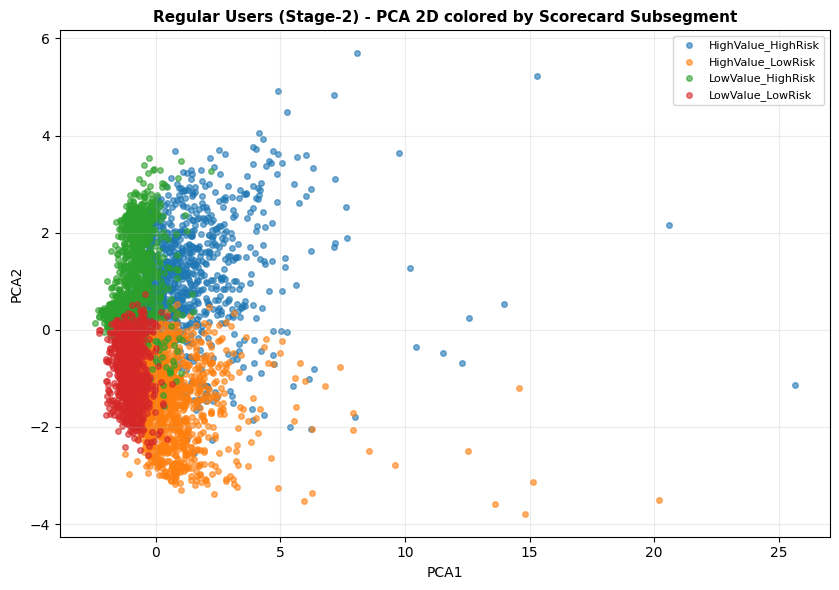


[INFO] PCA loadings:


,PCA1_loading,PCA2_loading
PAYMENTS,0.507,-0.098
PURCHASES,0.506,-0.043
BALANCE,0.399,0.409
CREDIT_LIMIT,0.398,-0.077
PAYMENT_RATIO,0.197,-0.505
PURCHASES_FREQUENCY,0.183,-0.117
PURCHASE_PER_TRX,0.172,-0.011
CASH_ADVANCE_FREQUENCY,0.158,-0.015
CASH_RATIO,0.130,-0.000
TENURE,0.115,0.033


In [57]:
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA

feat_candidates = []
for lst in [value_feats, risk_feats_pos, risk_feats_neg, engage_feats]:
    feat_candidates += list(lst)
stage2_feats = [c for c in dict.fromkeys(feat_candidates) if c in regular_df.columns]
if len(stage2_feats) < 3:
    stage2_feats = [
        c for c in ['PURCHASES', 'PURCHASES_FREQUENCY', 'CREDIT_UTILIZATION', 'CASH_RATIO', 'PRC_FULL_PAYMENT', 'PAYMENT_RATIO']
        if c in regular_df.columns
    ]

if len(stage2_feats) < 3:
    raise ValueError("Không đủ feature để PCA trong regular_df (cần >= 3 cột).")

X_reg = regular_df[stage2_feats].replace([np.inf, -np.inf], np.nan).fillna(0.0)
scaler_reg = StandardScaler()
X_reg_scaled = scaler_reg.fit_transform(X_reg)

pca_reg_2d = PCA(n_components=2, random_state=42)
X_reg_pca2 = pca_reg_2d.fit_transform(X_reg_scaled)

regular_df['PCA1'] = X_reg_pca2[:, 0]
regular_df['PCA2'] = X_reg_pca2[:, 1]

ev = pca_reg_2d.explained_variance_ratio_
print(f"[INFO] PCA2 explained variance: {(ev.sum()*100):.2f}% (PC1={ev[0]*100:.2f}%, PC2={ev[1]*100:.2f}%)")

fig, ax = plt.subplots(1, 1, figsize=(8.5, 6))
for seg, g in regular_df.groupby('Regular_Subsegment'):
    ax.scatter(g['PCA1'], g['PCA2'], s=16, alpha=0.60, label=seg)
ax.set_title('Regular Users (Stage-2) - PCA 2D colored by Scorecard Subsegment', fontsize=11, fontweight='bold')
ax.set_xlabel('PCA1')
ax.set_ylabel('PCA2')
ax.grid(True, alpha=0.25)
ax.legend(fontsize=8, loc='best')
plt.tight_layout()
plt.show()

loadings = pd.DataFrame(
    pca_reg_2d.components_.T,
    index=stage2_feats,
    columns=['PCA1_loading', 'PCA2_loading']
 )
loadings = loadings.assign(abs_PCA1=loadings['PCA1_loading'].abs()).sort_values('abs_PCA1', ascending=False).drop(columns=['abs_PCA1'])

print("\n[INFO] PCA loadings:")
display(loadings.round(3))

## **4. Business Insights & Recommendations**

### **4.1 Chiến lược marketing cho từng cluster**

Dựa trên kết quả phân cụm K-Means, đề xuất chiến lược marketing cụ thể cho từng nhóm khách hàng:

---

#### **Cluster 0: Cash Advance Users (Rủi ro)**

**Đặc điểm nhận dạng:**
- Tần suất ứng tiền mặt cao (CASH_ADVANCE_FREQUENCY cao)
- Giá trị ứng tiền mặt lớn (CASH_ADVANCE cao)
- Mua sắm thấp (PURCHASES thấp)
- Tỷ lệ thanh toán đầy đủ thấp (PRC_FULL_PAYMENT thấp)

**Tại sao được phân vào cụm này:**
Nhóm khách hàng này chủ yếu sử dụng thẻ để rút tiền mặt thay vì mua sắm. Đây là hành vi tiềm ẩn rủi ro vì ứng tiền mặt thường có lãi suất cao hơn và cho thấy khách hàng có thể đang gặp khó khăn tài chính.

**Chiến lược Marketing:**
- Giảm hạn mức ứng tiền mặt
- Tăng phí ứng tiền để hạn chế hành vi
- Khuyến khích chuyển sang mua sắm qua ưu đãi cashback khi mua hàng
- Giám sát chặt chẽ, cảnh báo sớm về rủi ro

---

#### **Cluster 1: Active Shoppers (VIP)**

**Đặc điểm nhận dạng:**
- Giá trị mua sắm cao (PURCHASES cao)
- Tần suất mua sắm cao (PURCHASES_FREQUENCY cao)
- Thanh toán tốt (PAYMENTS cao)
- Ít hoặc không ứng tiền mặt (CASH_ADVANCE thấp)
- Hạn mức tín dụng cao (CREDIT_LIMIT cao)

**Tại sao được phân vào cụm này:**
Đây là nhóm khách hàng giá trị nhất - sử dụng thẻ thường xuyên cho mua sắm, thanh toán đúng hạn, và không có hành vi rủi ro. Họ mang lại doanh thu ổn định từ phí giao dịch.

**Chiến lược Marketing:**
- Tăng hạn mức tín dụng 20-50%
- Chương trình Cashback 2-5%
- Ưu tiên hỗ trợ khách hàng 24/7
- Mời tham gia chương trình VIP exclusive
- Cross-sell sản phẩm cao cấp (thẻ Platinum, bảo hiểm premium)

---

#### **Cluster 2: Low Activity (Cần kích hoạt)**

**Đặc điểm nhận dạng:**
- Số dư thấp (BALANCE thấp)
- Mua sắm ít (PURCHASES thấp)
- Tần suất giao dịch thấp (PURCHASES_FREQUENCY thấp)
- Không ứng tiền mặt (CASH_ADVANCE = 0)
- Thanh toán thấp (PAYMENTS thấp)

**Tại sao được phân vào cụm này:**
Nhóm này có thẻ nhưng ít sử dụng - có thể là khách hàng mới chưa quen, hoặc đã chuyển sang sử dụng thẻ của ngân hàng khác. Họ là tiềm năng chưa được khai thác.

**Chiến lược Marketing:**
- Chiến dịch re-engagement qua email/SMS
- Ưu đãi "Welcome back" - giảm 20% giao dịch đầu tiên
- Nhắc nhở về benefits của thẻ
- Tặng điểm thưởng cho giao dịch đầu tiên trong tháng
- Xem xét đóng tài khoản nếu không phản hồi sau 6 tháng

---

#### **Cluster 3: Installment Buyers (Trung thành)**

**Đặc điểm nhận dạng:**
- Mua sắm trung bình đến cao (PURCHASES trung bình)
- Sử dụng tính năng trả góp (INSTALLMENTS_PURCHASES cao)
- Tỷ lệ thanh toán đầy đủ trung bình (PRC_FULL_PAYMENT trung bình)
- Số dư duy trì ổn định (BALANCE ổn định)
- Thời gian sử dụng thẻ lâu (TENURE cao)

**Tại sao được phân vào cụm này:**
Nhóm khách hàng này thích mua sắm trả góp, thanh toán đều đặn theo kỳ hạn. Họ mang lại doanh thu từ lãi suất trả góp và là nhóm khách hàng ổn định, trung thành.

**Chiến lược Marketing:**
- Đẩy mạnh chương trình trả góp 0% lãi suất với các merchant đối tác
- Hợp tác với các cửa hàng điện máy, nội thất để có ưu đãi trả góp
- Cross-sell sản phẩm bảo hiểm, vay tiêu dùng
- Chương trình tích điểm đổi quà

---

**Bảng tổng hợp:**

| Cluster | Tên nhóm | Đặc điểm chính | Chiến lược |
|---------|----------|----------------|------------|
| **0** | Cash Advance Users | Ứng tiền mặt cao, mua sắm thấp | Giám sát, giảm hạn mức ứng tiền |
| **1** | Active Shoppers | Mua sắm cao, thanh toán tốt | Tăng hạn mức, ưu đãi VIP |
| **2** | Low Activity | Ít giao dịch, số dư thấp | Kích hoạt, welcome back |
| **3** | Installment Buyers | Mua trả góp, thanh toán đều | Chương trình trả góp 0% |

### **4.2 KPIs theo dõi (Retention, CLV, ...)**

### **4.3 Chiến lược chuyển đổi**

## **5. Kết luận**